## Cell 1: Install dependencies

In [33]:
# ==========================================
# Cell 1: Install dependency packages
# ==========================================

%pip -q install -U metapub pdfplumber pandas lxml requests beautifulsoup4 tqdm
%pip -q install -U graphviz scikit-learn

print("✅ Dependencies installed successfully")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ 依赖安装完成


## Cell 2: Directory setup

In [1]:
# ==========================================
# Cell 2: Directory setup
# ==========================================

import os
import json
import re
from pathlib import Path

# Project root directory
CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_DIR = CORPUS_DIR / "out2"
VIZ_DIR = OUT_DIR / "viz2"

# Create directories
PAPERS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("📁 CORPUS_DIR:", CORPUS_DIR.resolve())
print("📁 PAPERS_DIR:", PAPERS_DIR.resolve())
print("📁 OUT_DIR:", OUT_DIR.resolve())
print("📁 VIZ_DIR:", VIZ_DIR.resolve())

📁 CORPUS_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus
📁 PAPERS_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\papers
📁 OUT_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out2
📁 VIZ_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out2\viz2


In [2]:
# ==========================================
# New cell: fetch high-quality papers
# ==========================================

from metapub import PubMedFetcher, FindIt
import requests
import pdfplumber
from tqdm.auto import tqdm
import time
from pathlib import Path
import json
import re

fetcher = PubMedFetcher()

# ==========================================
# Configuration
# ==========================================

# 1️⃣ Top journals list (only fetch from these journals)
TOP_JOURNALS = [
    # Top general medicine journals
    "New England Journal of Medicine",
    "The Lancet", 
    "JAMA",
    "BMJ",
    "Annals of Internal Medicine",
    
    # Top critical care journals
    "Intensive Care Medicine",
    "Critical Care Medicine",
    "American Journal of Respiratory and Critical Care Medicine",
    "CHEST",
    "Critical Care",
    
    # Top infectious disease journals
    "Clinical Infectious Diseases",
    "The Lancet Infectious Diseases",
    "Emerging Infectious Diseases",
    
    # Other relevant journals
    "JAMA Internal Medicine",
    "Circulation",
    "European Respiratory Journal",
]

# Build the journal filter
JOURNAL_FILTER = " OR ".join([f'"{j}"[Journal]' for j in TOP_JOURNALS])


# 2️⃣ Publication type filtering (key improvement!)
PUBLICATION_TYPES = {
    "include": [
        "Review",                      # Review article (best fit)
        "Systematic Review",           # Systematic review (best fit)
        "Meta-Analysis",               # Meta-analysis (best fit)
        "Practice Guideline",          # Clinical guideline (best fit)
        "Guideline",                   # Guideline
        "Randomized Controlled Trial", # RCT (good fit)
        "Clinical Trial",              # Clinical trial
    ],
    "exclude": [
        "Case Reports",                # ❌ Case report
        "Letter",                      # ❌ Letter / commentary
        "Comment",                     # ❌ Short comment
        "Editorial",                   # ❌ Editorial
        "News",                        # ❌ News
    ]
}

# Build the publication type filter
PUB_TYPE_INCLUDE = " OR ".join([f'"{t}"[Publication Type]' for t in PUBLICATION_TYPES["include"]])
PUB_TYPE_EXCLUDE = " NOT ".join([f'"{t}"[Publication Type]' for t in PUBLICATION_TYPES["exclude"]])


# ==========================================
# Core function
# ==========================================

def build_query_high_quality(theme: str, year_from: int = 2019, year_to: int = 2024) -> str:
    """
    Build a high-quality search query
    
    What is improved:
    1. ✅ Keep only reviews / guidelines / RCTs
    2. ✅ Exclude case reports / letters
    3. ✅ Restrict to top journals
    4. ✅ Use MeSH terms
    5. ✅ Exclude pediatric / animal studies
    """
    
    # Basic sepsis search (using MeSH terms)
    base_sepsis = '("Sepsis"[Mesh] OR "Shock, Septic"[Mesh] OR "sepsis" OR "septic shock")'
    
    # Exclusion rules
    exclude_animal = 'NOT ("Animals"[Mesh] NOT "Humans"[Mesh])'
    exclude_pediatric = 'NOT ("Child"[Mesh] OR "Infant"[Mesh])'
    
    # ✅ Publication type filter (important!)
    pub_type_filter = f"({PUB_TYPE_INCLUDE})"
    if PUB_TYPE_EXCLUDE:
        pub_type_filter += f" NOT ({PUB_TYPE_EXCLUDE})"
    
    # Time range
    date_filter = f'("{year_from}/01/01"[Date - Publication] : "{year_to}/12/31"[Date - Publication])'
    
    # Topic-specific search terms
    if theme == "symptoms_diagnosis":
        theme_terms = '("Diagnosis"[Mesh] OR "Early Diagnosis"[Mesh] OR "diagnostic criteria" OR "clinical criteria" OR "qSOFA" OR "SOFA score" OR "Sequential Organ Failure Assessment" OR "lactate" OR "biomarker" OR "procalcitonin" OR "early detection" OR "sepsis-3" OR "definition" OR "identification")'
        
    elif theme == "treatment_recommendation":
        theme_terms = '("Therapeutics"[Mesh] OR "Drug Therapy"[Mesh] OR "treatment" OR "therapy" OR "management" OR "hydrocortisone" OR "corticosteroids" OR "glucocorticoids" OR "vasopressor" OR "norepinephrine" OR "fluid resuscitation" OR "antibiotics" OR "antimicrobial therapy" OR "source control" OR "early goal-directed therapy")'
        
    elif theme == "sequelae_prevention":
        theme_terms = '("Secondary Prevention"[Mesh] OR "Aftercare"[Mesh] OR "long-term outcomes" OR "long-term complications" OR "follow-up" OR "rehabilitation" OR "quality of life" OR "post-intensive care syndrome" OR "PICS" OR "survivor" OR "post-sepsis syndrome" OR "readmission" OR "antimicrobial stewardship" OR "sepsis bundle")'
        
    else:
        raise ValueError(f"Unknown theme: {theme}")
    
    # Combine all conditions
    query = f"{base_sepsis} AND {theme_terms} AND {pub_type_filter} AND {date_filter} AND ({JOURNAL_FILTER}) {exclude_animal} {exclude_pediatric}"
    
    return query


def check_pdf_quality(pdf_path: Path) -> dict:
    """
    Check PDF quality
    
    Returns:
    {
        "is_valid": bool,
        "has_abstract": bool,
        "has_conclusion": bool,
        "text_quality": float,  # 0-1
        "page_count": int,
        "reason": str
    }
    """
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            page_count = len(pdf.pages)
            
            # Only check the first 10 pages
            pages = pdf.pages[:min(10, page_count)]
            full_text = ""
            
            for p in pages:
                t = p.extract_text() or ""
                full_text += t + "\n"
            
            # Check 1: text length
            if len(full_text) < 500:
                return {
                    "is_valid": False,
                    "page_count": page_count,
                    "reason": "text_too_short"
                }
            
            # Check 2: key sections
            low_text = full_text.lower()
            has_abstract = bool(re.search(r"\babstract\b", low_text))
            has_conclusion = bool(re.search(r"\b(conclusion|summary|recommendation|discussion)\b", low_text))
            
            # Check 3: merged-text severity
            # Count lowercase-to-uppercase jumps (a sign of merged text)
            transitions = sum(1 for i in range(len(full_text)-1) 
                            if full_text[i].islower() and full_text[i+1].isupper())
            text_quality = 1.0 - min(transitions / max(len(full_text), 1) * 100, 1.0)
            
            # Check 4: whether it looks like a scanned PDF (too many digits)
            digit_ratio = sum(c.isdigit() for c in full_text) / max(len(full_text), 1)
            is_likely_scanned = digit_ratio > 0.15
            
            # Final decision
            is_valid = (
                has_abstract and 
                has_conclusion and 
                text_quality > 0.3 and 
                not is_likely_scanned and
                page_count >= 3  # At least 3 pages
            )
            
            return {
                "is_valid": is_valid,
                "has_abstract": has_abstract,
                "has_conclusion": has_conclusion,
                "text_quality": text_quality,
                "page_count": page_count,
                "digit_ratio": digit_ratio,
                "reason": "ok" if is_valid else "quality_check_failed"
            }
            
    except Exception as e:
        return {
            "is_valid": False,
            "reason": f"pdf_error: {repr(e)}"
        }


def simple_sectionize(text: str) -> dict:
    """
    Simple section splitting (improved version)
    
    Detect: Abstract, Introduction, Methods, Results, Discussion, Conclusion
    """
    # First, fix merged text
    from pathlib import Path  # Make sure this import is available
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    sections = {
        "Abstract": "",
        "Introduction": "",
        "Method": "",
        "Results": "",
        "Discussion": "",
        "Conclusion": ""
    }
    
    # Use regex to find the position of each section
    patterns = {
        "Abstract": r"\bABSTRACT\b",
        "Introduction": r"\bINTRODUCTION\b",
        "Method": r"\b(METHODS?|PATIENTS?|MATERIALS? AND METHODS?|STUDY DESIGN)\b",
        "Results": r"\bRESULTS?\b",
        "Discussion": r"\bDISCUSSION\b",
        "Conclusion": r"\b(CONCLUSION(S)?|SUMMARY|RECOMMENDATIONS?)\b"
    }
    
    matches = {}
    for sec, pattern in patterns.items():
        m = re.search(pattern, text, flags=re.IGNORECASE)
        if m:
            matches[sec] = m.start()
    
    # Sort by position
    sorted_secs = sorted(matches.items(), key=lambda x: x[1])
    
    # Extract the content of each section
    for i, (sec, start) in enumerate(sorted_secs):
        # Find the start of the next section
        if i + 1 < len(sorted_secs):
            end = sorted_secs[i + 1][1]
        else:
            end = len(text)
        
        sections[sec] = text[start:end].strip()
    
    return sections


# ==========================================
# Improved version: add retries + fetch in batches
# Replace the original fetch_high_quality_papers function
# ==========================================

import time
from typing import Optional

def fetch_with_retry(
    theme: str,
    corpus_dir: Path,
    target_count: int = 30,
    max_attempts: int = 150,
    year_from: int = 2019,
    year_to: int = 2024,
    retry_delay: int = 60,  # Waiting time after an NCBI failure (seconds)
):
    """
    Fetch one topic (with retry logic)
    """
    PAPERS_DIR = corpus_dir / "papers"
    PAPERS_DIR.mkdir(parents=True, exist_ok=True)
    
    print(f"\n{'='*70}")
    print(f"🔍 Topic: {theme.upper()}")
    print(f"{'='*70}\n")
    
    # Build the query
    query = build_query_high_quality(theme, year_from=year_from, year_to=year_to)
    print(f"📋 Query preview:")
    print(f"   {query[:150]}...\n")
    
    # Retry the search (up to 3 times)
    pmids = None
    for attempt in range(3):
        try:
            pmids = fetcher.pmids_for_query(query, retmax=max_attempts)
            pmids = [str(p) for p in pmids]
            break
        except Exception as e:
            print(f"⚠️  Search failed (attempt {attempt+1}/3): {repr(e)}")
            if attempt < 2:
                print(f"   Wait {retry_delay} seconds and try again...\n")
                time.sleep(retry_delay)
            else:
                print(f"❌ Search failed completely, skip this topic\n")
                return {"searched": 0, "downloaded": 0, "valid": 0}
    
    if not pmids:
        return {"searched": 0, "downloaded": 0, "valid": 0}
    
    print(f"📊 Found {len(pmids)} candidate papers\n")
    
    # Download loop
    downloaded, valid = 0, 0
    skipped = {"no_pdf": 0, "quality_fail": 0, "download_error": 0}
    
    for i, pmid in enumerate(tqdm(pmids, desc=f"Downloading {theme}")):
        # Target reached
        if valid >= target_count:
            break
        
        # Check whether it already exists
        paper_dir = PAPERS_DIR / f"PMID_{pmid}"
        if (paper_dir / "sections.json").exists() and (paper_dir / "paper.pdf").exists():
            pdf_check = check_pdf_quality(paper_dir / "paper.pdf")
            if pdf_check["is_valid"]:
                downloaded += 1
                valid += 1
            continue
        
        # Download the PDF
        try:
            # Find the PDF link
            src = FindIt(pmid)
            if not src.url:
                skipped["no_pdf"] += 1
                continue
            
            # Download
            tmp_pdf = corpus_dir / "tmp_download.pdf"
            resp = requests.get(
                src.url,
                timeout=60,
                headers={"User-Agent": "Mozilla/5.0"},
                allow_redirects=True
            )
            resp.raise_for_status()
            
            # Check whether it is a PDF
            if not resp.content[:4] == b"%PDF":
                skipped["no_pdf"] += 1
                continue
            
            tmp_pdf.write_bytes(resp.content)
            
            # Quality check
            pdf_check = check_pdf_quality(tmp_pdf)
            if not pdf_check["is_valid"]:
                skipped["quality_fail"] += 1
                tmp_pdf.unlink()
                continue
            
            # Extract text
            full_text = ""
            with pdfplumber.open(str(tmp_pdf)) as pdf:
                for p in pdf.pages[:min(20, len(pdf.pages))]:
                    full_text += (p.extract_text() or "") + "\n"
            
            # Split into sections
            sections = simple_sectionize(full_text)
            
            # Save
            paper_dir.mkdir(parents=True, exist_ok=True)
            (paper_dir / "paper.pdf").write_bytes(tmp_pdf.read_bytes())
            
            sec_obj = {
                "pmid": pmid,
                "topic": theme,
                "pdf_path": str(paper_dir / "paper.pdf"),
                "sectionizer": "simple_pdfplumber_v2",
                "sections": sections,
                "meta": {
                    "findit_url": src.url,
                    "quality_check": pdf_check,
                }
            }
            (paper_dir / "sections.json").write_text(
                json.dumps(sec_obj, ensure_ascii=False, indent=2),
                encoding="utf-8"
            )
            
            downloaded += 1
            valid += 1
            
            tmp_pdf.unlink()
            
            # Avoid getting rate-limited
            time.sleep(1)
            
        except Exception as e:
            skipped["download_error"] += 1
            continue
    
    print(f"\n📊 {theme} done:")
    print(f"   Searched: {len(pmids)}")
    print(f"   Downloaded: {downloaded}")
    print(f"   Valid: {valid}")
    print(f"   Skipped: no PDF={skipped['no_pdf']}, low quality={skipped['quality_fail']}, error={skipped['download_error']}")
    
    return {
        "searched": len(pmids),
        "downloaded": downloaded,
        "valid": valid,
        "skipped": skipped
    }


def fetch_all_themes_robust(corpus_dir: Path, target_per_theme: int = 30):
    """
    Fetch all topics in batches (with error recovery)
    """
    themes = [
        "symptoms_diagnosis",
        "treatment_recommendation", 
        "sequelae_prevention"
    ]
    
    stats = {"total_searched": 0, "total_downloaded": 0, "total_valid": 0, "by_theme": {}}
    
    for theme in themes:
        # Handle each topic separately (they do not affect each other)
        theme_stats = fetch_with_retry(
            theme=theme,
            corpus_dir=corpus_dir,
            target_count=target_per_theme,
            max_attempts=150,
            retry_delay=60  # Wait 1 minute after an NCBI failure
        )
        
        stats["by_theme"][theme] = theme_stats
        stats["total_searched"] += theme_stats["searched"]
        stats["total_downloaded"] += theme_stats["downloaded"]
        stats["total_valid"] += theme_stats["valid"]
        
        # Pause between topics (avoid back-to-back requests)
        if theme != themes[-1]:  # Not the last one
            print(f"\n⏸️  Wait 30 seconds, then continue with the next topic...\n")
            time.sleep(30)
    
    # Summary
    print(f"\n{'='*70}")
    print(f"🎉 Finished fetching all topics")
    print(f"{'='*70}")
    print(f"📊 Overall statistics:")
    print(f"   Total searched: {stats['total_searched']} papers")
    print(f"   Total downloaded: {stats['total_downloaded']} papers")
    print(f"   Total valid: {stats['total_valid']} papers\n")
    
    for theme, s in stats["by_theme"].items():
        print(f"  {theme}: {s['valid']} valid papers")
    
    # Save统计
    stats_file = corpus_dir / "fetch_stats.json"
    stats_file.write_text(json.dumps(stats, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"\n💾 Statistics saved to: {stats_file}")
    
    return stats


# ========== Run the improved fetch pipeline ==========
CORPUS_DIR = Path("Annane_Sepsis_Corpus")

print("🚀 Start fetching in batches (with retries)\n")
stats = fetch_all_themes_robust(
    corpus_dir=CORPUS_DIR,
    target_per_theme=30
)

print("\n✅ Fetching finished!")

print("\n💡 Tip: run the later cells to extract the argument tree")

2026-03-15 08:33:54 LAPTOP-4NMFDBK9 metapub.config[2900] WARNING NCBI_API_KEY was not set.
d:\Miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 开始分批抓取（带重试机制）


🔍 主题: SYMPTOMS_DIAGNOSIS

📋 检索式预览:
   ("Sepsis"[Mesh] OR "Shock, Septic"[Mesh] OR "sepsis" OR "septic shock") AND ("Diagnosis"[Mesh] OR "Early Diagnosis"[Mesh] OR "diagnostic criteria" OR ...

📊 检索到 133 篇候选文献



下载 symptoms_diagnosis:   6%|▌         | 8/133 [00:11<02:52,  1.38s/it]


KeyboardInterrupt: 

## Cell 3: Text cleaning module

In [3]:
# ==========================================
# Cell 3: Text cleaning module (fix merged-text issues)
# ==========================================
import re
from typing import List, Tuple

def normalize_text_for_split(s: str) -> str:
    s = (s or "")

     # 1. Fix words broken across lines
    s = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", s)
    s = re.sub(r"(\w)-\s+(\w)", r"\1\2", s)

    # 2. Fix lowercase+uppercase merges (the most common issue)
    s = re.sub(r"([a-z])([A-Z])", r"\1 \2", s)

    # 3. Fix number+letter merges
    s = re.sub(r"(\d)([a-zA-Z])", r"\1 \2", s)
    s = re.sub(r"([a-zA-Z])(\d)", r"\1 \2", s)

    # 4. Add spaces before common linking words
    conj = r"\b(This|These|The|That|Those|A|An|In|For|With|To|From|By|Of|And|Or|But|However|Therefore|Thus)\b"
    s = re.sub(rf"([a-z])({conj})", r"\1 \2", s, flags=re.IGNORECASE)

    # 5. Fix merges in common medical terms
    for pat, repl in [
        (r"([a-z])(Sepsis)", r"\1 \2"), (r"([a-z])(Shock)", r"\1 \2"),
        (r"([a-z])(Mortality)", r"\1 \2"), (r"([a-z])(Patients?)", r"\1 \2"),
        (r"([a-z])(Study|Studies)", r"\1 \2"),
    ]:
        s = re.sub(pat, repl, s)
        
    # 6. Normalize whitespace
    s = s.replace("\x00", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def split_sentences_en(text: str) -> List[str]:
    t = normalize_text_for_split(text)
    if not t: return []
    base = " ".join(b.strip() for b in re.split(r"[\r\n]+", t) if b.strip())
    sents = re.split(r"(?<=[.!?])\s+|(?<=;)\s+", base)
    return [s.strip() for s in sents if s and len(s.strip()) > 20]

def parse_section_blocks(text: str) -> List[Tuple[str, str]]:
    if not text: return []
    text = normalize_text_for_split(text)
    blocks, cur_sec, buf = [], "Unknown", []
    def flush():
        nonlocal buf, cur_sec
        if buf:
            blocks.append((cur_sec.title(), "\n".join(buf).strip()))
            buf = []
    for line in text.splitlines():
        line = line.rstrip()
        m = re.match(r"^\[(.+?)\]\s*(.*)$", line.strip())
        if m:
            flush(); cur_sec = m.group(1).strip()
            rest = (m.group(2) or "").strip()
            if rest: buf.append(rest)
        else:
            if line.strip(): buf.append(line)
    flush()
    return blocks

def crop_true_abstract(t: str) -> str:
    if not t: return ""
    t = normalize_text_for_split(t)
    m = re.search(r"\bAbstract\b[:\s]", t, flags=re.IGNORECASE)
    if m: t = t[m.end():]
    stops = []
    for sm in [r"\bKeywords?\b", r"\bIntroduction\b", r"\bTable\b",
               r"Available online", r"http[s]?://", r"\bDOI\b"]:
        mm = re.search(sm, t, flags=re.IGNORECASE)
        if mm: stops.append(mm.start())
    if stops: t = t[:min(stops)]
    return t.strip()

def paper_text_from_sections(obj: dict, max_chars: int = 12000) -> str:
    secs = obj.get("sections") or {}
    parts = []
    for k in ["Abstract","Introduction","Background","Methods","Method",
              "Patients","Materials","Results","Discussion","Conclusion",
              "Recommendation","Guideline"]:
        t = (secs.get(k) or "").strip()
        if t: parts.append(f"[{k.upper()}]\n{t}")
    text = "\n\n".join(parts).strip()
    if not text:
        abs_ = (obj.get("abstract") or "").strip()
        if abs_: text = f"[ABSTRACT]\n{abs_}"
    return normalize_text_for_split(text)[:max_chars]

def is_low_quality_text(text: str) -> bool:
    if not text or len(text) < 200: return True
    dot_ratio = text.count(".") / max(1, len(text))
    if dot_ratio > 0.12: return True
    if len(split_sentences_en(text)) < 4: return True
    return False

print("Text cleaning module loaded")


Text cleaning module loaded


## Cell 4: Sentence type classifier

In [4]:
from enum import Enum

class SentenceType(Enum):
    DEFINITION     = "definition"
    BACKGROUND     = "background"
    METHODOLOGY    = "methodology"
    RESULT_DATA    = "result_data"
    CONCLUSION     = "conclusion"
    RECOMMENDATION = "recommendation"
    MECHANISM      = "mechanism"
    NOISE          = "noise"
    UNKNOWN        = "unknown"

DEFINITION_PATTERNS = [
    r"^.{0,30}(is|are|was|were)\s+defined\s+as\b",
    r"^.{0,30}can\s+be\s+defined\s+as\b",
    r"\b(sepsis|shock|organ dysfunction)\s+(is|are)\s+(a|an|the)\s+(subset|syndrome|condition|state)",
    r"\bcriteria\s+(for|of)\s+.{0,40}\s+(is|are|include)",
    r"\b(definition|terminology|nomenclature)\s+.{0,30}\s+(is|are|has|have)",
]
BACKGROUND_PATTERNS = [
    r"^.{0,30}is\s+a\s+major\s+public\s+health\b",
    r"^.{0,30}(multiple|various|several)\s+(definitions?|terminolog)",
    r"\b(currently|traditionally|historically)\s+in\s+use\b",
    r"\bleading\s+to\s+(discrepancies|confusion|variation)\b",
    r"\bincidence\s+and\s+(prevalence|mortality)\b",
    r"\b(epidemiologic|demographic)\s+(data|studies)\b",
    r"\baccounting\s+for\s+.{0,40}\s+(of\s+)?(total|hospital|icu)\s+costs\b",
    r"^Background\b",
    r"\bthemostsevereformofinfection\b",
    r"\bispresentwhenasiteofinfection\b",
]
METHOD_PATTERNS = [
    r"^.{0,30}(can|may|should)\s+be\s+(rapidly\s+)?(identified|detected|recognized)\b",
    r"\bin\s+out-of-hospital.*settings?\b",
    r"\bemergency\s+department.*patients?\b",
    r"\b(adult|pediatric)\s+patients?\s+with\s+suspected\b",
]
CONCLUSION_PATTERNS = [
    r"^\[?CONCLUSION",
    r"\b(we|our)\s+(conclude|concluded)\b",
    r"\boffer\s+(greater|better)\s+(consistency|accuracy)\b",
    r"\bupdated\s+(definitions?|criteria)\s+should\b",
]
RECOMMENDATION_PATTERNS = [
    r"^\[?RECOMMENDATION",
    r"\b(we|our)\s+(recommend|suggest|propose)\b",
    r"\bshould\s+be\s+defined\s+as\b",
    r"\b(strongly\s+)?recommend(s|ed)?\s+that\b",
    r"\bsuggests?\s+the\s+use\s+of\b",
]
MECHANISM_PATTERNS = [
    r"\bhypothalamic[--]pituitary[--]adrenal\s+axis\b",
    r"\b(zona\s+)?(glomerulosa|fasciculata|reticularis)\b",
    r"\b(glucocorticoid|mineralocorticoid)\s+(receptor|synthesis|metabolism)\b",
    r"\b(produce|secret|synthesize)(s|d)?\s+(cortisol|aldosterone)\b",
]
NOISE_PATTERNS = [
    r"^\[?(Keywords?|Introduction|Table|Figure)\b",
    r"^Page\s+\d+\b", r"\bhttp[s]?://", r"\b(ISSN|DOI)[:]\s*\d",
    r"^SARS[- ]Co[Vv]", r"\bplatelet\s+marker\b", r"\bimmunostaining\b",
]

def classify_sentence_type(s: str) -> SentenceType:
    if not s or len(s.strip()) < 30: return SentenceType.NOISE
    text = re.sub(r"^\[[A-Z_]+\]\s*", "", s).strip()
    low  = text.lower()
    if any(re.search(p, text, re.IGNORECASE) for p in NOISE_PATTERNS):           return SentenceType.NOISE
    if any(re.search(p, text, re.IGNORECASE) for p in RECOMMENDATION_PATTERNS):  return SentenceType.RECOMMENDATION
    if any(re.search(p, text, re.IGNORECASE) for p in CONCLUSION_PATTERNS):      return SentenceType.CONCLUSION
    for p in DEFINITION_PATTERNS:
        if re.search(p, text, re.IGNORECASE):
            if not re.search(r"\bshould\s+be\s+defined", low): return SentenceType.DEFINITION
    if any(re.search(p, text, re.IGNORECASE) for p in BACKGROUND_PATTERNS):      return SentenceType.BACKGROUND
    if any(re.search(p, text, re.IGNORECASE) for p in METHOD_PATTERNS):          return SentenceType.METHODOLOGY
    if any(re.search(p, text, re.IGNORECASE) for p in MECHANISM_PATTERNS):
        if any(k in low for k in ["mortality","survival","recommend","should"]):  return SentenceType.RESULT_DATA
        return SentenceType.MECHANISM
    if any(k in low for k in ["reduced","increased","improved","worsened",
                               "associated with","led to","resulted in",
                               "hazard ratio","odds ratio","p <","p="]):
        return SentenceType.RESULT_DATA
    return SentenceType.UNKNOWN

def is_valid_claim_type(s):
    return classify_sentence_type(s) in (SentenceType.RECOMMENDATION, SentenceType.CONCLUSION, SentenceType.RESULT_DATA)

def is_valid_evidence_type(s):
    return classify_sentence_type(s) not in (
        SentenceType.DEFINITION, SentenceType.BACKGROUND,
        SentenceType.METHODOLOGY, SentenceType.MECHANISM, SentenceType.NOISE)

tests = [
    ("Sepsis should be defined as life-threatening organ dysfunction.", SentenceType.RECOMMENDATION),
    ("Sepsis is defined as organ dysfunction caused by infection.", SentenceType.DEFINITION),
    ("Sepsis is a major public health concern accounting for $20 billion.", SentenceType.BACKGROUND),
    ("We recommend the use of low-dose hydrocortisone.", SentenceType.RECOMMENDATION),
    ("Hydrocortisone reduced mortality by 15% (HR 0.85, p<0.01).", SentenceType.RESULT_DATA),
    ("The hypothalamic-pituitary-adrenal axis regulates cortisol.", SentenceType.MECHANISM),
]
all_ok = True
for sent, expected in tests:
    actual = classify_sentence_type(sent)
    if actual != expected: all_ok = False
    print(f"  {'OK' if actual==expected else 'FAIL'} {sent[:55]} -> {actual.value}")
print(f"\n{'ALL OK' if all_ok else 'SOME FAILED'} - sentence classifier loaded")


  OK Sepsis should be defined as life-threatening organ dysf -> recommendation
  OK Sepsis is defined as organ dysfunction caused by infect -> definition
  OK Sepsis is a major public health concern accounting for  -> background
  OK We recommend the use of low-dose hydrocortisone. -> recommendation
  OK Hydrocortisone reduced mortality by 15% (HR 0.85, p<0.0 -> result_data
  OK The hypothalamic-pituitary-adrenal axis regulates corti -> mechanism

ALL OK - sentence classifier loaded


## Cell 5: Noise detection and filtering

In [5]:
METHOD_NOISE_PATTERNS = [
    r"\bmethods?\b.*\bquestionnaire", r"\b(cross-sectional|retrospective|prospective)\s+(study|analysis)",
    r"\bstatistical analysis plan\b", r"\brandomization\s+(was|continued|performed)",
    r"\binformed consent\b", r"\bethics committee\b", r"\bdata\s+(were|was)\s+collected",
    r"\bstudies?\s+(were|was)\s+selected", r"\binclusion criteria", r"\brisk of bias",
    r"\bsupplementary appendix\b", r"\breproduced with permission\b",
    r"\b(issn|doi)[:\uff1a]\s*\d", r"\bwriting committee\b",
]
METHOD_NOISE_RE = [re.compile(p, re.IGNORECASE) for p in METHOD_NOISE_PATTERNS]

def is_method_or_background(s: str) -> bool:
    if not s or len(s.strip()) < 30: return True
    low = s.lower()
    if any(p.search(low) for p in METHOD_NOISE_RE): return True
    if low.count(",") >= 5:
        if not any(v in low for v in ["is","are","was","were","recommend","suggest","reduce","increase","associate"]):
            return True
    return False

def is_noise_sentence(s: str) -> bool:
    if not s or len(s.strip()) < 35: return True
    low = s.lower()
    if any(k in low for k in ["issn","doi","vol.","issue","copyright","pmid"]): return True
    if re.search(r"\b(figure|table|fig\.?)\s*\d+", low): return True
    if "http" in low: return True
    if sum(ch.isdigit() for ch in s) > 25: return True
    if s.count(".") / max(1, len(s)) > 0.3: return True
    return False

print("Noise detection module loaded")


Noise detection module loaded


## Cell 6: Clinical relevance check

In [6]:
ACTION_VERBS = [
    "defined","diagnosed","identified","detected","recommend","suggested","should",
    "administered","treated","reduced","increased","improved","worsened",
    "associated with","led to","resulted in","did not","failed to","no benefit",
]
def has_clinical_action(s): return any(v in s.lower() for v in ACTION_VERBS)

# KEY FIX: map actual topic names in data to THEME_KEYWORDS keys
TOPIC_ALIASES = {
    "sepsis_diagnosis_criteria": "symptoms_diagnosis",
    "symptoms_diagnosis":        "symptoms_diagnosis",
    "treatment_recommendation":  "treatment_recommendation",
    "sequelae_prevention":       "sequelae_prevention",
    "steroid_sensitivity":       "steroid_sensitivity",
}

THEME_KEYWORDS = {
    "symptoms_diagnosis": {
        "must":  ["sepsis","septic","shock","infection"],
        "good":  ["qsofa","sofa","lactate","procalcitonin","criteria","defined","diagnosis","organ dysfunction"],
        "bonus": ["sensitivity","specificity","screening"],
    },
    "treatment_recommendation": {
        "must":  ["sepsis","septic","shock"],
        "good":  ["hydrocortisone","corticosteroid","steroid","vasopressor","fluid","antibiotic","recommend","dose","therapy"],
        "bonus": ["mortality","survival","hazard ratio"],
    },
    "sequelae_prevention": {
        "must":  ["sepsis","septic"],
        "good":  ["long-term","follow-up","prevention","rehabilitation","quality improvement","secondary infection"],
        "bonus": ["survivor","post-sepsis","recovery"],
    },
    "steroid_sensitivity": {
        "must":  ["sepsis","septic","shock"],
        "good":  ["hydrocortisone","corticosteroid","steroid","glucocorticoid","adrenal","cortisol","replacement","response"],
        "bonus": ["sensitivity","resistance","insufficiency"],
    },
}

def resolve_topic(topic: str) -> str:
    return TOPIC_ALIASES.get(topic, topic)

def theme_keyword_score(s: str, topic: str) -> float:
    topic = resolve_topic(topic)
    if topic not in THEME_KEYWORDS: topic = "treatment_recommendation"
    low = s.lower(); kws = THEME_KEYWORDS[topic]; score = 0.0
    if not any(m in low for m in kws["must"]): return 0.0
    score += 5.0
    score += sum(1.0 for g in kws["good"] if g in low)
    score += sum(0.5 for b in kws["bonus"] if b in low)
    return min(score, 10.0)

def is_topic_relevant(text: str, topic: str, min_score: float = 3.0) -> bool:
    return theme_keyword_score(text, topic) >= min_score

print("Clinical relevance module loaded")


Clinical relevance module loaded


## Cell 7: Claim scoring

In [7]:
def is_complete_sentence(s: str) -> bool:
    s = s.strip()
    if s and s[0].islower() and not s.startswith(("pH","qSOFA","eSepsis")): return False
    bad_endings = [" and"," or"," but"," of"," to"," in"," for"," with"," by"," from"," the"," a"]
    if any(s.lower().endswith(e) for e in bad_endings): return False
    if len(s) < 40:
        if not any(f" {v} " in f" {s.lower()} " for v in ["is","are","was","were","has","have","should","can","may"]): return False
    return True

def claim_score_v3(sent: str, topic: str) -> float:
    low = sent.lower(); score = 0.0
    if not is_complete_sentence(sent): return -10.0
    stype = classify_sentence_type(sent)
    if stype == SentenceType.RECOMMENDATION: score += 5.0
    elif stype == SentenceType.CONCLUSION:   score += 4.0
    elif stype == SentenceType.RESULT_DATA:  score += 3.0
    elif stype in (SentenceType.DEFINITION, SentenceType.BACKGROUND, SentenceType.METHODOLOGY): score -= 5.0
    elif stype == SentenceType.MECHANISM:    score -= 3.0
    elif stype == SentenceType.NOISE:        return -10.0
    CLAIM_PATTERNS = ["we recommend","we suggest","should be","is recommended",
                      "reduced mortality","improved survival","is associated with",
                      "led to","no benefit","did not improve"]
    if any(p in low for p in CLAIM_PATTERNS): score += 3.0
    if re.search(r"\d+(\.\d+)?%", low): score += 2.0
    if re.search(r"(hazard|odds)\s+ratio", low): score += 2.0
    score += min(theme_keyword_score(sent, topic), 5.0)
    sent_len = len(sent)
    if 60 <= sent_len <= 250: score += 1.0
    elif sent_len < 40 or sent_len > 350: score -= 2.0
    if any(w in low for w in ["may","might","possibly","unclear"]): score -= 1.0
    return score

print("Claim scoring module loaded")


Claim scoring module loaded


## Cell 8: Polarity detection

In [8]:
def extract_intervention(s):
    low = s.lower()
    for name, kws in [
        ("hydrocortisone", ["hydrocortisone"]),
        ("corticosteroid", ["corticosteroid","steroid","glucocorticoid"]),
        ("norepinephrine", ["norepinephrine"]),
        ("vasopressor",    ["vasopressor"]),
        ("antibiotic",     ["antibiotic"]),
        ("fluid",          ["fluid resuscitation"]),
    ]:
        if any(k in low for k in kws): return name
    return "general"

def extract_dose_type(s):
    low = s.lower()
    if any(k in low for k in ["high-dose","high dose","supraphysiologic"]): return "high"
    if any(k in low for k in ["low-dose","low dose","physiologic","replacement"]): return "low"
    return "any"

ATTACK_STRONG  = ["no benefit","no significant benefit","did not improve","did not reduce",
                  "failed to","ineffective","harm","adverse","worse","increased mortality",
                  "not recommended","should not","casted serious doubt","serious doubt"]
ATTACK_WEAK    = ["uncertain","controversial","limited evidence","insufficient evidence","low quality evidence"]
SUPPORT_STRONG = ["reduced mortality","improved survival","beneficial","effective",
                  "recommend","should be used","associated with lower"]
SUPPORT_WEAK   = ["may improve","could improve","suggest","likely"]

def infer_polarity_v3(claim: str, evidence: str, topic: str) -> str:
    if is_noise_sentence(evidence) or is_method_or_background(evidence): return "irrelevant"
    ev_type = classify_sentence_type(evidence)
    if ev_type in (SentenceType.DEFINITION, SentenceType.BACKGROUND,
                   SentenceType.METHODOLOGY, SentenceType.NOISE): return "irrelevant"
    if ev_type == SentenceType.MECHANISM:
        if not any(k in evidence.lower() for k in ["mortality","survival","recommend"]): return "irrelevant"
    if theme_keyword_score(evidence, topic) < 3.0: return "irrelevant"
    if "treatment" in resolve_topic(topic) or "steroid" in topic:
        ci, ei = extract_intervention(claim), extract_intervention(evidence)
        if ci != "general" and ei != "general" and ci != ei: return "irrelevant"
    cd, ed = extract_dose_type(claim), extract_dose_type(evidence)
    if cd != "any" and ed != "any" and cd != ed:
        if not re.search(r"\b(high|low)[-\s]?dose\b.*\b(high|low)[-\s]?dose\b", evidence.lower()):
            return "irrelevant"
    el = evidence.lower()
    if any(a in el for a in ATTACK_STRONG):  return "attack"
    if any(s in el for s in SUPPORT_STRONG): return "support"
    if any(a in el for a in ATTACK_WEAK):    return "attack"
    if any(s in el for s in SUPPORT_WEAK):   return "support"
    return "irrelevant"

print("Polarity detection module loaded")


Polarity detection module loaded


## Cell 9: Main extraction function 

In [9]:
from typing import Dict, List, Set

SEC_WEIGHT = {
    "Abstract":5,"Conclusion":5,"Recommendation":5,"Guideline":5,
    "Results":4,"Discussion":3,"Introduction":2,"Background":2,
    "Method":1,"Methods":1,"Unknown":2,
}

def _norm(s):      return re.sub(r"\s+", " ", (s or "").strip().lower())
def _strip_sec(q): return re.sub(r"^\[[A-Z_]+\]\s*", "", q).strip()
def _overlap(a, b):
    at = set(re.findall(r"[a-z]{3,}", _norm(a)))
    bt = set(re.findall(r"[a-z]{3,}", _norm(b)))
    if not at or not bt: return 0.0
    return len(at & bt) / max(1, len(at | bt))

def build_indexed_sentences_by_section(text: str, max_sents: int = 80):
    blocks = parse_section_blocks(text)
    if not blocks: return [], ""
    cleaned = [(sec, crop_true_abstract(st) if sec.lower()=="abstract" else st) for sec,st in blocks]
    cand = []
    for sec, st in cleaned:
        for s in split_sentences_en(st): cand.append((SEC_WEIGHT.get(sec,2), sec, s))
    cand.sort(key=lambda x: x[0], reverse=True)
    cand = cand[:max_sents]
    sents = [{"sec":sec,"sent":sent} for _,sec,sent in cand]
    indexed = "\n".join(f"{i}. [{it['sec'].upper()}] {it['sent']}" for i,it in enumerate(sents,1))
    return sents, indexed

def pick_quotes_multilevel(paper_id, topic, text,
                           max_sents=200, max_evidence=12,
                           max_sub_evidence=3, max_depth=2):
    sents, _ = build_indexed_sentences_by_section(text, max_sents=max_sents)
    if not sents:
        return {"paper_id":paper_id,"topic":topic,"claim_quote":"No usable text.",
                "evidence_tree":[],"debug":{"reason":"no_sents"}}

    abs_pool   = [x for x in sents if (x.get("sec") or "").lower()=="abstract"]
    concl_pool = [x for x in sents if (x.get("sec") or "").lower() in ("conclusion","recommendation","guideline")]
    pool_primary = concl_pool or abs_pool or sents

    valid_claims = [x for x in pool_primary if is_valid_claim_type(x.get("sent",""))]
    if len(valid_claims) < 3:
        valid_claims = [x for x in pool_primary if is_complete_sentence(x.get("sent",""))]
    if not valid_claims: valid_claims = pool_primary

    # Claim must match topic
    topic_claims = [x for x in valid_claims if is_topic_relevant(x.get("sent",""), topic, min_score=3.0)]
    if topic_claims: valid_claims = topic_claims

    claim_item  = max(valid_claims, key=lambda x: claim_score_v3(x.get("sent",""), topic))
    claim_sec   = claim_item.get("sec","Unknown")
    claim_quote = f"[{claim_sec.upper()}] {claim_item['sent']}"
    used        = {_norm(claim_item["sent"])}

    ev_candidates = []
    for item in sents:
        sent = item.get("sent","")
        if _norm(sent) in used: continue
        if not is_valid_evidence_type(sent): continue
        stype = classify_sentence_type(sent)
        if stype in (SentenceType.METHODOLOGY, SentenceType.BACKGROUND,
                     SentenceType.MECHANISM, SentenceType.DEFINITION): continue
        sec   = item.get("sec","Unknown")
        quote = f"[{sec.upper()}] {sent}"
        pol   = infer_polarity_v3(claim_quote, quote, topic)
        if pol == "irrelevant": continue
        rel = _overlap(_strip_sec(claim_quote), sent)
        ev_candidates.append((rel, pol, item, quote))

    ev_candidates.sort(key=lambda x: x[0], reverse=True)
    ev_candidates = ev_candidates[:max_evidence * 3]

    attacks  = [(r,p,it,q) for r,p,it,q in ev_candidates if p=="attack"]
    supports = [(r,p,it,q) for r,p,it,q in ev_candidates if p=="support"]
    final_l1 = []
    if attacks:  final_l1.append(attacks[0])
    if supports: final_l1.append(supports[0])
    rest = [x for x in ev_candidates if x not in final_l1]
    final_l1.extend(rest[:max_evidence - len(final_l1)])

    def _build_subtree(anchor_quote, depth):
        if depth >= max_depth: return []
        anchor_clean = _strip_sec(anchor_quote)
        sub_results  = []
        for item in sents:
            sent = item.get("sent","")
            if _norm(sent) in used: continue
            if not is_valid_evidence_type(sent): continue
            sec   = item.get("sec","Unknown")
            quote = f"[{sec.upper()}] {sent}"
            rel   = _overlap(anchor_clean, sent) + 0.15*theme_keyword_score(sent,topic)
            if rel < 0.18: continue
            pol = infer_polarity_v3(anchor_quote, quote, topic)
            if pol == "irrelevant": continue
            used.add(_norm(sent))
            sub_results.append({"quote":quote,"polarity":pol,"children":_build_subtree(quote,depth+1)})
            if len(sub_results) >= max_sub_evidence: break
        return sub_results

    evidence_tree = []
    for _, pol, item, quote in final_l1:
        sent = item.get("sent","")
        if _norm(sent) in used: continue
        used.add(_norm(sent))
        evidence_tree.append({"quote":quote,"polarity":pol,"children":_build_subtree(quote,depth=1)})

    def _count(tl): return sum(1+_count(n.get("children",[])) for n in tl)
    total_ev = _count(evidence_tree)

    return {
        "paper_id":paper_id,"topic":topic,"claim_quote":claim_quote,
        "evidence_tree":evidence_tree,
        "debug":{
            "n_sents":len(sents),"n_l1_evidence":len(evidence_tree),
            "n_total_evidence_nodes":total_ev,
            "n_support_l1":sum(1 for x in evidence_tree if x["polarity"]=="support"),
            "n_attack_l1": sum(1 for x in evidence_tree if x["polarity"]=="attack"),
        },
    }

print("Multi-level extraction module loaded")


Multi-level extraction module loaded


## Cell 10: Tree construction and visualization

In [10]:
import textwrap
from graphviz import Digraph

def build_tree_multilevel(paper_id, topic, claim_quote, evidence_tree):
    def _exsec(q):
        m = re.match(r"^\[([A-Z_]+)\]\s*", q.strip())
        if not m: return "Unknown"
        s = m.group(1).title()
        return "Method" if s=="Methods" else s
    def _clean(q):
        return re.sub(r"^\[[A-Z_]+\]\s*", "", normalize_text_for_split(q)).strip()
    def _build_node(nid, ntype, quote, polarity, children_raw):
        return {
            "id":nid,"type":ntype,"polarity":polarity,"text":_clean(quote)[:500],
            "source":{"paper_id":paper_id,"section":_exsec(quote),"quote":quote},
            "children":[
                _build_node(f"{nid}_{i}","evidence",ch["quote"],ch["polarity"],ch.get("children",[]))
                for i,ch in enumerate(children_raw,1)
            ],
        }
    root = {
        "id":"C0","type":"claim","polarity":"claim","text":_clean(claim_quote)[:500],
        "source":{"paper_id":paper_id,"section":_exsec(claim_quote),"quote":claim_quote},
        "children":[
            _build_node(f"E{i}","evidence",ev["quote"],ev["polarity"],ev.get("children",[]))
            for i,ev in enumerate(evidence_tree,1)
        ],
    }
    return {"paper_id":paper_id,"topic":topic,"root":root}

def wrap_label(s, width=50, max_lines=4):
    s = normalize_text_for_split(s)
    if len(s) > 400: s = s[:397]+"..."
    lines = textwrap.wrap(s, width=width, break_long_words=False, break_on_hyphens=False)
    if len(lines) > max_lines:
        lines = lines[:max_lines]; lines[-1] = lines[-1].rstrip()+" ..."
    return "\n".join(lines)

NODE_COLORS = {"claim":"#FFF3B0","support":"#DFF7DF","attack":"#FFD6D6","irrelevant":"#EEEEEE"}

def render_tree_svg_multilevel(tree, out_path, fmt="svg", show=True):
    paper_id = tree.get("paper_id","?"); topic=tree.get("topic","?"); root=tree.get("root") or {}
    g = Digraph(comment=paper_id, format=fmt)
    g.attr(rankdir="LR",splines="spline",nodesep="0.4",ranksep="0.7")
    g.attr("node",shape="box",style="rounded,filled",fontname="Helvetica",fontsize="10")
    g.attr("edge",fontname="Helvetica",fontsize="9")
    def _add(node):
        nid=node["id"]; ntype=node["type"]; pol=node.get("polarity","irrelevant")
        text=node.get("text",""); sec=node.get("source",{}).get("section","")
        if ntype=="claim":
            label=f"{paper_id}\n{topic}\n\nCLAIM {nid}\n{wrap_label(text,width=52)}"
            color=NODE_COLORS["claim"]
        else:
            label=f"{nid} [{sec}] ({pol.upper()})\n{wrap_label(text,width=48)}"
            color=NODE_COLORS.get(pol,NODE_COLORS["irrelevant"])
        g.node(nid,label=label,fillcolor=color)
        for child in node.get("children",[]):
            _add(child)
            cpol=child.get("polarity","irrelevant")
            el="attacks" if cpol=="attack" else ("supports" if cpol=="support" else cpol)
            es="dashed"  if cpol=="attack" else ("solid"    if cpol=="support" else "dotted")
            g.edge(child["id"],nid,label=el,style=es)
    _add(root)
    out_file=g.render(str(out_path),cleanup=True)
    if show and fmt=="svg":
        from IPython.display import SVG,display
        display(SVG(filename=out_file))
    return out_file

print("Tree building and visualization module loaded")


Tree building and visualization module loaded


## Cell 11: Single-paper test


Testing PMID:26903338
Paper: PMID:26903338  Topic: sepsis_diagnosis_criteria  TextLen: 12000

CLAIM:
  [CONCLUSION] CONCLUSIONS AND RELEVANCE—These updated definitions and clinical criteria should replace previous definitions, offer greater consistency for epidemiologic studies and clinical trials, and
  type:conclusion  score:9.00

EVIDENCE TREE (1 L1 nodes):
[SUPPORT] [METHOD] Considerable advances have since been made into the pathobiology (changes in organ function, morpholo
  [SUPPORT] [CONCLUSION] These explorations were performed in multiple large electronic health record databases that also 
  [SUPPORT] [METHOD] RECOMMENDATIONS—Sepsis should be defined as life-threatening organ dysfunction caused by a dysregulat

DEBUG: {'n_sents': 65, 'n_l1_evidence': 1, 'n_total_evidence_nodes': 3, 'n_support_l1': 1, 'n_attack_l1': 0}


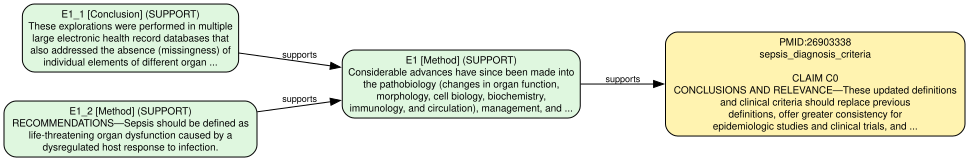

Saved: Annane_Sepsis_Corpus\papers\PMID_26903338\argument_tree_v3.json

Testing PMID:15025773
Paper: PMID:15025773  Topic: steroid_sensitivity  TextLen: 12000

CLAIM:
  [ABSTRACT] The use of glucocorticoids (corticotherapy) in severe sepsis is one of the main controversial issues in critical care medicine.
  type:unknown  score:6.00

EVIDENCE TREE (1 L1 nodes):
[ATTACK] [ABSTRACT] These agents were commonly used to treat sepsis until the end of the 1980 s, when several randomize

DEBUG: {'n_sents': 7, 'n_l1_evidence': 1, 'n_total_evidence_nodes': 1, 'n_support_l1': 0, 'n_attack_l1': 1}


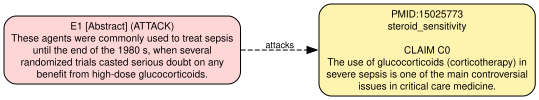

Saved: Annane_Sepsis_Corpus\papers\PMID_15025773\argument_tree_v3.json


In [122]:
import json

def test_single_paper(pmid: str):
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    if not (paper_dir/"sections.json").exists():
        print(f"Cannot find {paper_dir/'sections.json'}"); return None
    obj      = json.loads((paper_dir/"sections.json").read_text(encoding="utf-8"))
    paper_id = f"PMID:{obj.get('pmid',pmid)}"
    topic    = obj.get("topic","UNKNOWN")
    text     = paper_text_from_sections(obj)
    if is_low_quality_text(text):
        print(f"SKIP low quality: {paper_id}"); return None
    print(f"Paper: {paper_id}  Topic: {topic}  TextLen: {len(text)}")
    q_obj = pick_quotes_multilevel(paper_id, topic, text)
    print(f"\n{'='*60}\nCLAIM:\n  {q_obj['claim_quote'][:200]}")
    claim_text = re.sub(r"^\[[A-Z]+\]\s*", "", q_obj["claim_quote"])
    print(f"  type:{classify_sentence_type(claim_text).value}  score:{claim_score_v3(claim_text,topic):.2f}")
    print(f"\nEVIDENCE TREE ({len(q_obj['evidence_tree'])} L1 nodes):")
    def _pt(nodes, indent=0):
        for n in nodes:
            print(f"{'  '*indent}[{n['polarity'].upper()}] {n['quote'][:110]}")
            _pt(n.get("children",[]),indent+1)
    _pt(q_obj["evidence_tree"])
    print(f"\nDEBUG: {q_obj['debug']}")
    tree = build_tree_multilevel(paper_id, topic, q_obj["claim_quote"], q_obj["evidence_tree"])
    (paper_dir/"argument_tree_v3.json").write_text(json.dumps(tree,ensure_ascii=False,indent=2),encoding="utf-8")
    viz_path = VIZ_DIR/f"{pmid}_v3"
    render_tree_svg_multilevel(tree, viz_path, show=True)
    print(f"Saved: {paper_dir/'argument_tree_v3.json'}")
    return tree

for pmid in ["26903338","15025773"]:
    print(f"\n{'='*60}\nTesting PMID:{pmid}\n{'='*60}")
    try:    test_single_paper(pmid)
    except: traceback.print_exc()


▶ 测试 PMID:26903338
📄 Paper: PMID:26903338
📝 Topic: sepsis_diagnosis_criteria
📊 Text length: 12000

CLAIM:
  [CONCLUSION] CONCLUSIONS AND RELEVANCE—These updated definitions and clinical criteria should replace previous definitions, offer greater consistency for epidemiologic studies and clinical trials, and
  类型: conclusion
  评分: 9.00

EVIDENCE TREE (1 个一级节点):

[SUPPORT] [METHOD] Considerable advances have since been made into the pathobiology (changes in organ function, morpholo
  [SUPPORT] [CONCLUSION] These explorations were performed in multiple large electronic health record databases that also 
  [SUPPORT] [METHOD] RECOMMENDATIONS—Sepsis should be defined as life-threatening organ dysfunction caused by a dysregulat

DEBUG: {'n_sents': 65, 'n_l1_evidence': 1, 'n_total_evidence_nodes': 3, 'n_support_l1': 1, 'n_attack_l1': 0}



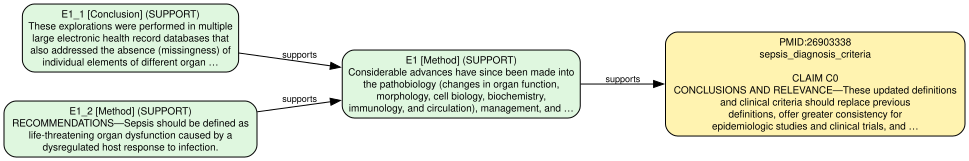

✅ 已保存: Annane_Sepsis_Corpus\papers\PMID_26903338\argument_tree_v3.json
✅ 已保存: Annane_Sepsis_Corpus\out2\viz2\26903338_v3.svg

▶ 测试 PMID:15025773
📄 Paper: PMID:15025773
📝 Topic: steroid_sensitivity
📊 Text length: 12000

CLAIM:
  [ABSTRACT] The use of glucocorticoids (corticotherapy) in severe sepsis is one of the main controversial issues in critical care medicine.
  类型: unknown
  评分: 6.00

EVIDENCE TREE (1 个一级节点):

[ATTACK] [ABSTRACT] These agents were commonly used to treat sepsis until the end of the 1980 s, when several randomize

DEBUG: {'n_sents': 7, 'n_l1_evidence': 1, 'n_total_evidence_nodes': 1, 'n_support_l1': 0, 'n_attack_l1': 1}



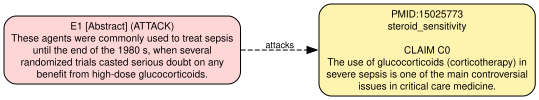

✅ 已保存: Annane_Sepsis_Corpus\papers\PMID_15025773\argument_tree_v3.json
✅ 已保存: Annane_Sepsis_Corpus\out2\viz2\15025773_v3.svg


In [96]:
import json, traceback

def test_single_paper(pmid: str):
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    if not (paper_dir / "sections.json").exists():
        print(f"❌ Cannot find {paper_dir / 'sections.json'}"); return None

    obj      = json.loads((paper_dir / "sections.json").read_text(encoding="utf-8"))
    paper_id = f"PMID:{obj.get('pmid', pmid)}"
    topic    = obj.get("topic", "UNKNOWN")
    text     = paper_text_from_sections(obj)

    print(f"📄 Paper: {paper_id}")
    print(f"📝 Topic: {topic}")
    print(f"📊 Text length: {len(text)}\n")

    q_obj = pick_quotes_multilevel(paper_id, topic, text)

    print(f"{'='*60}")
    print(f"CLAIM:")
    print(f"  {q_obj['claim_quote'][:200]}")
    claim_text = re.sub(r"^\[[A-Z]+\]\s*", "", q_obj["claim_quote"])
    print(f"  Type: {classify_sentence_type(claim_text).value}")
    print(f"  Score: {claim_score_v3(claim_text, topic):.2f}")

    print(f"\n{'='*60}")
    print(f"EVIDENCE TREE ({len(q_obj['evidence_tree'])} top-level nodes):\n")

    def _print_tree(nodes, indent=0):
        for node in nodes:
            print(f"{'  '*indent}[{node['polarity'].upper()}] {node['quote'][:110]}")
            _print_tree(node.get("children",[]), indent+1)
    _print_tree(q_obj["evidence_tree"])

    print(f"\n{'='*60}")
    print(f"DEBUG: {q_obj['debug']}\n")

    tree = build_tree_multilevel(paper_id, topic, q_obj["claim_quote"], q_obj["evidence_tree"])
    (paper_dir / "argument_tree_v3.json").write_text(
        json.dumps(tree, ensure_ascii=False, indent=2), encoding="utf-8")

    viz_path = VIZ_DIR / f"{pmid}_v3"
    render_tree_svg_multilevel(tree, viz_path, show=True)
    print(f"✅ Saved: {paper_dir / 'argument_tree_v3.json'}")
    print(f"✅ Saved: {viz_path}.svg")
    return tree

# ── Run the single-paper test ──────────────────────
print("=" * 60)
print("▶ Test PMID:26903338")
print("=" * 60)
try:
    test_single_paper("26903338")
except Exception:
    traceback.print_exc()

print()
print("=" * 60)
print("▶ Test PMID:15025773")
print("=" * 60)
try:
    test_single_paper("15025773")
except Exception:
    traceback.print_exc()


## Cell 12: Batch processing

In [123]:
import json

def process_all_papers_v3(limit: int = 999):
    OUT_JSONL = OUT_DIR / "argument_trees_v3.jsonl"

    def iter_ready_papers():
        for p in sorted(PAPERS_DIR.glob("PMID_*")):
            sec_file = p/"sections.json"
            if not sec_file.exists(): continue
            obj  = json.loads(sec_file.read_text(encoding="utf-8"))
            text = paper_text_from_sections(obj, max_chars=12000)
            if is_low_quality_text(text):
                print(f"  SKIP low-quality: PMID:{obj.get('pmid','?')}"); continue
            topic = obj.get("topic","")
            if resolve_topic(topic) not in THEME_KEYWORDS:
                print(f"  SKIP unknown topic: PMID:{obj.get('pmid','?')} topic={topic}"); continue
            yield p, obj, text

    def _count_pol(nodes, pol):
        return sum((1 if n["polarity"]==pol else 0)+_count_pol(n.get("children",[]),pol) for n in nodes)

    ok_cnt=fail_cnt=0
    stats={"total_papers":0,"total_evidence_nodes":0,"support_count":0,"attack_count":0}

    with OUT_JSONL.open("w",encoding="utf-8") as f:
        for paper_dir, obj, text in list(iter_ready_papers())[:limit]:
            paper_id = f"PMID:{obj.get('pmid','UNKNOWN')}"
            topic    = obj.get("topic","UNKNOWN")
            print(f"\n{'='*50}\n{paper_id}  topic:{topic}")
            try:
                q_obj   = pick_quotes_multilevel(paper_id,topic,text)
                ev_tree = q_obj.get("evidence_tree",[])
                n_s=_count_pol(ev_tree,"support"); n_a=_count_pol(ev_tree,"attack")
                print(f"  Evidence: {q_obj['debug']['n_total_evidence_nodes']} nodes (S={n_s} A={n_a})")
                stats["total_papers"]+=1; stats["total_evidence_nodes"]+=q_obj["debug"]["n_total_evidence_nodes"]
                stats["support_count"]+=n_s; stats["attack_count"]+=n_a
                tree=build_tree_multilevel(paper_id,topic,q_obj["claim_quote"],ev_tree)
                (paper_dir/"argument_tree_v3.json").write_text(json.dumps(tree,ensure_ascii=False,indent=2),encoding="utf-8")
                f.write(json.dumps(tree,ensure_ascii=False)+"\n"); f.flush()
                viz_path=VIZ_DIR/f"{paper_id.replace(':','_')}_v3"
                render_tree_svg_multilevel(tree,viz_path,fmt="svg",show=False)
                ok_cnt+=1; print("  OK")
            except Exception as e:
                fail_cnt+=1; print(f"  FAIL: {repr(e)}"); traceback.print_exc()

    tot=max(1,stats["total_evidence_nodes"])
    print(f"\nDone  OK:{ok_cnt}  FAIL:{fail_cnt}")
    print(f"Papers:{stats['total_papers']}  Evidence nodes:{stats['total_evidence_nodes']}")
    print(f"Support:{stats['support_count']} ({stats['support_count']/tot*100:.1f}%)  Attack:{stats['attack_count']} ({stats['attack_count']/tot*100:.1f}%)")
    print(f"Output: {OUT_JSONL}")

process_all_papers_v3()


  SKIP low-quality: PMID:29025194
  SKIP unknown topic: PMID:33150472 topic=sepsis_treatment_plan
  SKIP unknown topic: PMID:37176780 topic=sepsis_treatment_plan
  SKIP unknown topic: PMID:38250247 topic=sepsis_treatment_plan
  SKIP unknown topic: PMID:41180093 topic=sepsis_treatment_plan

PMID:15025773  topic:steroid_sensitivity
  Evidence: 1 nodes (S=0 A=1)
  OK

PMID:23361625  topic:sepsis_diagnosis_criteria
  Evidence: 4 nodes (S=4 A=0)
  OK

PMID:26633262  topic:steroid_sensitivity
  Evidence: 1 nodes (S=1 A=0)
  OK

PMID:26903338  topic:sepsis_diagnosis_criteria
  Evidence: 3 nodes (S=3 A=0)
  OK

PMID:27379022  topic:steroid_sensitivity
  Evidence: 2 nodes (S=2 A=0)
  OK

PMID:30105022  topic:sepsis_diagnosis_criteria
  Evidence: 2 nodes (S=2 A=0)
  OK

PMID:30111341  topic:sepsis_diagnosis_criteria
  Evidence: 2 nodes (S=2 A=0)
  OK

PMID:30911807  topic:treatment_recommendation
  Evidence: 0 nodes (S=0 A=0)
  OK

PMID:31206313  topic:symptoms_diagnosis
  Evidence: 3 nodes (S=1

## Cell 13: Diagnostics

In [124]:
import json

def diagnose_paper(pmid: str):
    paper_dir = PAPERS_DIR/f"PMID_{pmid}"
    obj  = json.loads((paper_dir/"sections.json").read_text(encoding="utf-8"))
    text = paper_text_from_sections(obj)
    print(f"PMID:{pmid}  topic:{obj.get('topic')}  low_quality:{is_low_quality_text(text)}")
    sents,_ = build_indexed_sentences_by_section(text,max_sents=200)
    print(f"Sentences: {len(sents)}")
    sc={};tc={}
    for s in sents:
        sc[s.get("sec","?")] = sc.get(s.get("sec","?"),0)+1
        t=classify_sentence_type(s.get("sent","")).value; tc[t]=tc.get(t,0)+1
    print("Sections:", sc)
    print("Types:", tc)
    vc=[s for s in sents if is_valid_claim_type(s.get("sent",""))]
    ve=[s for s in sents if is_valid_evidence_type(s.get("sent",""))]
    print(f"Valid claim candidates: {len(vc)}  Valid evidence candidates: {len(ve)}")

# Usage: diagnose_paper("26903338")
print("Diagnostic tool loaded - call diagnose_paper('PMID') to use")


Diagnostic tool loaded - call diagnose_paper('PMID') to use


## Cell 14: Cross-paper integrated argument tree

Topics found in jsonl: {'sepsis_diagnosis_criteria', 'sequelae_prevention', 'steroid_sensitivity', 'treatment_recommendation', 'symptoms_diagnosis'}

Building synthesis tree: sepsis_diagnosis_criteria
Found 38 papers, topic=sepsis_diagnosis_criteria
Clusters: 26 (from 27 valid claims)

  Cluster CL1 (2 papers):
  Rep claim: Purpose: Insufficient antimicrobial exposure is associated with worse outcomes in sepsis.
  Evidence: 5 (support=1, attack=4)

  Cluster CL2 (1 papers):
  Rep claim: Purpose: Ilofotase alfa is a human recombinant alkaline phosphatase with reno-protective effects tha
  Evidence: 0 (support=0, attack=0)

  Cluster CL3 (1 papers):
  Rep claim: Conclusions: Strong agreemaneuvers in sepsis patients with upper gastrointestinal bleeding in ment e
  Evidence: 4 (support=4, attack=0)

  Cluster CL4 (1 papers):
  Rep claim: CONCLUSIONS AND RELEVANCE—These updated definitions and clinical criteria should replace previous de
  Evidence: 3 (support=3, attack=0)

  Cluster CL5 (1

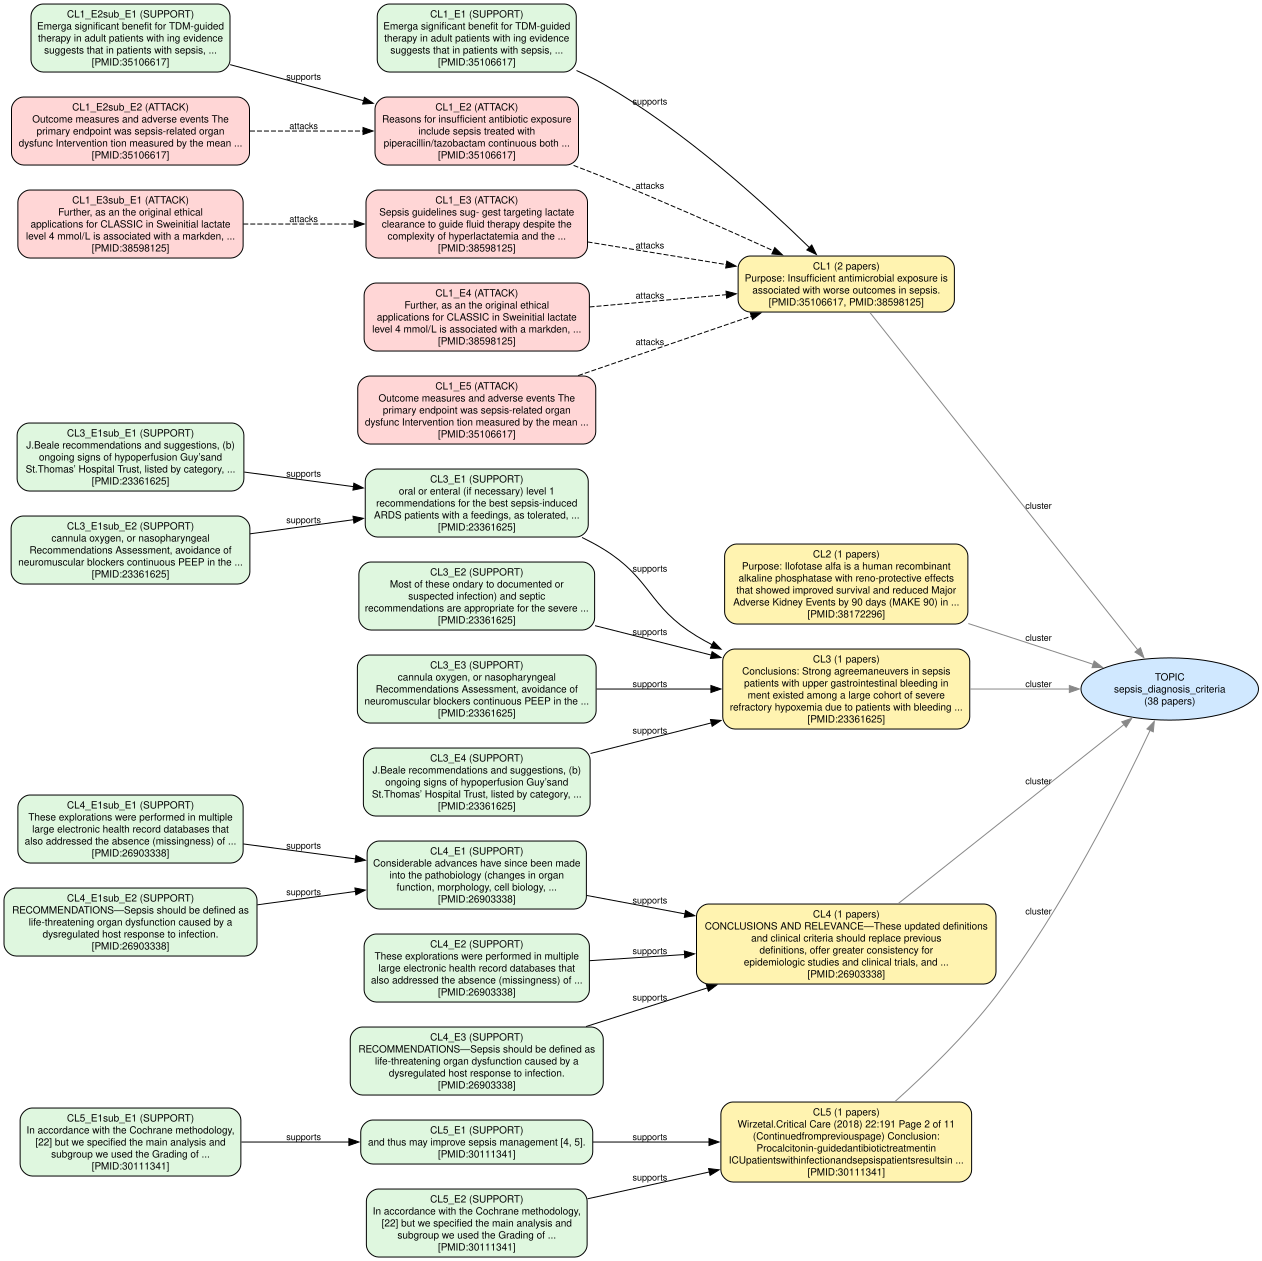

Saved SVG: Annane_Sepsis_Corpus\out2\viz2\cross_sepsis_diagnosis_criteria.svg

Building synthesis tree: sequelae_prevention
Found 4 papers, topic=sequelae_prevention
Clusters: 3 (from 3 valid claims)

  Cluster CL1 (1 papers):
  Rep claim: Purpose: Sepsis-associated immunosuppression increases hospital-acquired infection and viral reactiv
  Evidence: 4 (support=2, attack=2)

  Cluster CL2 (1 papers):
  Rep claim: Purpose: Sepsis survivors have a higher risk of rehospitalisation and of long‑term mortality.
  Evidence: 1 (support=1, attack=0)

  Cluster CL3 (1 papers):
  Rep claim: OBJECTIVES: To evaluate whether a nurse navigator-led, multicomponent Sepsis Transition And Recovery
  Evidence: 1 (support=1, attack=0)
Saved JSON: Annane_Sepsis_Corpus\out2\cross_tree_sequelae_prevention.json


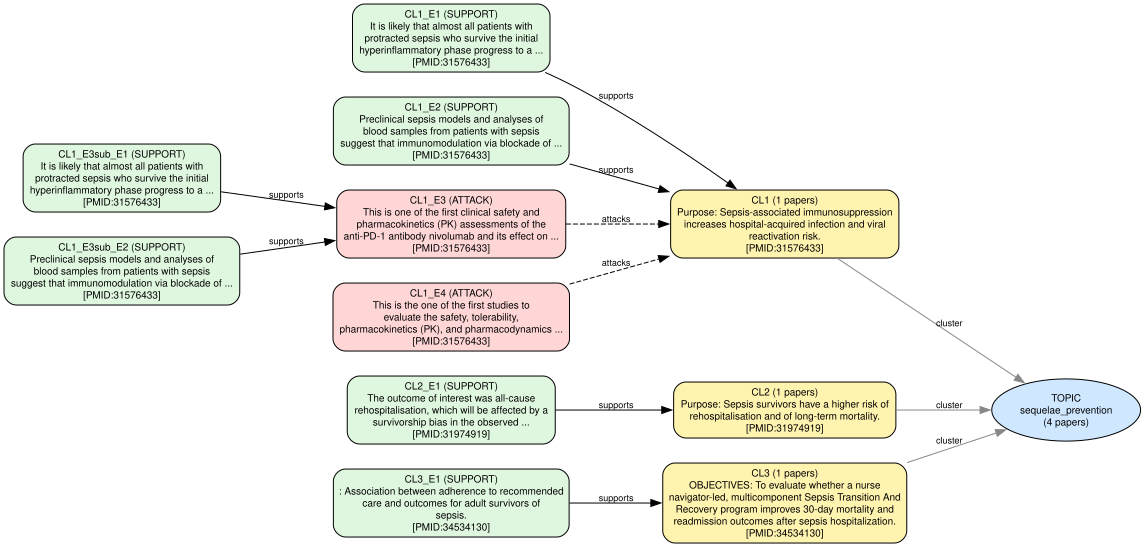

Saved SVG: Annane_Sepsis_Corpus\out2\viz2\cross_sequelae_prevention.svg

Building synthesis tree: steroid_sensitivity
Found 4 papers, topic=steroid_sensitivity
Clusters: 2 (from 2 valid claims)

  Cluster CL1 (1 papers):
  Rep claim: In animals, sepsis is associated with proinflammatory cytokines (mainly TNF and IL-1) early marked i
  Evidence: 2 (support=2, attack=0)

  Cluster CL2 (1 papers):
  Rep claim: The use of glucocorticoids (corticotherapy) in severe sepsis is one of the main controversial issues
  Evidence: 1 (support=0, attack=1)
Saved JSON: Annane_Sepsis_Corpus\out2\cross_tree_steroid_sensitivity.json


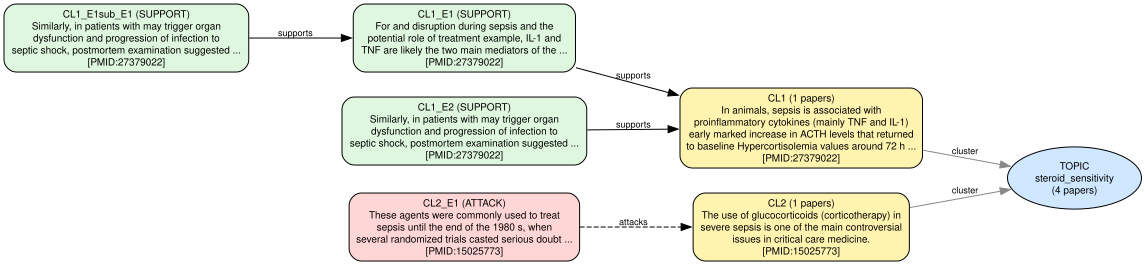

Saved SVG: Annane_Sepsis_Corpus\out2\viz2\cross_steroid_sensitivity.svg

Building synthesis tree: symptoms_diagnosis
Found 38 papers, topic=symptoms_diagnosis
Clusters: 26 (from 27 valid claims)

  Cluster CL1 (2 papers):
  Rep claim: Purpose: Insufficient antimicrobial exposure is associated with worse outcomes in sepsis.
  Evidence: 5 (support=1, attack=4)

  Cluster CL2 (1 papers):
  Rep claim: Purpose: Ilofotase alfa is a human recombinant alkaline phosphatase with reno-protective effects tha
  Evidence: 0 (support=0, attack=0)

  Cluster CL3 (1 papers):
  Rep claim: Conclusions: Strong agreemaneuvers in sepsis patients with upper gastrointestinal bleeding in ment e
  Evidence: 4 (support=4, attack=0)

  Cluster CL4 (1 papers):
  Rep claim: CONCLUSIONS AND RELEVANCE—These updated definitions and clinical criteria should replace previous de
  Evidence: 3 (support=3, attack=0)

  Cluster CL5 (1 papers):
  Rep claim: Wirzetal.Critical Care (2018) 22:191 Page 2 of 11 (Continuedfromprev

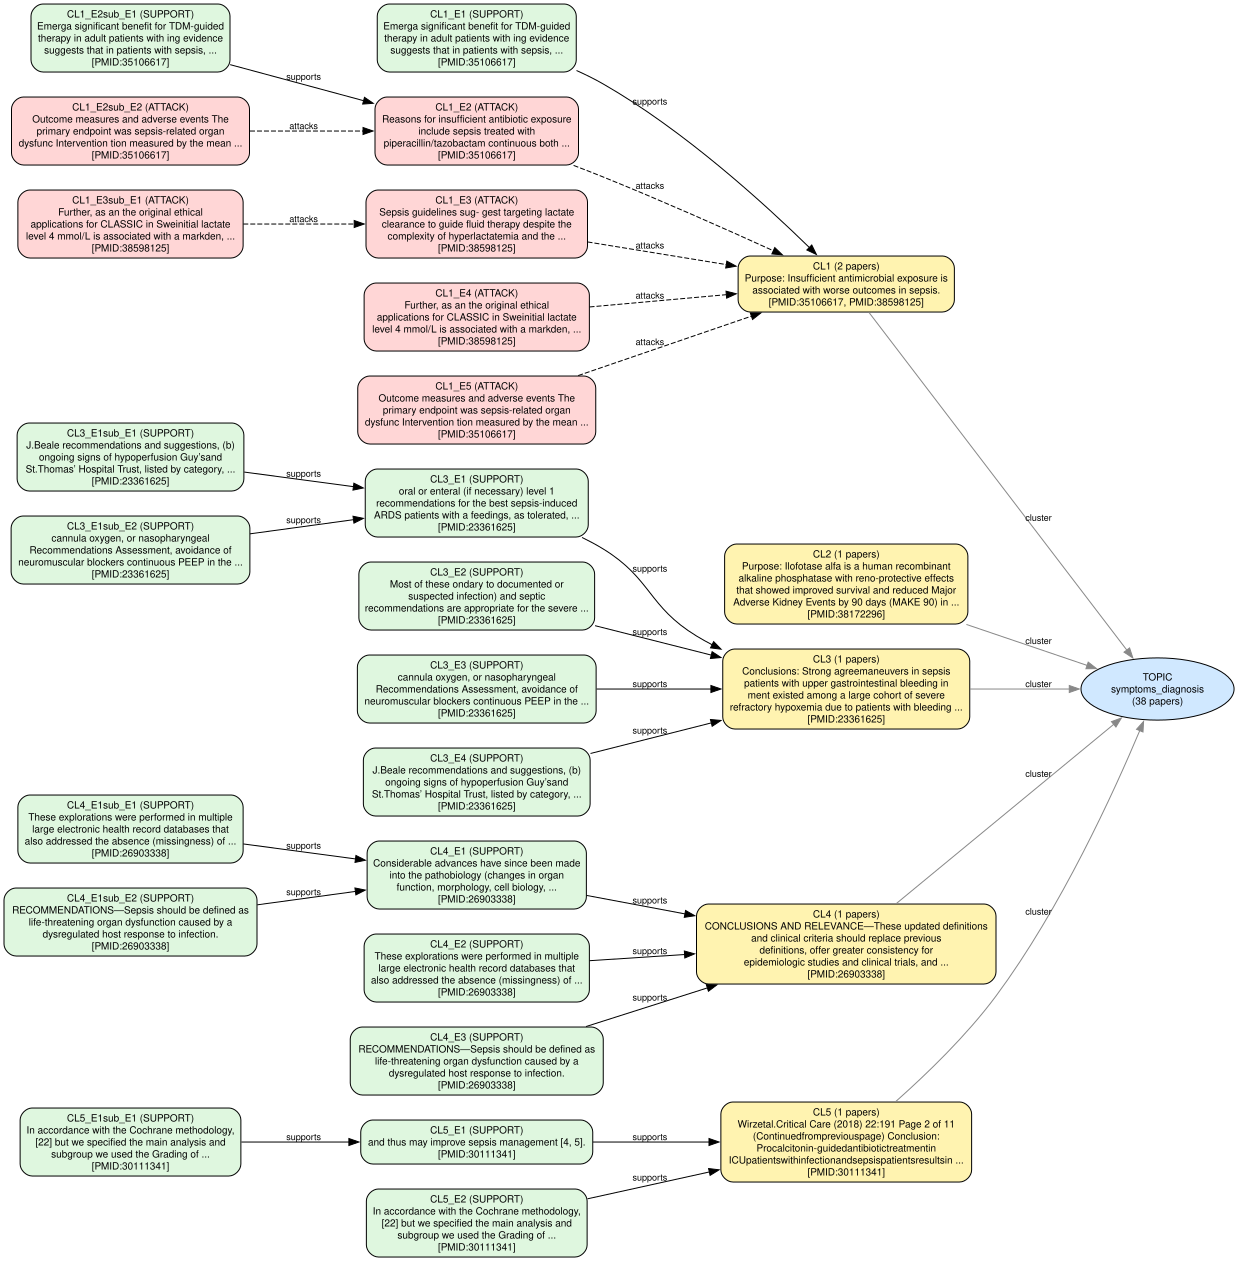

Saved SVG: Annane_Sepsis_Corpus\out2\viz2\cross_symptoms_diagnosis.svg

Building synthesis tree: treatment_recommendation
Found 13 papers, topic=treatment_recommendation
Clusters: 6 (from 6 valid claims)

  Cluster CL1 (1 papers):
  Rep claim: Sepsis/septic shock and pneumonia were the most common outcomes, occurring in 18.0% (1526/8469), 12.
  Evidence: 0 (support=0, attack=0)

  Cluster CL2 (1 papers):
  Rep claim: We aimed to summarize the epidemiological evidence related to the burden of hospital‑ acquired (HA) 
  Evidence: 0 (support=0, attack=0)

  Cluster CL3 (1 papers):
  Rep claim: We aimed to compare the effects of vitamin C, glucocorticoids, vitamin B 1, combinations of these dr
  Evidence: 0 (support=0, attack=0)

  Cluster CL4 (1 papers):
  Rep claim: Secondary outcomes included postextubation respiratory failure, respiratory infection, sepsis, multi
  Evidence: 0 (support=0, attack=0)

  Cluster CL5 (1 papers):
  Rep claim: Critical care trials evaluate the effect of inte

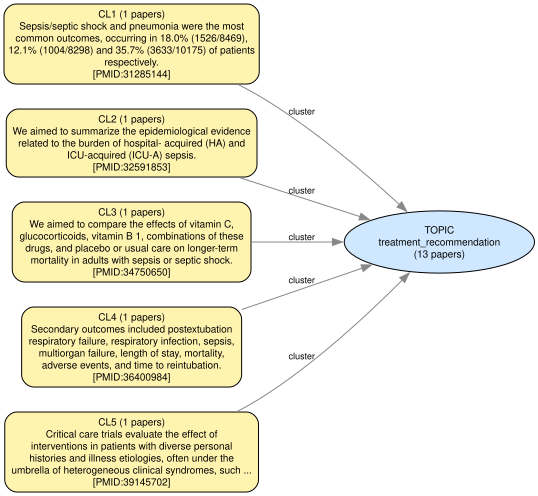

Saved SVG: Annane_Sepsis_Corpus\out2\viz2\cross_treatment_recommendation.svg

All synthesis trees saved: Annane_Sepsis_Corpus\out2\cross_trees_all.json


{'sepsis_diagnosis_criteria': {'topic': 'sepsis_diagnosis_criteria',
  'n_source_papers': 38,
  'clusters': [{'cluster_id': 'CL1',
    'representative_claim': 'Purpose: Insufficient antimicrobial exposure is associated with worse outcomes in sepsis.',
    'representative_claim_quote': '[ABSTRACT] Purpose: Insufficient antimicrobial exposure is associated with worse outcomes in sepsis.',
    'source_papers': ['PMID:35106617', 'PMID:38598125'],
    'n_papers': 2,
    'evidence': [{'quote': '[INTRODUCTION] Emerga significant benefit for TDM-guided therapy in adult patients with ing evidence suggests that in patients with sepsis, insufsepsis and continuous infusion of piperacillin/tazobactam with ficient antibiotic exposure, defined as failure to meet the regard to the primary endpoint, namely, the mean total SOFA score.',
      'polarity': 'support',
      'paper_id': 'PMID:35106617',
      'children': []},
     {'quote': '[INTRODUCTION] Reasons for insufficient antibiotic exposure includ

In [125]:
import json

def _jaccard(a, b):
    ta=set(re.findall(r"[a-z]{3,}",_norm(a))); tb=set(re.findall(r"[a-z]{3,}",_norm(b)))
    if not ta or not tb: return 0.0
    return len(ta&tb)/len(ta|tb)

def cluster_claims(claims, threshold=0.35):
    # Higher threshold (0.35) avoids clustering unrelated claims
    clusters=[]; used=[False]*len(claims)
    for i,ci in enumerate(claims):
        if used[i]: continue
        cluster=[ci]; used[i]=True
        for j,cj in enumerate(claims):
            if used[j]: continue
            if _jaccard(ci["claim_text"],cj["claim_text"])>=threshold:
                cluster.append(cj); used[j]=True
        clusters.append(cluster)
    return clusters

def build_cross_paper_tree(jsonl_path, topic_filter=None, max_clusters=6, max_ev_per_claim=8):
    trees=[]
    with open(jsonl_path,encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            try: trees.append(json.loads(line))
            except: continue

    # KEY FIX: match both original topic name and alias
    if topic_filter:
        resolved_filter=resolve_topic(topic_filter)
        trees=[t for t in trees
               if resolve_topic(t.get("topic",""))==resolved_filter
               or t.get("topic","")==topic_filter]

    if not trees:
        print(f"No papers found for topic: {topic_filter}"); return {}
    print(f"Found {len(trees)} papers, topic={topic_filter}")

    all_claims=[]
    for tree in trees:
        pid=tree.get("paper_id","?"); root=tree.get("root") or {}
        claim_text=normalize_text_for_split(root.get("text",""))
        if not claim_text: continue
        if not is_topic_relevant(claim_text,topic_filter,min_score=3.0): continue
        all_claims.append({
            "paper_id":pid,"claim_text":claim_text,
            "claim_quote":root.get("source",{}).get("quote",""),
            "score":claim_score_v3(claim_text,topic_filter),"tree":tree,
        })

    if not all_claims:
        print("No topic-relevant claims after filtering"); return {}

    clusters_raw=cluster_claims(all_claims,threshold=0.35)
    print(f"Clusters: {len(clusters_raw)} (from {len(all_claims)} valid claims)")
    clusters_raw.sort(key=lambda cl:max(c["score"] for c in cl),reverse=True)
    clusters_raw=clusters_raw[:max_clusters]

    result_clusters=[]
    for ci,cluster in enumerate(clusters_raw,1):
        rep=max(cluster,key=lambda x:x["score"])
        rep_claim_text=rep["claim_text"]
        source_papers=list({c["paper_id"] for c in cluster})
        print(f"\n  Cluster CL{ci} ({len(cluster)} papers):")
        print(f"  Rep claim: {rep_claim_text[:100]}")

        # KEY FIX: use a fresh local list name to avoid UnboundLocalError
        ev_pool_items=[]
        def _collect(nodes, pid, depth=0):
            for node in nodes:
                clean_text=normalize_text_for_split(node.get("text",""))
                ev_pool_items.append({
                    "quote":     node.get("source",{}).get("quote",""),
                    "text":      clean_text,
                    "polarity":  node.get("polarity","irrelevant"),
                    "paper_id":  pid,
                    "depth":     depth,
                    "children_raw": node.get("children",[]),
                })
                _collect(node.get("children",[]),pid,depth+1)

        for c in cluster:
            _collect(c["tree"].get("root",{}).get("children",[]),c["paper_id"])

        # Dedup
        seen_k=set(); deduped=[]
        for ev in ev_pool_items:
            k=_norm(ev["text"])
            if k in seen_k or not ev["text"] or len(ev["text"])<30: continue
            seen_k.add(k); deduped.append(ev)

        # KEY FIX: topic filter on evidence - use local var name 'filtered_evs'
        filtered_evs=[ev for ev in deduped
                      if is_topic_relevant(ev["text"],topic_filter,min_score=3.0)]
        if len(filtered_evs)<3:
            filtered_evs=[ev for ev in deduped
                          if is_topic_relevant(ev["text"],topic_filter,min_score=1.0)]

        filtered_evs.sort(
            key=lambda ev: _jaccard(rep_claim_text,ev["text"])
                         +(1.0 if ev["polarity"] in ("support","attack") else 0.0)
                         -0.1*ev["depth"],
            reverse=True,
        )

        supports=[e for e in filtered_evs if e["polarity"]=="support"]
        attacks =[e for e in filtered_evs if e["polarity"]=="attack"]
        final_evs=supports[:3]+attacks[:3]
        budget=max_ev_per_claim-len(final_evs)
        if budget>0:
            extra=[e for e in filtered_evs if e not in final_evs]
            final_evs.extend(extra[:budget])

        ev_out=[{
            "quote":ev["quote"],"polarity":ev["polarity"],"paper_id":ev["paper_id"],
            "children":[{
                "quote":ch.get("source",{}).get("quote",""),
                "polarity":ch.get("polarity","irrelevant"),
                "paper_id":ev["paper_id"],"children":[],
            } for ch in ev.get("children_raw",[])[:2]],
        } for ev in final_evs]

        n_s=sum(1 for e in final_evs if e["polarity"]=="support")
        n_a=sum(1 for e in final_evs if e["polarity"]=="attack")
        print(f"  Evidence: {len(final_evs)} (support={n_s}, attack={n_a})")

        result_clusters.append({
            "cluster_id":f"CL{ci}","representative_claim":rep_claim_text,
            "representative_claim_quote":rep["claim_quote"],
            "source_papers":source_papers,"n_papers":len(cluster),"evidence":ev_out,
        })

    return {"topic":topic_filter or "all","n_source_papers":len(trees),"clusters":result_clusters}


def render_cross_paper_tree_svg(cross_tree, out_path, fmt="svg", show=True):
    topic=cross_tree.get("topic","ALL"); n_papers=cross_tree.get("n_source_papers",0)
    clusters=cross_tree.get("clusters",[])
    g=Digraph(comment=f"cross_{topic}",format=fmt)
    g.attr(rankdir="LR",splines="spline",nodesep="0.35",ranksep="0.8")
    g.attr("node",shape="box",style="rounded,filled",fontname="Helvetica",fontsize="10")
    g.attr("edge",fontname="Helvetica",fontsize="9")
    g.node("TOPIC",label=f"TOPIC\n{topic}\n({n_papers} papers)",
           fillcolor="#D0E8FF",shape="ellipse",style="filled")
    for cluster in clusters:
        cid=cluster["cluster_id"]; rep_text=cluster["representative_claim"]; n_p=cluster["n_papers"]
        src=", ".join(cluster["source_papers"][:3])
        if len(cluster["source_papers"])>3: src+=f" +{len(cluster['source_papers'])-3}"
        g.node(cid,label=f"{cid} ({n_p} papers)\n{wrap_label(rep_text,width=52,max_lines=4)}\n[{src}]",
               fillcolor=NODE_COLORS["claim"])
        g.edge(cid,"TOPIC",label="cluster",style="solid",color="#888888")
        def _add_ev(evs,parent_id,prefix):
            for j,ev in enumerate(evs,1):
                eid=f"{prefix}_E{j}"; pol=ev.get("polarity","irrelevant")
                evtext=normalize_text_for_split(_strip_sec(ev.get("quote",ev.get("text",""))))
                ev_pid=ev.get("paper_id","")
                g.node(eid,label=f"{eid} ({pol.upper()})\n{wrap_label(evtext,width=46,max_lines=3)}\n[{ev_pid}]",
                       fillcolor=NODE_COLORS.get(pol,NODE_COLORS["irrelevant"]))
                el="attacks" if pol=="attack" else ("supports" if pol=="support" else pol)
                es="dashed"  if pol=="attack" else ("solid"    if pol=="support" else "dotted")
                g.edge(eid,parent_id,label=el,style=es)
                if ev.get("children"): _add_ev(ev["children"],eid,f"{eid}sub")
        _add_ev(cluster.get("evidence",[]),cid,prefix=cid)
    out_file=g.render(str(out_path),cleanup=True)
    if show and fmt=="svg":
        from IPython.display import SVG,display
        display(SVG(filename=out_file))
    return out_file


def run_cross_paper_analysis():
    JSONL_PATH=OUT_DIR/"argument_trees_v3.jsonl"
    if not JSONL_PATH.exists():
        print("Please run Cell 12 first to generate argument_trees_v3.jsonl"); return

    # Scan actual topics in jsonl
    actual_topics=set()
    with open(JSONL_PATH,encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            try:
                t=json.loads(line).get("topic","")
                if t: actual_topics.add(t)
            except: continue
    print(f"Topics found in jsonl: {actual_topics}")

    all_cross_trees={}
    for topic in sorted(actual_topics):
        print(f"\n{'='*60}\nBuilding synthesis tree: {topic}")
        try:
            cross_tree=build_cross_paper_tree(JSONL_PATH,topic_filter=topic,max_clusters=5,max_ev_per_claim=8)
            if not cross_tree: continue
            all_cross_trees[topic]=cross_tree
            out_json=OUT_DIR/f"cross_tree_{topic}.json"
            out_json.write_text(json.dumps(cross_tree,ensure_ascii=False,indent=2),encoding="utf-8")
            print(f"Saved JSON: {out_json}")
            viz_path=VIZ_DIR/f"cross_{topic}"
            render_cross_paper_tree_svg(cross_tree,viz_path,fmt="svg",show=True)
            print(f"Saved SVG: {viz_path}.svg")
        except Exception: traceback.print_exc()

    summary=OUT_DIR/"cross_trees_all.json"
    summary.write_text(json.dumps(all_cross_trees,ensure_ascii=False,indent=2),encoding="utf-8")
    print(f"\nAll synthesis trees saved: {summary}")
    return all_cross_trees

run_cross_paper_analysis()


In [7]:
# ==========================================
# Cell 15: LLM Validation via OpenRouter
# ==========================================

import os, json, time, re
from pathlib import Path
from typing import Optional
from openai import OpenAI

# ── Configuration ─────────────────────────────────────────────
OPENROUTER_API_KEY = "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"   # ← replace with your key

# ✅ Candidate models (intersected at runtime with the models actually available in your account)
FREE_MODELS_PREFERRED = [
    "meta-llama/llama-3.3-70b-instruct:free",   # 70B, good quality
    "nousresearch/hermes-3-llama-3.1-405b:free",# 405B, strongest option
    "nvidia/nemotron-3-super-120b-a12b:free",    # 120B backup option
    "mistralai/mistral-small-3.1-24b-instruct:free",
    "google/gemma-3-27b-it:free",
    "google/gemma-3-12b-it:free",
    "openai/gpt-oss-20b:free",
]
FREE_MODELS = FREE_MODELS_PREFERRED  # Reordered after check_available_models
MODEL = FREE_MODELS[0]

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_DIR    = CORPUS_DIR / "out2"
VAL_DIR    = OUT_DIR / "validation"
VAL_DIR.mkdir(parents=True, exist_ok=True)

SLEEP_BETWEEN_CALLS  = 4    # seconds; free-tier RPM is very low
MAX_PAPERS_TO_VALIDATE = 20

# ── Diagnose first: query the models available in your account ─────────────────────
def check_available_models():
    """List the free models currently available on OpenRouter."""
    import requests
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}"}
    try:
        r = requests.get("https://openrouter.ai/api/v1/models", headers=headers, timeout=10)
        r.raise_for_status()
        models = r.json().get("data", [])
        free_models = [
            m["id"] for m in models
            if ":free" in m["id"]
            or (m.get("pricing", {}).get("prompt", "1") in ("0", "0.0", 0))
        ]
        print(f"✅ API key valid. Free models available ({len(free_models)}):")
        for m in sorted(free_models)[:20]:
            print(f"   {m}")
        return free_models
    except Exception as e:
        print(f"❌ Cannot reach OpenRouter: {e}")
        return []

print("🔍 Checking API key and available models...")
available_free = check_available_models()

# ── Find the first model that is actually available ────────────────────────────
def pick_working_model(preferred: list, available: list) -> tuple:
    """
    Pick the first model from preferred that also appears in available.
    Also return a filtered candidate list that only contains actually available models.
    """
    # Keep only candidates that really appear in available
    reachable = [m for m in preferred if m in available]
    # Then add the remaining available models with matching keywords as a fallback
    keywords = ["llama", "nemotron", "mistral", "gemma", "gpt-oss", "hermes"]
    for a in available:
        if a not in reachable and any(k in a for k in keywords):
            reachable.append(a)
    if not reachable:
        reachable = list(available)   # Final fallback: keep them all

    chosen = reachable[0]
    print(f"✅ Using model: {chosen}")
    print(f"   Fallback queue: {reachable[1:4]}")
    return chosen, reachable

if available_free:
    MODEL, FREE_MODELS = pick_working_model(FREE_MODELS_PREFERRED, available_free)
else:
    MODEL, FREE_MODELS = FREE_MODELS_PREFERRED[0], FREE_MODELS_PREFERRED
print(f"\n📌 Selected model: {MODEL}\n")

# ── OpenRouter client ────────────────────────────────────
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    default_headers={
        "HTTP-Referer": "https://localhost",
        "X-Title": "Sepsis ArgTree Validator",
    }
)

# ── Quick connectivity test ───────────────────────────────────────
def test_connection():
    """Try FREE_MODELS one by one, find the first one that responds normally, and update the global MODEL."""
    global MODEL, FREE_MODELS
    for candidate in list(FREE_MODELS):   # Iterate over a copy to avoid errors while modifying
        print(f"🧪 Testing: {candidate} ... ", end="", flush=True)
        try:
            resp = client.chat.completions.create(
                model=candidate,
                messages=[{"role": "user", "content": 'Reply with only: {"ok": true}'}],
                max_tokens=20,
                temperature=0,
            )
            raw = resp.choices[0].message.content.strip()
            print(f"✅  ({raw[:40]})")
            MODEL = candidate
            # Move the successful model to the front
            FREE_MODELS = [candidate] + [m for m in FREE_MODELS if m != candidate]
            return True
        except Exception as e:
            code = str(e)[:80]
            print(f"❌  {code}")
            time.sleep(2)
    print("❌ No working model found in FREE_MODELS")
    return False

connection_ok = test_connection()

# ── Prompt ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a critical care medicine expert and NLP evaluator. "
    "Validate automatically extracted argument structures from sepsis research papers. "
    "Be concise. Respond ONLY with valid JSON, no markdown fences, no explanation."
)

def build_prompt(paper_id, topic, claim, evidence_list):
    """
    Merge the system prompt into the user message so models that do not support the system role do not return a 400 error.
    """
    ev_lines = "".join(
        f'\n  E{i} [{ev["polarity"].upper()}]: "{ev["quote"][:180]}"'
        for i, ev in enumerate(evidence_list, 1)
    )
    return f"""You are a critical care medicine expert and NLP evaluator.
Validate automatically extracted argument structures from sepsis research papers.
Respond ONLY with valid JSON — no markdown, no extra text.

PAPER: {paper_id} | TOPIC: {topic}
CLAIM: "{claim}"
EVIDENCE:{ev_lines}

Return ONLY this JSON object:
{{
  "claim_quality": {{"score": <0-5>, "is_valid_claim": <true/false>, "is_topic_relevant": <true/false>, "issue": "<brief or none>"}},
  "evidence_evaluations": [{{"id": "E1", "polarity_correct": <true/false>, "is_relevant": <true/false>, "issue": "<brief or none>"}}],
  "overall_score": <0-5>,
  "summary": "<one sentence>"
}}"""

# ── Single-paper validation (with automatic model switching) ──────────────────────────
_current_model_idx = [FREE_MODELS.index(MODEL) if MODEL in FREE_MODELS else 0]

def validate_one_paper(paper_id, topic, claim_quote, evidence_tree):
    ev_flat = [
        {
            "polarity": n.get("polarity", "irrelevant"),
            "quote": re.sub(r"^\[[A-Z_]+\]\s*", "", n.get("quote", ""))[:180]
        }
        for n in evidence_tree[:5]
    ]
    if not ev_flat:
        return {"skipped": True, "reason": "no_evidence"}

    claim_text = re.sub(r"^\[[A-Z_]+\]\s*", "", claim_quote).strip()[:280]
    prompt = build_prompt(paper_id, topic, claim_text, ev_flat)

    global MODEL
    max_retries = len(FREE_MODELS) * 2   # Try each model at most twice

    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],  # no system role
                max_tokens=600,
                temperature=0.1,
            )
            raw = resp.choices[0].message.content.strip()
            # Remove possible ```json ... ``` wrappers
            raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
            raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()

            result = json.loads(raw)
            result.update({"paper_id": paper_id, "topic": topic, "model": MODEL})
            return result

        except json.JSONDecodeError:
            print(f"\n    ⚠️  Bad JSON (attempt {attempt+1}), raw: {raw[:120]}")
            time.sleep(2)

        except Exception as e:
            err = str(e)
            if "429" in err or "rate" in err.lower():
                # Rate limited → wait briefly, then switch models
                print(f"\n    🔄 Rate limited on {MODEL}, switching model...")
                time.sleep(10)
                _current_model_idx[0] = (_current_model_idx[0] + 1) % len(FREE_MODELS)
                MODEL = FREE_MODELS[_current_model_idx[0]]
                print(f"    📌 Now using: {MODEL}")
                time.sleep(5)

            elif "404" in err or "not found" in err.lower() or "unavailable" in err.lower():
                # Model unavailable → switch immediately
                print(f"\n    ❌ Model unavailable: {MODEL}, switching...")
                _current_model_idx[0] = (_current_model_idx[0] + 1) % len(FREE_MODELS)
                MODEL = FREE_MODELS[_current_model_idx[0]]
                print(f"    📌 Now using: {MODEL}")

            else:
                print(f"\n    ❌ Unexpected error: {err[:120]}")
                time.sleep(3)

    print(f"\n    ❌ All retries exhausted for {paper_id}")
    return None

# ── Batch validation ────────────────────────────────────────────
def run_llm_validation(limit=MAX_PAPERS_TO_VALIDATE):
    if not connection_ok:
        print("❌ Cannot proceed: connection test failed. Check your API key.")
        return None

    results_all = []
    stats = {
        "total": 0, "validated": 0, "skipped": 0, "failed": 0,
        "claim_scores": [], "overall_scores": [],
        "polarity_correct": 0, "polarity_total": 0,
    }

    tree_files = sorted(PAPERS_DIR.glob("PMID_*/argument_tree_v3.json"))
    print(f"Found {len(tree_files)} argument trees, validating up to {limit}\n")

    for i, tf in enumerate(tree_files[:limit]):
        pmid = tf.parent.name.replace("PMID_", "")
        stats["total"] += 1

        # Cache hit
        val_file = VAL_DIR / f"PMID_{pmid}_validation.json"
        if val_file.exists():
            cached = json.loads(val_file.read_text(encoding="utf-8"))
            results_all.append(cached)
            stats["validated"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — cached ✓")
            continue

        tree = json.loads(tf.read_text(encoding="utf-8"))
        root = tree.get("root", {})
        claim_quote = root.get("source", {}).get("quote", "") or root.get("text", "")
        topic = tree.get("topic", "unknown")

        if not claim_quote:
            stats["skipped"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — no claim, skip")
            continue

        print(f"  [{i+1:02d}] PMID:{pmid} ({topic[:25]}) ... ", end="", flush=True)

        result = validate_one_paper(pmid, topic, claim_quote, root.get("children", []))

        if result is None:
            stats["failed"] += 1
            print("FAILED ❌")
        elif result.get("skipped"):
            stats["skipped"] += 1
            print(f"SKIPPED ({result.get('reason')})")
        else:
            # Defensive step: LLM output is sometimes structurally incomplete
            cq  = result.get("claim_quality") or {}
            oq  = result.get("overall_score") or 0
            cs  = cq.get("score") or 0
            try:
                oq = int(oq); cs = int(cs)
            except (TypeError, ValueError):
                oq = 0; cs = 0

            stats["claim_scores"].append(cs)
            stats["overall_scores"].append(oq)
            for ev in result.get("evidence_evaluations") or []:
                stats["polarity_total"] += 1
                if ev.get("polarity_correct"): stats["polarity_correct"] += 1

            val_file.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
            results_all.append(result)
            stats["validated"] += 1

            flag = "✅" if cq.get("is_valid_claim") else "⚠️"
            issue = (cq.get("issue") or "")[:50]
            print(f"claim={cs}/5  overall={oq}/5  {flag}  {issue}")

        time.sleep(SLEEP_BETWEEN_CALLS)

    # ── Summary ────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"SUMMARY  |  validated={stats['validated']}  failed={stats['failed']}  skipped={stats['skipped']}")
    if stats["claim_scores"]:
        print(f"Avg claim score:   {sum(stats['claim_scores'])/len(stats['claim_scores']):.2f}/5")
        print(f"Avg overall score: {sum(stats['overall_scores'])/len(stats['overall_scores']):.2f}/5")
    if stats["polarity_total"]:
        acc = stats["polarity_correct"] / stats["polarity_total"] * 100
        print(f"Polarity accuracy: {stats['polarity_correct']}/{stats['polarity_total']} ({acc:.1f}%)")

    summary_path = OUT_DIR / "validation_summary.json"
    summary_path.write_text(
        json.dumps({"model": MODEL, "stats": stats, "results": results_all},
                   ensure_ascii=False, indent=2),
        encoding="utf-8"
    )
    print(f"\n💾 Saved: {summary_path}")
    return stats

run_llm_validation(limit=MAX_PAPERS_TO_VALIDATE)

🔍 Checking API key and available models...
✅ API key valid. Free models available (28):
   arcee-ai/trinity-large-preview:free
   arcee-ai/trinity-mini:free
   cognitivecomputations/dolphin-mistral-24b-venice-edition:free
   google/gemma-3-12b-it:free
   google/gemma-3-27b-it:free
   google/gemma-3-4b-it:free
   google/gemma-3n-e2b-it:free
   google/gemma-3n-e4b-it:free
   liquid/lfm-2.5-1.2b-instruct:free
   liquid/lfm-2.5-1.2b-thinking:free
   meta-llama/llama-3.2-3b-instruct:free
   meta-llama/llama-3.3-70b-instruct:free
   mistralai/mistral-small-3.1-24b-instruct:free
   nousresearch/hermes-3-llama-3.1-405b:free
   nvidia/nemotron-3-nano-30b-a3b:free
   nvidia/nemotron-3-super-120b-a12b:free
   nvidia/nemotron-nano-12b-v2-vl:free
   nvidia/nemotron-nano-9b-v2:free
   openai/gpt-oss-120b:free
   openai/gpt-oss-20b:free
✅ Using model: meta-llama/llama-3.3-70b-instruct:free
   Fallback queue: ['nousresearch/hermes-3-llama-3.1-405b:free', 'nvidia/nemotron-3-super-120b-a12b:free', 'mist

{'total': 20,
 'validated': 9,
 'skipped': 6,
 'failed': 5,
 'claim_scores': [2, 4, 4, 4, 3, 4, 3, 4],
 'overall_scores': [1, 4, 4, 4, 2, 4, 2, 4],
 'polarity_correct': 6,
 'polarity_total': 8}

In [15]:
# ==========================================
# Cell 15: LLM Validation via OpenRouter
# ==========================================

import os, json, time, re
from pathlib import Path
from typing import Optional
from openai import OpenAI

# ── Configuration ─────────────────────────────────────────────
OPENROUTER_API_KEY = "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"   # ← replace with your key

# ✅ Candidate models (intersected at runtime with the models actually available in your account)
"""
FREE_MODELS_PREFERRED = [
    "meta-llama/llama-3.3-70b-instruct:free",   # 70B, good quality
    "nousresearch/hermes-3-llama-3.1-405b:free",# 405B, strongest option
    "nvidia/nemotron-3-super-120b-a12b:free",    # 120B backup option
    "mistralai/mistral-small-3.1-24b-instruct:free",
    "google/gemma-3-27b-it:free",
    "google/gemma-3-12b-it:free",
    "openai/gpt-oss-20b:free",
]
"""
FREE_MODELS_PREFERRED = [
    "arcee-ai/trinity-large-preview:free",
    "arcee-ai/trinity-mini:free",
    "liquid/lfm-2.5-1.2b-instruct:free",  # 1.2B small model, very cheap to use
    "meta-llama/llama-3.3-70b-instruct:free",
    ...
]
FREE_MODELS = FREE_MODELS_PREFERRED  # Reordered after check_available_models
MODEL = FREE_MODELS[0]

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_DIR    = CORPUS_DIR / "out2"
VAL_DIR    = OUT_DIR / "validation"
VAL_DIR.mkdir(parents=True, exist_ok=True)

SLEEP_BETWEEN_CALLS    = 12   # Wait between papers; free tier is around 5 RPM
MAX_PAPERS_TO_VALIDATE = 64   # Process all of them
RATE_LIMIT_COOLDOWN    = 60   # If all models are rate-limited, wait this many seconds before retrying

# ── Diagnose first: query the models available in your account ─────────────────────
def check_available_models():
    """List the free models currently available on OpenRouter."""
    import requests
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}"}
    try:
        r = requests.get("https://openrouter.ai/api/v1/models", headers=headers, timeout=10)
        r.raise_for_status()
        models = r.json().get("data", [])
        free_models = [
            m["id"] for m in models
            if ":free" in m["id"]
            or (m.get("pricing", {}).get("prompt", "1") in ("0", "0.0", 0))
        ]
        print(f"✅ API key valid. Free models available ({len(free_models)}):")
        for m in sorted(free_models)[:20]:
            print(f"   {m}")
        return free_models
    except Exception as e:
        print(f"❌ Cannot reach OpenRouter: {e}")
        return []

print("🔍 Checking API key and available models...")
available_free = check_available_models()

# ── Find the first model that is actually available ────────────────────────────
def pick_working_model(preferred: list, available: list) -> tuple:
    """
    Pick the first model from preferred that also appears in available.
    Also return a filtered candidate list that only contains actually available models.
    """
    # Keep only candidates that really appear in available
    reachable = [m for m in preferred if m in available]
    # Then add the remaining available models with matching keywords as a fallback
    keywords = ["llama", "nemotron", "mistral", "gemma", "gpt-oss", "hermes"]
    for a in available:
        if a not in reachable and any(k in a for k in keywords):
            reachable.append(a)
    if not reachable:
        reachable = list(available)   # Final fallback: keep them all

    chosen = reachable[0]
    print(f"✅ Using model: {chosen}")
    print(f"   Fallback queue: {reachable[1:4]}")
    return chosen, reachable

if available_free:
    MODEL, FREE_MODELS = pick_working_model(FREE_MODELS_PREFERRED, available_free)
else:
    MODEL, FREE_MODELS = FREE_MODELS_PREFERRED[0], FREE_MODELS_PREFERRED
print(f"\n📌 Selected model: {MODEL}\n")

# ── OpenRouter client ────────────────────────────────────
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    default_headers={
        "HTTP-Referer": "https://localhost",
        "X-Title": "Sepsis ArgTree Validator",
    }
)

# ── Quick connectivity test ───────────────────────────────────────
def test_connection():
    """Try FREE_MODELS one by one, find the first one that responds normally, and update the global MODEL."""
    global MODEL, FREE_MODELS
    for candidate in list(FREE_MODELS):   # Iterate over a copy to avoid errors while modifying
        print(f"🧪 Testing: {candidate} ... ", end="", flush=True)
        try:
            resp = client.chat.completions.create(
                model=candidate,
                messages=[{"role": "user", "content": 'Reply with only: {"ok": true}'}],
                max_tokens=20,
                temperature=0,
            )
            raw = resp.choices[0].message.content.strip()
            print(f"✅  ({raw[:40]})")
            MODEL = candidate
            # Move the successful model to the front
            FREE_MODELS = [candidate] + [m for m in FREE_MODELS if m != candidate]
            return True
        except Exception as e:
            code = str(e)[:80]
            print(f"❌  {code}")
            time.sleep(2)
    print("❌ No working model found in FREE_MODELS")
    return False

connection_ok = test_connection()

# ── Prompt ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a critical care medicine expert and NLP evaluator. "
    "Validate automatically extracted argument structures from sepsis research papers. "
    "Be concise. Respond ONLY with valid JSON, no markdown fences, no explanation."
)

def build_prompt(paper_id, topic, claim, evidence_list):
    """
    Merge the system prompt into the user message so models that do not support the system role do not return a 400 error.
    """
    ev_lines = "".join(
        f'\n  E{i} [{ev["polarity"].upper()}]: "{ev["quote"][:180]}"'
        for i, ev in enumerate(evidence_list, 1)
    )
    return f"""You are a critical care medicine expert and NLP evaluator.
Validate automatically extracted argument structures from sepsis research papers.
Respond ONLY with valid JSON — no markdown, no extra text.

PAPER: {paper_id} | TOPIC: {topic}
CLAIM: "{claim}"
EVIDENCE:{ev_lines}

Return ONLY this JSON object:
{{
  "claim_quality": {{"score": <0-5>, "is_valid_claim": <true/false>, "is_topic_relevant": <true/false>, "issue": "<brief or none>"}},
  "evidence_evaluations": [{{"id": "E1", "polarity_correct": <true/false>, "is_relevant": <true/false>, "issue": "<brief or none>"}}],
  "overall_score": <0-5>,
  "summary": "<one sentence>"
}}"""

# ── Single-paper validation (with automatic model switching) ──────────────────────────
_current_model_idx = [FREE_MODELS.index(MODEL) if MODEL in FREE_MODELS else 0]

def validate_one_paper(paper_id, topic, claim_quote, evidence_tree):
    ev_flat = [
        {
            "polarity": n.get("polarity", "irrelevant"),
            "quote": re.sub(r"^\[[A-Z_]+\]\s*", "", n.get("quote", ""))[:180]
        }
        for n in evidence_tree[:5]
    ]
    if not ev_flat:
        return {"skipped": True, "reason": "no_evidence"}

    claim_text = re.sub(r"^\[[A-Z_]+\]\s*", "", claim_quote).strip()[:280]
    prompt = build_prompt(paper_id, topic, claim_text, ev_flat)

    global MODEL
    max_model_switches = len(FREE_MODELS)

    for attempt in range(max_model_switches * 2):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=600,
                temperature=0.1,
            )
            raw = resp.choices[0].message.content
            if raw is None:
                raise ValueError("Empty response from model")
            raw = raw.strip()
            raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
            raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
            result = json.loads(raw)
            result.update({"paper_id": paper_id, "topic": topic, "model": MODEL})
            return result

        except json.JSONDecodeError:
            print(f"\n    ⚠️  Bad JSON, raw: {raw[:100]}")
            time.sleep(2)

        except Exception as e:
            err = str(e)
            is_rate   = "429" in err or "rate" in err.lower()
            is_unavail = "404" in err or "not found" in err.lower() or "unavailable" in err.lower()
            is_empty  = "NoneType" in err or "Empty response" in err

            # Switch to the next model
            cur_idx = FREE_MODELS.index(MODEL) if MODEL in FREE_MODELS else 0
            next_idx = (cur_idx + 1) % len(FREE_MODELS)
            next_model = FREE_MODELS[next_idx]

            if is_rate:
                if next_idx == 0 or next_model == MODEL:
                    # After a full round of rate limits → wait globally instead of switching pointlessly
                    print(f"\n    ⏳ All models rate-limited. Cooling down {RATE_LIMIT_COOLDOWN}s...")
                    time.sleep(RATE_LIMIT_COOLDOWN)
                else:
                    print(f"\n    🔄 Rate limited on {MODEL} → {next_model}")
                    time.sleep(8)
                MODEL = next_model

            elif is_unavail:
                print(f"\n    ❌ Unavailable: {MODEL} → {next_model}")
                MODEL = next_model

            elif is_empty:
                # The model returned empty content (common with Nemotron) → skip this model directly
                print(f"\n    ⚠️  Empty response from {MODEL} → {next_model}")
                MODEL = next_model

            else:
                print(f"\n    ❌ Error: {err[:100]}")
                time.sleep(3)

    print(f"\n    ❌ All retries exhausted for {paper_id}")
    return None

# ── Batch validation ────────────────────────────────────────────
def run_llm_validation(limit=MAX_PAPERS_TO_VALIDATE):
    if not connection_ok:
        print("❌ Cannot proceed: connection test failed. Check your API key.")
        return None

    results_all = []
    stats = {
        "total": 0, "validated": 0, "skipped": 0, "failed": 0,
        "claim_scores": [], "overall_scores": [],
        "polarity_correct": 0, "polarity_total": 0,
    }

    tree_files = sorted(PAPERS_DIR.glob("PMID_*/argument_tree_v3.json"))
    print(f"Found {len(tree_files)} argument trees, validating up to {limit}\n")

    for i, tf in enumerate(tree_files[:limit]):
        pmid = tf.parent.name.replace("PMID_", "")
        stats["total"] += 1

        # Cache hit
        val_file = VAL_DIR / f"PMID_{pmid}_validation.json"
        if val_file.exists():
            cached = json.loads(val_file.read_text(encoding="utf-8"))
            results_all.append(cached)
            stats["validated"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — cached ✓")
            continue

        tree = json.loads(tf.read_text(encoding="utf-8"))
        root = tree.get("root", {})
        claim_quote = root.get("source", {}).get("quote", "") or root.get("text", "")
        topic = tree.get("topic", "unknown")

        if not claim_quote:
            stats["skipped"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — no claim, skip")
            continue

        print(f"  [{i+1:02d}] PMID:{pmid} ({topic[:25]}) ... ", end="", flush=True)

        result = validate_one_paper(pmid, topic, claim_quote, root.get("children", []))

        if result is None:
            stats["failed"] += 1
            print("FAILED ❌")
        elif result.get("skipped"):
            stats["skipped"] += 1
            print(f"SKIPPED ({result.get('reason')})")
        else:
            # Defensive step: LLM output is sometimes structurally incomplete
            cq  = result.get("claim_quality") or {}
            oq  = result.get("overall_score") or 0
            cs  = cq.get("score") or 0
            try:
                oq = int(oq); cs = int(cs)
            except (TypeError, ValueError):
                oq = 0; cs = 0

            stats["claim_scores"].append(cs)
            stats["overall_scores"].append(oq)
            for ev in result.get("evidence_evaluations") or []:
                stats["polarity_total"] += 1
                if ev.get("polarity_correct"): stats["polarity_correct"] += 1

            val_file.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
            results_all.append(result)
            stats["validated"] += 1

            flag = "✅" if cq.get("is_valid_claim") else "⚠️"
            issue = (cq.get("issue") or "")[:50]
            print(f"claim={cs}/5  overall={oq}/5  {flag}  {issue}")

        time.sleep(SLEEP_BETWEEN_CALLS)

    # ── Summary ────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"SUMMARY  |  validated={stats['validated']}  failed={stats['failed']}  skipped={stats['skipped']}")
    if stats["claim_scores"]:
        print(f"Avg claim score:   {sum(stats['claim_scores'])/len(stats['claim_scores']):.2f}/5")
        print(f"Avg overall score: {sum(stats['overall_scores'])/len(stats['overall_scores']):.2f}/5")
    if stats["polarity_total"]:
        acc = stats["polarity_correct"] / stats["polarity_total"] * 100
        print(f"Polarity accuracy: {stats['polarity_correct']}/{stats['polarity_total']} ({acc:.1f}%)")

    summary_path = OUT_DIR / "validation_summary.json"
    summary_path.write_text(
        json.dumps({"model": MODEL, "stats": stats, "results": results_all},
                   ensure_ascii=False, indent=2),
        encoding="utf-8"
    )
    print(f"\n💾 Saved: {summary_path}")
    return stats

run_llm_validation(limit=MAX_PAPERS_TO_VALIDATE)

🔍 Checking API key and available models...
✅ API key valid. Free models available (28):
   arcee-ai/trinity-large-preview:free
   arcee-ai/trinity-mini:free
   cognitivecomputations/dolphin-mistral-24b-venice-edition:free
   google/gemma-3-12b-it:free
   google/gemma-3-27b-it:free
   google/gemma-3-4b-it:free
   google/gemma-3n-e2b-it:free
   google/gemma-3n-e4b-it:free
   liquid/lfm-2.5-1.2b-instruct:free
   liquid/lfm-2.5-1.2b-thinking:free
   meta-llama/llama-3.2-3b-instruct:free
   meta-llama/llama-3.3-70b-instruct:free
   mistralai/mistral-small-3.1-24b-instruct:free
   nousresearch/hermes-3-llama-3.1-405b:free
   nvidia/nemotron-3-nano-30b-a3b:free
   nvidia/nemotron-3-super-120b-a12b:free
   nvidia/nemotron-nano-12b-v2-vl:free
   nvidia/nemotron-nano-9b-v2:free
   openai/gpt-oss-120b:free
   openai/gpt-oss-20b:free
✅ Using model: arcee-ai/trinity-large-preview:free
   Fallback queue: ['arcee-ai/trinity-mini:free', 'liquid/lfm-2.5-1.2b-instruct:free', 'meta-llama/llama-3.3-70b-in

{'total': 64,
 'validated': 37,
 'skipped': 27,
 'failed': 0,
 'claim_scores': [5,
  5,
  5,
  5,
  5,
  2,
  3,
  2,
  2,
  4,
  5,
  5,
  5,
  5,
  2,
  5,
  4,
  5,
  1,
  1,
  5,
  5,
  2,
  5,
  4,
  5,
  2,
  4],
 'overall_scores': [5,
  1,
  1,
  5,
  5,
  1,
  1,
  1,
  1,
  2,
  5,
  2,
  1,
  5,
  1,
  1,
  1,
  5,
  1,
  0,
  2,
  1,
  1,
  1,
  2,
  5,
  1,
  2],
 'polarity_correct': 8,
 'polarity_total': 28}

In [16]:
# ==========================================
# Cell 16: Validation result analysis + visualization
# ==========================================

import json, re
import pandas as pd
from pathlib import Path
from collections import Counter

OUT_DIR = Path("Annane_Sepsis_Corpus") / "out2"
VAL_DIR = OUT_DIR / "validation"

# ── Read all validation results ────────────────────────────────────
def load_all_validations():
    rows = []
    for f in sorted(VAL_DIR.glob("PMID_*_validation.json")):
        try:
            d = json.loads(f.read_text(encoding="utf-8"))
            if d.get("skipped"): continue
            cq = d.get("claim_quality") or {}
            raw_overall = d.get("overall_score") or 0
            try:
                overall = int(raw_overall)
            except (TypeError, ValueError):
                overall = 0
            rows.append({
                "paper_id":          d.get("paper_id", "?"),
                "topic":             d.get("topic", "?"),
                "claim_score":       int(cq.get("score") or 0),
                "is_valid_claim":    bool(cq.get("is_valid_claim", False)),
                "is_topic_relevant": bool(cq.get("is_topic_relevant", False)),
                "claim_issue":       cq.get("issue") or "none",
                "overall_score":     overall,
                "summary":           d.get("summary") or "",
                "ev_evals":          d.get("evidence_evaluations") or [],
            })
        except Exception as e:
            print(f"Error loading {f.name}: {e}")
    return pd.DataFrame(rows)

df = load_all_validations()
print(f"Loaded {len(df)} validated papers\n")

if df.empty:
    print("No validation results found. Run Cell 15 first.")
else:
    # ── 1. Overall quality distribution ──────────────────────────────────
    print("=" * 50)
    print("OVERALL SCORE DISTRIBUTION")
    print("=" * 50)
    score_counts = Counter(df["overall_score"].tolist())
    for s in sorted(score_counts):
        bar = "█" * score_counts[s]
        print(f"  {s}/5: {bar} ({score_counts[s]})")

    print(f"\nMean overall score: {df['overall_score'].mean():.2f}")
    print(f"Mean claim score:   {df['claim_score'].mean():.2f}")
    print(f"Valid claims:       {df['is_valid_claim'].sum()}/{len(df)} ({df['is_valid_claim'].mean()*100:.0f}%)")
    print(f"Topic relevant:     {df['is_topic_relevant'].sum()}/{len(df)} ({df['is_topic_relevant'].mean()*100:.0f}%)")

    # ── 2. Grouped by topic ───────────────────────────────────
    print("\n" + "=" * 50)
    print("BY TOPIC")
    print("=" * 50)
    topic_stats = df.groupby("topic").agg(
        count=("overall_score", "count"),
        avg_overall=("overall_score", "mean"),
        avg_claim=("claim_score", "mean"),
        valid_pct=("is_valid_claim", "mean"),
    ).round(2)
    print(topic_stats.to_string())

    # ── 3. Evidence polarity accuracy ───────────────────
    print("\n" + "=" * 50)
    print("EVIDENCE POLARITY ACCURACY")
    print("=" * 50)
    total_ev, correct_ev = 0, 0
    topic_ev = {}
    for _, row in df.iterrows():
        topic = row["topic"]
        if topic not in topic_ev:
            topic_ev[topic] = {"total": 0, "correct": 0}
        for ev in row["ev_evals"]:
            total_ev += 1
            topic_ev[topic]["total"] += 1
            if ev.get("polarity_correct", False):
                correct_ev += 1
                topic_ev[topic]["correct"] += 1

    if total_ev > 0:
        print(f"Overall: {correct_ev}/{total_ev} ({correct_ev/total_ev*100:.1f}%)")
        for t, tc in topic_ev.items():
            if tc["total"] > 0:
                acc = tc["correct"] / tc["total"] * 100
                print(f"  {t}: {tc['correct']}/{tc['total']} ({acc:.1f}%)")

    # ── 4. Common issue analysis ──────────────────────────────────
    print("\n" + "=" * 50)
    print("COMMON CLAIM ISSUES")
    print("=" * 50)
    issues = [r["claim_issue"] for _, r in df.iterrows()
              if r["claim_issue"] and r["claim_issue"].lower() != "none"]
    if issues:
        issue_counts = Counter(issues)
        for issue, cnt in issue_counts.most_common(8):
            print(f"  [{cnt}x] {issue[:80]}")
    else:
        print("  No issues found")

    # ── 5. Find the highest- / lowest-quality argument trees ─────────────────────
    print("\n" + "=" * 50)
    print("TOP 3 BEST ARGUMENT TREES")
    print("=" * 50)
    top3 = df.nlargest(3, "overall_score")[["paper_id","topic","overall_score","claim_score","summary"]]
    for _, r in top3.iterrows():
        print(f"\n  {r['paper_id']} ({r['topic']})")
        print(f"  Overall={r['overall_score']}/5  Claim={r['claim_score']}/5")
        print(f"  💬 {r['summary']}")

    print("\n" + "=" * 50)
    print("BOTTOM 3 (lowest quality)")
    print("=" * 50)
    bot3 = df.nsmallest(3, "overall_score")[["paper_id","topic","overall_score","claim_issue","summary"]]
    for _, r in bot3.iterrows():
        print(f"\n  {r['paper_id']} ({r['topic']})")
        print(f"  Overall={r['overall_score']}/5  Issue: {r['claim_issue']}")
        print(f"  💬 {r['summary']}")

    # ── 6. Export CSV for easier checking ───────────────────────────────
    csv_path = OUT_DIR / "validation_report.csv"
    df_export = df.drop(columns=["ev_evals"])
    df_export.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"\n📊 Report saved: {csv_path}")

    # ── 7. Recommend papers that need manual review ───────────────────────
    print("\n" + "=" * 50)
    print("PAPERS NEEDING MANUAL REVIEW (score ≤ 2 or invalid claim)")
    print("=" * 50)
    needs_review = df[(df["overall_score"] <= 2) | (~df["is_valid_claim"])]
    if needs_review.empty:
        print("  None — all papers passed!")
    else:
        for _, r in needs_review.iterrows():
            print(f"  ⚠️  {r['paper_id']} | score={r['overall_score']} | {r['claim_issue']}")

Loaded 37 validated papers

OVERALL SCORE DISTRIBUTION
  0/5: █ (1)
  1/5: ████████████████ (16)
  2/5: ████████ (8)
  4/5: █████ (5)
  5/5: ███████ (7)

Mean overall score: 2.35
Mean claim score:   3.78
Valid claims:       32/37 (86%)
Topic relevant:     33/37 (89%)

BY TOPIC
                           count  avg_overall  avg_claim  valid_pct
topic                                                              
sepsis_diagnosis_criteria      6         2.00       2.67       0.67
sepsis_treatment_plan          3         3.00       4.67       1.00
sequelae_prevention            4         2.75       4.75       1.00
steroid_sensitivity            3         3.33       4.00       1.00
symptoms_diagnosis            19         2.21       3.79       0.84
treatment_recommendation       2         1.50       3.50       1.00

EVIDENCE POLARITY ACCURACY
Overall: 14/37 (37.8%)
  steroid_sensitivity: 2/3 (66.7%)
  sepsis_diagnosis_criteria: 3/6 (50.0%)
  symptoms_diagnosis: 6/19 (31.6%)
  sequelae_preve

In [14]:
# ==========================================
# Cell C (self-contained): v4 LLM validation
# Does not depend on Cell 15; all required functions are included here
# Prerequisite: Cell A and Cell B (final fixed version) have already been run
# ==========================================

import re, json, time
from pathlib import Path
from openai import OpenAI

# ── Path setup ────────────────────────────────────────────
CORPUS_DIR   = Path("Annane_Sepsis_Corpus")
PAPERS_DIR   = CORPUS_DIR / "papers"
VERSION      = "v4"
OUT_DIR_V4   = CORPUS_DIR / f"out_{VERSION}"
VAL_DIR_V4   = OUT_DIR_V4 / "validation"
TREE_FILE_V4 = f"argument_tree_{VERSION}.json"
VAL_DIR_V4.mkdir(parents=True, exist_ok=True)

# ── API setup ─────────────────────────────────────────────
OPENROUTER_API_KEY = "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"
SLEEP_BETWEEN_CALLS   = 12
RATE_LIMIT_COOLDOWN   = 60

# ── Check available models ─────────────────────────────────────────
import requests

def check_available_models():
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}"}
    try:
        r = requests.get("https://openrouter.ai/api/v1/models",
                         headers=headers, timeout=10)
        r.raise_for_status()
        return [m["id"] for m in r.json().get("data", [])
                if ":free" in m["id"]]
    except Exception as e:
        print(f"❌ Could not fetch the model list: {e}")
        return []

FREE_MODELS_PREFERRED = [
    "meta-llama/llama-3.3-70b-instruct:free",
    "nousresearch/hermes-3-llama-3.1-405b:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "mistralai/mistral-small-3.1-24b-instruct:free",
    "google/gemma-3-27b-it:free",
    "google/gemma-3-12b-it:free",
    "google/gemma-3n-e4b-it:free",
]

available = check_available_models()
FREE_MODELS = [m for m in FREE_MODELS_PREFERRED if m in available]
# Add other available models as fallback
for m in available:
    if m not in FREE_MODELS:
        FREE_MODELS.append(m)
if not FREE_MODELS:
    FREE_MODELS = FREE_MODELS_PREFERRED

MODEL = FREE_MODELS[0]
print(f"Available models: {len(available)}, using: {MODEL}")

# ── OpenRouter client ─────────────────────────────────────
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    default_headers={"HTTP-Referer": "https://localhost",
                     "X-Title": "Sepsis ArgTree Validator v4"},
)

# ── Connectivity test ───────────────────────────────────────────
def test_connection():
    global MODEL, FREE_MODELS
    for candidate in list(FREE_MODELS):
        print(f"🧪 Testing: {candidate} ... ", end="", flush=True)
        try:
            resp = client.chat.completions.create(
                model=candidate,
                messages=[{"role": "user",
                            "content": 'Reply with only: {"ok": true}'}],
                max_tokens=20, temperature=0,
            )
            raw = resp.choices[0].message.content
            if raw is None: raise ValueError("Empty")
            print(f"✅ ({raw.strip()[:30]})")
            MODEL = candidate
            FREE_MODELS = [candidate] + [m for m in FREE_MODELS
                                          if m != candidate]
            return True
        except Exception as e:
            print(f"❌ {str(e)[:60]}")
            time.sleep(2)
    print("❌ No available model")
    return False

connection_ok = test_connection()

# ── Build the prompt ───────────────────────────────────────────
def build_prompt(paper_id, topic, claim, evidence_list):
    ev_lines = "".join(
        f'\n  E{i} [{ev["polarity"].upper()}]: "{ev["quote"][:180]}"'
        for i, ev in enumerate(evidence_list, 1)
    )
    return f"""You are a critical care medicine expert and NLP evaluator.
Validate automatically extracted argument structures from sepsis research papers.
Respond ONLY with valid JSON — no markdown, no extra text.

PAPER: {paper_id} | TOPIC: {topic}
CLAIM: "{claim}"
EVIDENCE:{ev_lines}

Return ONLY this JSON object:
{{
  "claim_quality": {{"score": <0-5>, "is_valid_claim": <true/false>, "is_topic_relevant": <true/false>, "issue": "<brief or none>"}},
  "evidence_evaluations": [{{"id": "E1", "polarity_correct": <true/false>, "is_relevant": <true/false>, "issue": "<brief or none>"}}],
  "overall_score": <0-5>,
  "summary": "<one sentence>"
}}"""

# ── Single-paper validation function ─────────────────────────────────────────
def validate_one_paper_v4(paper_id, topic, claim_quote, evidence_tree):
    global MODEL, FREE_MODELS

    ev_flat = [
        {"polarity": n.get("polarity", "irrelevant"),
         "quote": re.sub(r"^\[[A-Z_]+\]\s*", "", n.get("quote",""))[:180]}
        for n in evidence_tree[:5]
    ]
    if not ev_flat:
        return {"skipped": True, "reason": "no_evidence"}

    claim_text = re.sub(r"^\[[A-Z_]+\]\s*", "",
                         claim_quote).strip()[:280]
    prompt = build_prompt(paper_id, topic, claim_text, ev_flat)

    max_attempts = len(FREE_MODELS) * 2

    for attempt in range(max_attempts):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=600, temperature=0.1,
            )
            raw = resp.choices[0].message.content
            if raw is None: raise ValueError("Empty response")
            raw = raw.strip()
            raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
            raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
            result = json.loads(raw)
            result.update({"paper_id": paper_id, "topic": topic,
                            "model": MODEL})
            return result

        except json.JSONDecodeError:
            print(f"\n    ⚠️  Bad JSON: {raw[:80]}")
            time.sleep(2)

        except Exception as e:
            err = str(e)
            cur_idx  = FREE_MODELS.index(MODEL) if MODEL in FREE_MODELS else 0
            next_idx = (cur_idx + 1) % len(FREE_MODELS)
            next_model = FREE_MODELS[next_idx]

            if "429" in err or "rate" in err.lower():
                if next_idx == 0 or next_model == MODEL:
                    print(f"\n    ⏳ All models are rate-limited, wait {RATE_LIMIT_COOLDOWN}s...")
                    time.sleep(RATE_LIMIT_COOLDOWN)
                else:
                    print(f"\n    🔄 {MODEL} → {next_model}")
                    time.sleep(8)
                MODEL = next_model
            elif "404" in err or "unavailable" in err.lower():
                print(f"\n    ❌ Unavailable: {MODEL} → {next_model}")
                MODEL = next_model
            elif "NoneType" in err or "Empty" in err:
                print(f"\n    ⚠️  Empty response: {MODEL} → {next_model}")
                MODEL = next_model
            else:
                print(f"\n    ❌ Error: {err[:80]}")
                time.sleep(3)

    return None

# ── Main batch-validation function ───────────────────────────────────────
def run_llm_validation_v4(limit=64):
    if not connection_ok:
        print("❌ Connectivity test failed, please wait for the API quota to refresh and try again")
        return None

    results_all = []
    stats = {
        "total": 0, "validated": 0, "skipped": 0, "failed": 0,
        "claim_scores": [], "overall_scores": [],
        "polarity_correct": 0, "polarity_total": 0,
    }

    # Read the v4 argument trees
    tree_files = sorted(PAPERS_DIR.glob(f"PMID_*/{TREE_FILE_V4}"))
    print(f"\nFound {len(tree_files)} v4 argument trees, validate the first {limit}\n")

    for i, tf in enumerate(tree_files[:limit]):
        pmid = tf.parent.name.replace("PMID_", "")
        stats["total"] += 1

        # Write cache files to VAL_DIR_V4
        val_file = VAL_DIR_V4 / f"PMID_{pmid}_validation.json"
        if val_file.exists():
            cached = json.loads(val_file.read_text(encoding="utf-8"))
            results_all.append(cached)
            stats["validated"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — cached ✓")
            continue

        tree = json.loads(tf.read_text(encoding="utf-8"))
        root = tree.get("root", {})
        claim_quote = (root.get("source", {}).get("quote", "")
                        or root.get("text", ""))
        topic = tree.get("topic", "unknown")

        if not claim_quote:
            stats["skipped"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — no claim, skip")
            continue

        print(f"  [{i+1:02d}] PMID:{pmid} ({topic[:20]}) ... ",
              end="", flush=True)

        result = validate_one_paper_v4(pmid, topic, claim_quote,
                                        root.get("children", []))

        if result is None:
            stats["failed"] += 1
            print("FAILED ❌")
        elif result.get("skipped"):
            stats["skipped"] += 1
            print(f"SKIPPED ({result.get('reason')})")
        else:
            cq  = result.get("claim_quality") or {}
            oq  = int(result.get("overall_score") or 0)
            cs  = int(cq.get("score") or 0)
            stats["claim_scores"].append(cs)
            stats["overall_scores"].append(oq)
            for ev in result.get("evidence_evaluations") or []:
                stats["polarity_total"] += 1
                if ev.get("polarity_correct"):
                    stats["polarity_correct"] += 1

            val_file.write_text(
                json.dumps(result, ensure_ascii=False, indent=2),
                encoding="utf-8")
            results_all.append(result)
            stats["validated"] += 1

            flag  = "✅" if cq.get("is_valid_claim") else "⚠️"
            issue = (cq.get("issue") or "")[:40]
            print(f"claim={cs}/5  overall={oq}/5  {flag}  {issue}")

        time.sleep(SLEEP_BETWEEN_CALLS)

    # ── Summary ────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"v4 validation finished: validated={stats['validated']} "
          f"failed={stats['failed']} skipped={stats['skipped']}")
    if stats["claim_scores"]:
        print(f"Avg claim  = {sum(stats['claim_scores'])/len(stats['claim_scores']):.2f}/5")
        print(f"Avg overall= {sum(stats['overall_scores'])/len(stats['overall_scores']):.2f}/5")
    if stats["polarity_total"]:
        acc = stats["polarity_correct"] / stats["polarity_total"] * 100
        print(f"Polarity accuracy: {acc:.1f}%")

    summary_path = OUT_DIR_V4 / "validation_summary.json"
    summary_path.write_text(
        json.dumps({"model": MODEL, "stats": stats,
                    "results": results_all},
                   ensure_ascii=False, indent=2),
        encoding="utf-8")
    print(f"💾 Saved to: {summary_path}")
    return stats


# ── Run ────────────────────────────────────────────────
run_llm_validation_v4(limit=64)

可用模型数: 25，使用: meta-llama/llama-3.3-70b-instruct:free
🧪 Testing: meta-llama/llama-3.3-70b-instruct:free ... 

2026-03-15 08:39:30 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 08:39:30 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.475515 seconds
2026-03-15 08:39:31 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 08:39:31 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.974006 seconds
2026-03-15 08:39:32 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


❌ Error code: 429 - {'error': {'message': 'Provider returned e
🧪 Testing: nousresearch/hermes-3-llama-3.1-405b:free ... 

2026-03-15 08:39:34 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 08:39:34 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.382846 seconds
2026-03-15 08:39:35 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 08:39:35 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.880001 seconds
2026-03-15 08:39:36 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


❌ Error code: 429 - {'error': {'message': 'Provider returned e
🧪 Testing: nvidia/nemotron-3-super-120b-a12b:free ... 

...

2026-03-15 08:57:38 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=5/5  overall=1/5  ✅  none
  [59] PMID:39787606 (sepsis_diagnosis_cri) ... 

2026-03-15 08:57:59 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=2/5  overall=1/5  ✅  Claim is incomplete and contains garbled

v4验证完成: validated=34 failed=0 skipped=25
Avg claim  = 2.97/5
Avg overall= 1.38/5
Polarity accuracy: 2.9%
💾 保存至: Annane_Sepsis_Corpus\out_v4\validation_summary.json


{'total': 59,
 'validated': 34,
 'skipped': 25,
 'failed': 0,
 'claim_scores': [4,
  1,
  4,
  4,
  3,
  2,
  1,
  1,
  4,
  4,
  4,
  4,
  4,
  2,
  1,
  1,
  1,
  1,
  4,
  1,
  5,
  5,
  4,
  2,
  5,
  4,
  1,
  1,
  5,
  2,
  5,
  4,
  5,
  2],
 'overall_scores': [2,
  1,
  2,
  2,
  2,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  2,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  2,
  2,
  1,
  1,
  2,
  1,
  1,
  0,
  1,
  1,
  1,
  2,
  1,
  1],
 'polarity_correct': 1,
 'polarity_total': 35}

In [15]:
# ==========================================
# Cell D: v3 vs v4 comparison analysis
# Prerequisite: Cell A + Cell B + Cell C have all been run
# ==========================================

import json, pandas as pd
from pathlib import Path
from collections import Counter

CORPUS_DIR = Path("Annane_Sepsis_Corpus")

def load_validation(val_dir):
    """Read all validation results for one version and return a DataFrame."""
    rows = []
    for f in sorted(Path(val_dir).glob("PMID_*_validation.json")):
        try:
            d = json.loads(f.read_text(encoding="utf-8"))
            if d.get("skipped"): continue
            cq = d.get("claim_quality") or {}
            rows.append({
                "pmid":            d.get("paper_id","?").replace("PMID:",""),
                "topic":           d.get("topic","?"),
                "overall":         int(d.get("overall_score") or 0),
                "claim_score":     int(cq.get("score") or 0),
                "valid_claim":     bool(cq.get("is_valid_claim", False)),
                "topic_relevant":  bool(cq.get("is_topic_relevant", False)),
                "claim_issue":     cq.get("issue") or "none",
                "polarity_ok":     sum(1 for e in (d.get("evidence_evaluations") or [])
                                       if e.get("polarity_correct", False)),
                "polarity_total":  len(d.get("evidence_evaluations") or []),
            })
        except Exception as e:
            print(f"Skip {f.name}: {e}")
    return pd.DataFrame(rows)

# Read both versions
df_v3 = load_validation(CORPUS_DIR / "out2"   / "validation")
df_v4 = load_validation(CORPUS_DIR / "out_v4" / "validation")

print(f"v3: {len(df_v3)} papers    v4: {len(df_v4)} papers\n")

if df_v3.empty or df_v4.empty:
    print("⚠️  One version does not have validation results yet. Please finish the corresponding LLM validation first.")
else:
    # ── 1. Core metric comparison ────────────────────────────────
    print("=" * 52)
    print("Core metric comparison")
    print("=" * 52)
    print(f"{'Metric':<24} {'v3(old)':>8} {'v4(new)':>8} {'Change':>8}")
    print("-" * 52)

    def row(name, v3, v4, fmt=".2f"):
        delta = v4 - v3
        arrow = "↑" if delta > 0.01 else ("↓" if delta < -0.01 else "→")
        print(f"{name:<24} {v3:>8{fmt}} {v4:>8{fmt}} {arrow}{abs(delta):>6{fmt}}")

    row("Avg overall score",    df_v3["overall"].mean(),      df_v4["overall"].mean())
    row("Avg claim score",      df_v3["claim_score"].mean(),  df_v4["claim_score"].mean())
    row("Valid claim %",        df_v3["valid_claim"].mean()*100,
                                df_v4["valid_claim"].mean()*100, fmt=".1f")
    row("Topic relevant %",     df_v3["topic_relevant"].mean()*100,
                                df_v4["topic_relevant"].mean()*100, fmt=".1f")

    v3_pol = (df_v3["polarity_ok"].sum() /
              max(df_v3["polarity_total"].sum(), 1) * 100)
    v4_pol = (df_v4["polarity_ok"].sum() /
              max(df_v4["polarity_total"].sum(), 1) * 100)
    row("Polarity accuracy %",  v3_pol, v4_pol, fmt=".1f")

    # ── 2. Compare by topic ─────────────────────────────────
    print("\n" + "=" * 52)
    print("Compare average overall scores by topic")
    print("=" * 52)
    print(f"{'Topic':<28} {'v3':>5} {'v4':>5} {'Change':>6}")
    print("-" * 52)
    all_topics = sorted(set(df_v3["topic"]) | set(df_v4["topic"]))
    for t in all_topics:
        v3m = df_v3[df_v3["topic"]==t]["overall"].mean() if t in df_v3["topic"].values else float("nan")
        v4m = df_v4[df_v4["topic"]==t]["overall"].mean() if t in df_v4["topic"].values else float("nan")
        if pd.isna(v3m) or pd.isna(v4m):
            print(f"  {t:<26} {'N/A':>5} {'N/A':>5}")
            continue
        delta = v4m - v3m
        arrow = "↑" if delta > 0.05 else ("↓" if delta < -0.05 else "→")
        bar_v3 = "█" * round(v3m)
        bar_v4 = "█" * round(v4m)
        print(f"  {t:<26} {v3m:>4.1f} {v4m:>4.1f}  {arrow}{abs(delta):.1f}  "
              f"v3:{bar_v3:<5} v4:{bar_v4}")

    # ── 3. Compare overall score distributions ─────────────────────────────
    print("\n" + "=" * 52)
    print("Overall score distribution comparison (0-5)")
    print("=" * 52)
    for s in range(6):
        c3 = (df_v3["overall"] == s).sum()
        c4 = (df_v4["overall"] == s).sum()
        b3 = "█" * c3
        b4 = "█" * c4
        print(f"  {s}/5:  v3 {b3:<15}({c3:2d})   v4 {b4:<15}({c4:2d})")

    # ── 4. Papers newly fixed or improved in v4 ──────────────────────────
    print("\n" + "=" * 52)
    print("Papers with clear improvement in v4 vs v3 (overall +2 or more)")
    print("=" * 52)
    merged = df_v3[["pmid","overall"]].merge(
        df_v4[["pmid","overall"]], on="pmid", suffixes=("_v3","_v4"))
    improved = merged[merged["overall_v4"] - merged["overall_v3"] >= 2]
    if improved.empty:
        print("  No obvious improvement yet (the v4 validation results may still be incomplete)")
    else:
        for _, r in improved.iterrows():
            print(f"  PMID:{r['pmid']}  v3={r['overall_v3']}/5 → v4={r['overall_v4']}/5  "
                  f"(+{r['overall_v4']-r['overall_v3']})")

    # ── 5. Export comparison CSV ─────────────────────────────────
    csv_path = CORPUS_DIR / "comparison_v3_v4.csv"
    merged_full = df_v3.add_suffix("_v3").merge(
        df_v4.add_suffix("_v4"),
        left_on="pmid_v3", right_on="pmid_v4",
        how="outer"
    )
    merged_full.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"\n📊 Comparison CSV saved to: {csv_path}")

v3: 37 篇    v4: 34 篇

核心指标对比
指标                          v3(旧)    v4(新)       变化
----------------------------------------------------
Avg overall score            2.35     1.38 ↓  0.97
Avg claim score              3.78     2.97 ↓  0.81
Valid claim %                86.5     61.8 ↓  24.7
Topic relevant %             89.2     67.6 ↓  21.5
Polarity accuracy %          37.8      2.9 ↓  35.0

按Topic的overall均分对比
Topic                           v3    v4     变化
----------------------------------------------------
  sepsis_diagnosis_criteria   2.0  1.0  ↓1.0  v3:██    v4:█
  sepsis_treatment_plan        N/A   N/A
  sequelae_prevention         2.8  1.8  ↓1.0  v3:███   v4:██
  steroid_sensitivity         3.3  2.0  ↓1.3  v3:███   v4:██
  symptoms_diagnosis          2.2  1.3  ↓0.9  v3:██    v4:█
  treatment_recommendation    1.5  1.5  →0.0  v3:██    v4:██

Overall score分布对比 (0-5)
  0/5:  v3 █              ( 1)   v4 █              ( 1)
  1/5:  v3 ████████████████(16)   v4 ███████████████████(19)
  2/

In [21]:
# ==========================================
# Cell X0: Clean old outputs and create a fresh dual-version directory layout
# Run this only once. It is not reversible, so please double-check before executing.
# ==========================================
import shutil
from pathlib import Path

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"

# ── 1. 删除所有旧输出目录 ───────────────────────────────
for old in ["out_v4", "out3", "out_v5"]:
    d = CORPUS_DIR / old
    if d.exists():
        shutil.rmtree(d)
        print(f"🗑  删除目录: {d}")
    else:
        print(f"   跳过（不存在）: {d}")

# ── 2. 删除每篇论文下的旧argument tree文件 ─────────────────────
removed = 0
for f in PAPERS_DIR.glob("PMID_*/argument_tree*.json"):
    f.unlink()
    removed += 1
print(f"🗑  删除旧argument tree文件: {removed} 个")

# ── 3. 建立新版双目录结构 ────────────────────────────────
dirs = {
    "rule": [               # rule-based version
        CORPUS_DIR / "out_rule" / "trees",
        CORPUS_DIR / "out_rule" / "cross",
        CORPUS_DIR / "out_rule" / "validation",
        CORPUS_DIR / "out_rule" / "viz",
    ],
    "llm": [                # LLM version
        CORPUS_DIR / "out_llm" / "trees",
        CORPUS_DIR / "out_llm" / "cross",
        CORPUS_DIR / "out_llm" / "validation",
        CORPUS_DIR / "out_llm" / "viz",
    ],
    "compare": [            # comparison analysis
        CORPUS_DIR / "out_compare",
    ],
}

for version, path_list in dirs.items():
    for d in path_list:
        d.mkdir(parents=True, exist_ok=True)
print(f"\n✅ 新目录结构已建立:")
print(f"   {CORPUS_DIR}/")
print(f"   ├── out_rule/  (rule-based version输出)")
print(f"   │   ├── trees/      每篇argument treeJSON")
print(f"   │   ├── cross/      integrated argument tree")
print(f"   │   ├── validation/ LLM验证结果")
print(f"   │   └── viz/        SVG visualizations")
print(f"   ├── out_llm/   (LLM outputs, same structure)")
print(f"   └── out_compare/ (comparison analysis结果)")

# ── 4. 保存路径变量供后续Cellusing ────────────────────────
OUT_RULE  = CORPUS_DIR / "out_rule"
OUT_LLM   = CORPUS_DIR / "out_llm"
OUT_CMP   = CORPUS_DIR / "out_compare"
print("\n📌 Path variables defined: OUT_RULE / OUT_LLM / OUT_CMP")

   跳过（不存在）: Annane_Sepsis_Corpus\out_v4
   跳过（不存在）: Annane_Sepsis_Corpus\out3
   跳过（不存在）: Annane_Sepsis_Corpus\out_v5
🗑  删除旧论证树文件: 0 个

✅ 新目录结构已建立:
   Annane_Sepsis_Corpus/
   ├── out_rule/  (规则版输出)
   │   ├── trees/      每篇论证树JSON
   │   ├── cross/      综合论证树
   │   ├── validation/ LLM验证结果
   │   └── viz/        SVG可视化
   ├── out_llm/   (LLM版输出，同结构)
   └── out_compare/ (对比分析结果)

📌 路径变量已定义: OUT_RULE / OUT_LLM / OUT_CMP


In [ ]:
# ==========================================
# Cell X1: rule-based versionBatch processing
# 复用原有Cell 3-10的全部函数，没有改动
# Write outputs to out_rule/ and use the filename tree_rule.json
# ==========================================
import json, traceback
from pathlib import Path

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_RULE   = CORPUS_DIR / "out_rule"

RULE_TREE_FILE = "tree_rule.json"
RULE_JSONL     = OUT_RULE / "trees" / "all_trees.jsonl"

def process_rule_version(limit=999):
    stats = {"ok": 0, "fail": 0, "skip": 0,
             "no_evidence": 0}

    def _count_pol(nodes, pol):
        return sum((1 if n["polarity"]==pol else 0)
                   + _count_pol(n.get("children",[]), pol) for n in nodes)

    with RULE_JSONL.open("w", encoding="utf-8") as f:
        for sec_file in sorted(PAPERS_DIR.glob("PMID_*/sections.json"))[:limit]:
            pmid = sec_file.parent.name.replace("PMID_", "")

            # 缓存检查
            out_file = sec_file.parent / RULE_TREE_FILE
            if out_file.exists():
                tree = json.loads(out_file.read_text(encoding="utf-8"))
                f.write(json.dumps(tree, ensure_ascii=False) + "\n")
                stats["ok"] += 1
                print(f"  PMID:{pmid} — cached ✓")
                continue

            obj   = json.loads(sec_file.read_text(encoding="utf-8"))
            text  = paper_text_from_sections(obj, max_chars=12000)
            pid   = f"PMID:{obj.get('pmid', pmid)}"
            topic = obj.get("topic", "unknown")

            if is_low_quality_text(text):
                stats["skip"] += 1; continue
            if resolve_topic(topic) not in THEME_KEYWORDS:
                stats["skip"] += 1; continue

            print(f"  {pid} ({topic[:20]}) ... ", end="", flush=True)
            try:
                # ── rule-based version抽取（完全复用原有函数）──────────
                q_obj    = pick_quotes_multilevel(pid, topic, text)
                ev_tree  = q_obj.get("evidence_tree", [])
                n_s      = _count_pol(ev_tree, "support")
                n_a      = _count_pol(ev_tree, "attack")

                if not ev_tree:
                    stats["no_evidence"] += 1

                tree = build_tree_multilevel(
                    pid, topic, q_obj["claim_quote"], ev_tree)

                # Write to papers/PMID_xxx/tree_rule.json
                out_file.write_text(
                    json.dumps(tree, ensure_ascii=False, indent=2),
                    encoding="utf-8")
                f.write(json.dumps(tree, ensure_ascii=False) + "\n")
                f.flush()

                # Write visualizations to out_rule/viz/
                viz_path = OUT_RULE / "viz" / f"{pmid}_rule"
                render_tree_svg_multilevel(
                    tree, viz_path, fmt="svg", show=False)

                stats["ok"] += 1
                flag = "" if ev_tree else " ⚠️ no_ev"
                print(f"ev={q_obj['debug']['n_total_evidence_nodes']}"
                      f"(S={n_s} A={n_a}){flag} ✓")

            except Exception as e:
                stats["fail"] += 1
                print(f"FAIL: {repr(e)[:60]}")
                traceback.print_exc()

    print(f"\n{'='*50}")
    print(f"rule-based version完成: ok={stats['ok']} fail={stats['fail']} "
          f"skip={stats['skip']} no_evidence={stats['no_evidence']}")
    print(f"Output: {RULE_JSONL}")
    return stats

process_rule_version()

  PMID:15025773 — cached ✓
  PMID:23361625 — cached ✓
  PMID:26633262 — cached ✓
  PMID:26903338 — cached ✓
  PMID:27379022 — cached ✓
  PMID:30105022 — cached ✓
  PMID:30111341 — cached ✓
  PMID:30911807 — cached ✓
  PMID:31206313 — cached ✓
  PMID:31285144 — cached ✓
  PMID:31369426 — cached ✓
  PMID:31576433 — cached ✓
  PMID:31965266 — cached ✓
  PMID:31974919 — cached ✓
  PMID:32016535 — cached ✓
  PMID:32025778 — cached ✓
  PMID:32383061 — cached ✓
  PMID:32533197 — cached ✓
  PMID:32572531 — cached ✓
  PMID:32591853 — cached ✓
  PMID:32780166 — cached ✓
  PMID:33067640 — cached ✓
  PMID:33159530 — cached ✓
  PMID:33169217 — cached ✓
  PMID:33175277 — cached ✓
  PMID:33206201 — cached ✓
  PMID:33876268 — cached ✓
  PMID:34259663 — cached ✓
  PMID:34351722 — cached ✓
  PMID:34401939 — cached ✓
  PMID:34534130 — cached ✓
  PMID:34605947 — cached ✓
  PMID:34750650 — cached ✓
  PMID:35106617 — cached ✓
  PMID:35426840 — cached ✓
  PMID:35481953 — cached ✓
  PMID:35708758 — cached ✓
 

{'ok': 59, 'fail': 0, 'skip': 5, 'no_evidence': 0}

In [18]:
# ==========================================
# Cell X2: LLM版argument tree抽取
# LLM直接从文本抽取claim+evidence+polarity
# 输出写到 out_llm/，文件名 tree_llm.json
# ==========================================
import json, re, time, traceback
from pathlib import Path
from openai import OpenAI
import requests

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_LLM    = CORPUS_DIR / "out_llm"

LLM_TREE_FILE  = "tree_llm.json"
LLM_JSONL      = OUT_LLM / "trees" / "all_trees.jsonl"
OPENROUTER_KEY = "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"
SLEEP_PER_CALL = 12
COOLDOWN       = 60

# ── 模型初始化（复用之前的选模型逻辑）──────────────────
def _get_free_models():
    try:
        r = requests.get("https://openrouter.ai/api/v1/models",
                         headers={"Authorization": f"Bearer {OPENROUTER_KEY}"},
                         timeout=10)
        return [m["id"] for m in r.json().get("data",[]) if ":free" in m["id"]]
    except:
        return []

_preferred = [
    "meta-llama/llama-3.3-70b-instruct:free",
    "nousresearch/hermes-3-llama-3.1-405b:free",
    "mistralai/mistral-small-3.1-24b-instruct:free",
    "google/gemma-3-27b-it:free",
    "google/gemma-3-12b-it:free",
    "google/gemma-3n-e4b-it:free",
]
_avail = _get_free_models()
FREE_MODELS = [m for m in _preferred if m in _avail]
for m in _avail:
    if m not in FREE_MODELS: FREE_MODELS.append(m)
if not FREE_MODELS: FREE_MODELS = _preferred

LLM_MODEL = FREE_MODELS[0]
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_KEY,
    default_headers={"HTTP-Referer": "https://localhost",
                     "X-Title": "Sepsis LLM Extractor"},
)
print(f"模型: {LLM_MODEL}")
print(f"可用backup: {FREE_MODELS[1:3]}")

# ── LLM抽取Prompt ───────────────────────────────────────
def build_extraction_prompt(topic: str, text: str) -> str:
    return f"""You are a biomedical NLP expert specializing in sepsis research.
Extract an argument structure from the paper text below.

TOPIC: {topic}
TEXT:
{text[:2500]}

TASK: Identify the main claim and supporting/opposing evidence.

STRICT RULES for the claim:
- Must be a specific finding, recommendation, or conclusion
- Must NOT be a purpose/aim/objective sentence
- Must NOT start with "We aimed", "The objective", "Purpose:", "To evaluate"
- Must be a declarative statement about what the study found or recommends
- Good example: "Low-dose hydrocortisone reduces 28-day mortality in septic shock"
- Bad example: "We aimed to compare hydrocortisone vs placebo in septic shock"

STRICT RULES for evidence:
- Each item must be a complete sentence from the text
- Polarity "support": sentence strengthens or agrees with the claim
- Polarity "attack": sentence contradicts, limits, or challenges the claim
- Skip methodological sentences (inclusion criteria, study design, data collection)
- Include 2-5 evidence items minimum

Return ONLY valid JSON, no markdown, no explanation:
{{
  "claim": "<specific finding or recommendation>",
  "claim_type": "<recommendation|finding|conclusion>",
  "evidence": [
    {{
      "text": "<complete sentence from text>",
      "polarity": "<support|attack>",
      "section": "<Abstract|Introduction|Results|Conclusion|Method>",
      "reason": "<one phrase explaining why support or attack>"
    }}
  ]
}}"""

# ── 单次LLM调用（带failover）──────────────────────────
def call_llm_extract(topic: str, text: str) -> dict | None:
    global LLM_MODEL, FREE_MODELS
    prompt = build_extraction_prompt(topic, text)
    max_tries = len(FREE_MODELS) * 2

    for attempt in range(max_tries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=800,
                temperature=0.1,
            )
            raw = resp.choices[0].message.content
            if raw is None: raise ValueError("Empty response")
            raw = raw.strip()
            raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
            raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
            result = json.loads(raw)

            # 基础验证
            if not result.get("claim") or not result.get("evidence"):
                raise ValueError("Missing claim or evidence in response")

            return result

        except json.JSONDecodeError as e:
            print(f"\n    ⚠️  JSONError: {str(e)[:50]}")
            time.sleep(2)

        except Exception as e:
            err = str(e)
            cur  = FREE_MODELS.index(LLM_MODEL) if LLM_MODEL in FREE_MODELS else 0
            nxt  = (cur + 1) % len(FREE_MODELS)
            next_m = FREE_MODELS[nxt]

            if "429" in err or "rate" in err.lower():
                if nxt == 0 or next_m == LLM_MODEL:
                    print(f"\n    ⏳ 全部限速，等{COOLDOWN}s...")
                    time.sleep(COOLDOWN)
                else:
                    print(f"\n    🔄 {LLM_MODEL[:30]} → {next_m[:30]}")
                    time.sleep(8)
                LLM_MODEL = next_m
            elif "404" in err or "unavailable" in err.lower():
                print(f"\n    ❌ Unavailable → {next_m[:30]}")
                LLM_MODEL = next_m
            elif "NoneType" in err or "Empty" in err:
                print(f"\n    ⚠️  Empty response → {next_m[:30]}")
                LLM_MODEL = next_m
            else:
                print(f"\n    ❌ {err[:60]}")
                time.sleep(3)

    return None

# ── 把LLM输出转换为与rule-based version相同的tree结构 ──────────────
def llm_result_to_tree(paper_id: str, topic: str,
                        llm_out: dict) -> dict:
    """
    把LLM返回的JSON转换成与 build_tree_multilevel 输出
    相同的结构，便于后续统一比较和可视化。
    """
    claim_text = llm_out.get("claim", "")
    claim_type = llm_out.get("claim_type", "unknown")
    evidences  = llm_out.get("evidence", [])

    # 构建根节点
    root = {
        "id": "C0",
        "type": "claim",
        "polarity": "claim",
        "text": claim_text,
        "claim_type": claim_type,
        "source": {"paper_id": paper_id, "section": "LLM",
                   "quote": claim_text},
        "children": []
    }

    for i, ev in enumerate(evidences, 1):
        pol = ev.get("polarity", "irrelevant")
        if pol not in ("support", "attack"): pol = "irrelevant"
        child = {
            "id": f"E{i}",
            "type": "evidence",
            "polarity": pol,
            "text": ev.get("text", ""),
            "section": ev.get("section", "Unknown"),
            "reason": ev.get("reason", ""),
            "source": {"paper_id": paper_id,
                       "section": ev.get("section", "Unknown"),
                       "quote": f"[{ev.get('section','?').upper()}] "
                                + ev.get("text","")},
            "children": []
        }
        root["children"].append(child)

    return {
        "paper_id": paper_id,
        "topic":    topic,
        "version":  "llm",
        "root":     root,
        "llm_raw":  llm_out,
    }

# ── 主处理函数 ───────────────────────────────────────────
def process_llm_version(limit=999):
    stats = {"ok": 0, "fail": 0, "skip": 0, "no_evidence": 0}

    with LLM_JSONL.open("w", encoding="utf-8") as f:
        for sec_file in sorted(PAPERS_DIR.glob("PMID_*/sections.json"))[:limit]:
            pmid = sec_file.parent.name.replace("PMID_", "")

            # 缓存检查
            out_file = sec_file.parent / LLM_TREE_FILE
            if out_file.exists():
                tree = json.loads(out_file.read_text(encoding="utf-8"))
                f.write(json.dumps(tree, ensure_ascii=False) + "\n")
                stats["ok"] += 1
                print(f"  PMID:{pmid} — cached ✓")
                continue

            obj   = json.loads(sec_file.read_text(encoding="utf-8"))
            text  = paper_text_from_sections(obj, max_chars=12000)
            pid   = f"PMID:{obj.get('pmid', pmid)}"
            topic = obj.get("topic", "unknown")

            if is_low_quality_text(text):
                stats["skip"] += 1; continue
            if resolve_topic(topic) not in THEME_KEYWORDS:
                stats["skip"] += 1; continue

            print(f"  {pid} ({topic[:20]}) ... ", end="", flush=True)

            llm_out = call_llm_extract(topic, text)

            if llm_out is None:
                stats["fail"] += 1
                print("FAIL ❌")
            else:
                ev_count = len(llm_out.get("evidence", []))
                n_s = sum(1 for e in llm_out["evidence"]
                          if e.get("polarity") == "support")
                n_a = sum(1 for e in llm_out["evidence"]
                          if e.get("polarity") == "attack")

                if ev_count == 0:
                    stats["no_evidence"] += 1

                tree = llm_result_to_tree(pid, topic, llm_out)

                # 写到 papers/PMID_xxx/tree_llm.json
                out_file.write_text(
                    json.dumps(tree, ensure_ascii=False, indent=2),
                    encoding="utf-8")
                f.write(json.dumps(tree, ensure_ascii=False) + "\n")
                f.flush()

                # viz 写到 out_llm/viz/
                viz_path = OUT_LLM / "viz" / f"{pmid}_llm"
                render_tree_svg_multilevel(
                    tree, viz_path, fmt="svg", show=False)

                stats["ok"] += 1
                print(f"ev={ev_count}(S={n_s} A={n_a}) ✓ "
                      f"| claim: {llm_out['claim'][:50]}...")

            time.sleep(SLEEP_PER_CALL)

    print(f"\n{'='*50}")
    print(f"LLM版完成: ok={stats['ok']} fail={stats['fail']} "
          f"skip={stats['skip']} no_evidence={stats['no_evidence']}")
    print(f"输出: {LLM_JSONL}")
    return stats

process_llm_version()

模型: meta-llama/llama-3.3-70b-instruct:free
可用备用: ['nousresearch/hermes-3-llama-3.1-405b:free', 'mistralai/mistral-small-3.1-24b-instruct:free']
  PMID:15025773 (steroid_sensitivity) ... 

2026-03-15 09:14:35 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


ev=4(S=3 A=1) ✓ | claim: The use of low-dose glucocorticoids in septic shoc...
  PMID:23361625 (sepsis_diagnosis_cri) ... 

2026-03-15 09:15:10 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 09:15:10 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.472340 seconds
2026-03-15 09:15:11 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-03-15 09:15:11 LAPTOP-4NMFDBK9 openai._base_client[2900] INFO Retrying request to /chat/completions in 0.766845 seconds
2026-03-15 09:15:12 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"



    🔄 meta-llama/llama-3.3-70b-instr → nousresearch/hermes-3-llama-3.


...

2026-03-15 09:40:58 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


ev=4(S=4 A=0) ✓ | claim: Expert consensus statements are needed for managin...
  PMID:39787606 (sepsis_diagnosis_cri) ... 

2026-03-15 09:41:15 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


ev=4(S=4 A=0) ✓ | claim: There is considerable room for improvement in seps...

LLM版完成: ok=59 fail=0 skip=5 no_evidence=0
输出: Annane_Sepsis_Corpus\out_llm\trees\all_trees.jsonl


{'ok': 59, 'fail': 0, 'skip': 5, 'no_evidence': 0}

In [ ]:
# ==========================================
# Cell X3：两个版本的LLM验证
# 对同一批论文，分别验证rule-based version和LLM版的argument tree
# 结果分别写到 out_rule/validation/ 和 out_llm/validation/
# ==========================================
import json, re, time
from pathlib import Path
from openai import OpenAI

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_RULE   = CORPUS_DIR / "out_rule"
OUT_LLM    = CORPUS_DIR / "out_llm"

# 复用Cell X2里的client和FREE_MODELS（已初始化）
# 如果重启kernel，需要重新运行Cell X2的初始化部分

# ── 验证Prompt（适配两种tree格式）──────────────────────
def build_val_prompt(paper_id, topic, claim, evidence_list):
    ev_lines = "".join(
        f'\n  E{i} [{ev["polarity"].upper()}]: "{ev["text"][:180]}"'
        + (f' (reason: {ev.get("reason","")[:60]})' if ev.get("reason") else "")
        for i, ev in enumerate(evidence_list, 1)
    )
    return f"""You are a critical care medicine expert and NLP evaluator.
Validate this automatically extracted argument structure from a sepsis paper.
Respond ONLY with valid JSON — no markdown, no explanation.

PAPER: {paper_id} | TOPIC: {topic}
CLAIM: "{claim}"
EVIDENCE:{ev_lines}

Return ONLY this JSON:
{{
  "claim_quality": {{
    "score": <0-5>,
    "is_valid_claim": <true/false>,
    "is_topic_relevant": <true/false>,
    "issue": "<brief description or none>"
  }},
  "evidence_evaluations": [
    {{
      "id": "E1",
      "polarity_correct": <true/false>,
      "is_relevant": <true/false>,
      "issue": "<brief or none>"
    }}
  ],
  "overall_score": <0-5>,
  "summary": "<one sentence assessment>"
}}"""

# ── 单篇验证 ────────────────────────────────────────────
def validate_one(paper_id, topic, claim, evidence_list) -> dict | None:
    global LLM_MODEL, FREE_MODELS

    if not evidence_list:
        return {"skipped": True, "reason": "no_evidence"}

    prompt = build_val_prompt(paper_id, topic, claim, evidence_list)

    for attempt in range(len(FREE_MODELS) * 2):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=600, temperature=0.1,
            )
            raw = resp.choices[0].message.content
            if raw is None: raise ValueError("Empty")
            raw = raw.strip()
            raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
            raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
            result = json.loads(raw)
            result.update({"paper_id": paper_id, "topic": topic,
                            "model": LLM_MODEL})
            return result

        except json.JSONDecodeError:
            time.sleep(2)
        except Exception as e:
            err = str(e)
            cur = FREE_MODELS.index(LLM_MODEL) if LLM_MODEL in FREE_MODELS else 0
            nxt = (cur + 1) % len(FREE_MODELS)
            next_m = FREE_MODELS[nxt]
            if "429" in err or "rate" in err.lower():
                if nxt == 0 or next_m == LLM_MODEL:
                    print(f"\n    ⏳ 限速冷却{COOLDOWN}s..."); time.sleep(COOLDOWN)
                else:
                    print(f"\n    🔄→{next_m[:25]}"); time.sleep(8)
                LLM_MODEL = next_m
            elif "404" in err or "unavailable" in err.lower():
                LLM_MODEL = next_m
            else:
                print(f"\n    ❌{err[:50]}"); time.sleep(3)
    return None

# ── 从tree JSON提取claim和evidence（兼容两种格式）────────
def extract_claim_and_evidence(tree: dict) -> tuple[str, list]:
    root = tree.get("root", {})
    claim = root.get("text", "") or root.get("source", {}).get("quote", "")
    claim = re.sub(r"^\[[A-Z_]+\]\s*", "", claim).strip()[:300]

    evidence = []
    for child in root.get("children", [])[:5]:
        text = child.get("text", "") or re.sub(
            r"^\[[A-Z_]+\]\s*", "",
            child.get("source", {}).get("quote", "")
        ).strip()
        evidence.append({
            "polarity": child.get("polarity", "irrelevant"),
            "text":     text[:200],
            "reason":   child.get("reason", ""),
        })
    return claim, evidence

# ── 批量验证某个版本 ─────────────────────────────────────
def validate_version(tree_file_name: str, val_dir: Path,
                     version_label: str, limit=64):
    stats = {"total": 0, "validated": 0, "skipped": 0, "failed": 0,
             "claim_scores": [], "overall_scores": [],
             "polarity_correct": 0, "polarity_total": 0}

    tree_files = sorted(PAPERS_DIR.glob(f"PMID_*/{tree_file_name}"))
    print(f"\n{'='*55}")
    print(f"验证版本: {version_label}  ({len(tree_files)} 个树文件)")
    print(f"{'='*55}")

    for i, tf in enumerate(tree_files[:limit]):
        pmid = tf.parent.name.replace("PMID_", "")
        stats["total"] += 1

        val_file = val_dir / f"PMID_{pmid}_val.json"
        if val_file.exists():
            cached = json.loads(val_file.read_text(encoding="utf-8"))
            stats["validated"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — cached ✓")
            continue

        tree = json.loads(tf.read_text(encoding="utf-8"))
        topic = tree.get("topic", "unknown")
        pid   = tree.get("paper_id", f"PMID:{pmid}")
        claim, evidence = extract_claim_and_evidence(tree)

        if not claim:
            stats["skipped"] += 1
            print(f"  [{i+1:02d}] PMID:{pmid} — no claim, skip")
            continue

        print(f"  [{i+1:02d}] PMID:{pmid} ({topic[:18]}) ... ",
              end="", flush=True)

        result = validate_one(pid, topic, claim, evidence)

        if result is None:
            stats["failed"] += 1
            print("FAILED ❌")
        elif result.get("skipped"):
            stats["skipped"] += 1
            print(f"SKIPPED ({result.get('reason')})")
        else:
            cq  = result.get("claim_quality") or {}
            oq  = int(result.get("overall_score") or 0)
            cs  = int(cq.get("score") or 0)
            stats["claim_scores"].append(cs)
            stats["overall_scores"].append(oq)
            for ev in result.get("evidence_evaluations") or []:
                stats["polarity_total"] += 1
                if ev.get("polarity_correct"):
                    stats["polarity_correct"] += 1

            val_file.write_text(
                json.dumps(result, ensure_ascii=False, indent=2),
                encoding="utf-8")
            stats["validated"] += 1

            flag  = "✅" if cq.get("is_valid_claim") else "⚠️"
            issue = (cq.get("issue") or "")[:40]
            print(f"claim={cs}/5 overall={oq}/5 {flag} {issue}")

        time.sleep(SLEEP_PER_CALL)

    # 摘要统计
    print(f"\n{version_label} 验证摘要:")
    print(f"  validated={stats['validated']} "
          f"failed={stats['failed']} skipped={stats['skipped']}")
    if stats["claim_scores"]:
        print(f"  Avg claim  = "
              f"{sum(stats['claim_scores'])/len(stats['claim_scores']):.2f}/5")
        print(f"  Avg overall= "
              f"{sum(stats['overall_scores'])/len(stats['overall_scores']):.2f}/5")
    if stats["polarity_total"]:
        acc = stats["polarity_correct"] / stats["polarity_total"] * 100
        print(f"  Polarity accuracy = {acc:.1f}%")

    # Save汇总
    (val_dir / "summary.json").write_text(
        json.dumps({"version": version_label, "stats": stats},
                   ensure_ascii=False, indent=2),
        encoding="utf-8")
    return stats

# ── 先验证rule-based version，再验证LLM版 ───────────────────────────
print("开始验证两个版本...")
stats_rule = validate_version(
    tree_file_name="tree_rule.json",
    val_dir=OUT_RULE / "validation",
    version_label="RULE",
    limit=64,
)

print("\nWait30秒后验证LLM版...")
time.sleep(30)

stats_llm = validate_version(
    tree_file_name="tree_llm.json",
    val_dir=OUT_LLM / "validation",
    version_label="LLM",
    limit=64,
)

开始验证两个版本...

验证版本: RULE  (59 个树文件)
  [01] PMID:15025773 (steroid_sensitivit) ... 

2026-03-15 09:41:39 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=4/5 overall=4/5 ✅ none
  [02] PMID:23361625 (sepsis_diagnosis_c) ... 

2026-03-15 09:41:54 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=1/5 overall=1/5 ⚠️ Claim is incoherent and contains garbled
  [03] PMID:26633262 (steroid_sensitivit) ... 

...

claim=5/5 overall=5/5 ✅ none
  [58] PMID:39714613 (symptoms_diagnosis) ... 

2026-03-15 10:16:02 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=5/5 overall=5/5 ✅ none
  [59] PMID:39787606 (sepsis_diagnosis_c) ... 

2026-03-15 10:16:29 LAPTOP-4NMFDBK9 httpx[2900] INFO HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


claim=5/5 overall=5/5 ✅ none

LLM 验证摘要:
  validated=59 failed=0 skipped=0
  Avg claim  = 4.37/5
  Avg overall= 4.34/5
  Polarity accuracy = 95.6%


In [ ]:
# ==========================================
# Cell X4:rule-based version vs LLM版 comparison analysis报告
# ==========================================
import json, pandas as pd
from pathlib import Path
from collections import Counter

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_RULE   = CORPUS_DIR / "out_rule"
OUT_LLM    = CORPUS_DIR / "out_llm"
OUT_CMP    = CORPUS_DIR / "out_compare"

# ── 读取验证结果 ─────────────────────────────────────────
def load_val_dir(val_dir: Path) -> pd.DataFrame:
    rows = []
    for f in sorted(val_dir.glob("PMID_*_val.json")):
        try:
            d = json.loads(f.read_text(encoding="utf-8"))
            if d.get("skipped"): continue
            cq = d.get("claim_quality") or {}
            rows.append({
                "pmid":          d.get("paper_id","?").replace("PMID:",""),
                "topic":         d.get("topic","?"),
                "overall":       int(d.get("overall_score") or 0),
                "claim_score":   int(cq.get("score") or 0),
                "valid_claim":   bool(cq.get("is_valid_claim", False)),
                "topic_rel":     bool(cq.get("is_topic_relevant", False)),
                "claim_issue":   cq.get("issue") or "none",
                "summary":       d.get("summary") or "",
                "polarity_ok":   sum(1 for e in (d.get("evidence_evaluations") or [])
                                     if e.get("polarity_correct", False)),
                "polarity_total": len(d.get("evidence_evaluations") or []),
            })
        except: pass
    return pd.DataFrame(rows)

df_rule = load_val_dir(OUT_RULE / "validation")
df_llm  = load_val_dir(OUT_LLM  / "validation")
print(f"rule-based version验证: {len(df_rule)} 篇  |  LLM版验证: {len(df_llm)} 篇\n")

# ── 1. Core metric comparison ─────────────────────────────────────
print("=" * 58)
print(f"{'Metric':<26} {'rule-based version':>8} {'LLM版':>8} {'Change':>10}")
print("-" * 58)

def cmp_row(name, v_rule, v_llm, fmt=".2f"):
    delta = v_llm - v_rule
    arrow = "↑ +" if delta > 0.05 else ("↓ " if delta < -0.05 else "→  ")
    print(f"  {name:<24} {v_rule:>8{fmt}} {v_llm:>8{fmt}} "
          f"  {arrow}{abs(delta):{fmt}}")

if not df_rule.empty and not df_llm.empty:
    cmp_row("Avg overall score",   df_rule["overall"].mean(),
                                   df_llm["overall"].mean())
    cmp_row("Avg claim score",     df_rule["claim_score"].mean(),
                                   df_llm["claim_score"].mean())
    cmp_row("Valid claim %",       df_rule["valid_claim"].mean()*100,
                                   df_llm["valid_claim"].mean()*100, ".1f")
    cmp_row("Topic relevant %",    df_rule["topic_rel"].mean()*100,
                                   df_llm["topic_rel"].mean()*100, ".1f")

    r_pol = (df_rule["polarity_ok"].sum() /
             max(df_rule["polarity_total"].sum(),1) * 100)
    l_pol = (df_llm["polarity_ok"].sum() /
             max(df_llm["polarity_total"].sum(),1) * 100)
    cmp_row("Polarity accuracy %", r_pol, l_pol, ".1f")

    # Evidence coverage (papers with at least 1 evidence)
    def ev_coverage(val_dir):
        count, total = 0, 0
        for f in val_dir.glob("PMID_*_val.json"):
            try:
                d = json.loads(f.read_text(encoding="utf-8"))
                if d.get("skipped"): continue
                total += 1
                if d.get("evidence_evaluations"):
                    count += 1
            except: pass
        return count/max(total,1)*100

    r_cov = ev_coverage(OUT_RULE / "validation")
    l_cov = ev_coverage(OUT_LLM  / "validation")
    cmp_row("Evidence coverage %", r_cov, l_cov, ".1f")

# ── 2. Overall分布对比 ──────────────────────────────────
print(f"\n{'Overall score 分布 (0-5)'}")
print(f"  {'分数':<6} {'rule-based version':>10} {'LLM版':>10}")
for s in range(6):
    r = (df_rule["overall"]==s).sum() if not df_rule.empty else 0
    l = (df_llm["overall"]==s).sum()  if not df_llm.empty  else 0
    rb = "█"*r; lb = "█"*l
    print(f"  {s}/5   {rb:<12}({r:2d})  {lb:<12}({l:2d})")

# ── 3. 按Topic对比 ──────────────────────────────────────
print(f"\n{'按 Topic 的 overall 均分'}")
print(f"  {'Topic':<28} {'rule-based version':>6} {'LLM版':>6} {'Change':>6}")
all_topics = sorted(set(
    list(df_rule["topic"].unique() if not df_rule.empty else []) +
    list(df_llm["topic"].unique()  if not df_llm.empty  else [])
))
for t in all_topics:
    r = df_rule[df_rule["topic"]==t]["overall"].mean() if not df_rule.empty else float("nan")
    l = df_llm [df_llm ["topic"]==t]["overall"].mean() if not df_llm.empty  else float("nan")
    if pd.isna(r) or pd.isna(l):
        print(f"  {t:<28} {'N/A':>6} {'N/A':>6}")
        continue
    delta = l - r
    arrow = "↑" if delta > 0.1 else ("↓" if delta < -0.1 else "→")
    print(f"  {t:<28} {r:>6.1f} {l:>6.1f}  {arrow}{abs(delta):.1f}")

# ── 4. 常见Claim问题对比 ────────────────────────────────
print(f"\nrule-based version 常见Claim问题:")
if not df_rule.empty:
    issues = [r for r in df_rule["claim_issue"]
              if r and r.lower() not in ("none","")]
    for iss, cnt in Counter(issues).most_common(5):
        print(f"  [{cnt}x] {iss[:70]}")

print(f"\nLLM版 常见Claim问题:")
if not df_llm.empty:
    issues = [r for r in df_llm["claim_issue"]
              if r and r.lower() not in ("none","")]
    for iss, cnt in Counter(issues).most_common(5):
        print(f"  [{cnt}x] {iss[:70]}")

# ── 5. 逐篇对比（只看同时有两个版本的论文）─────────────
print(f"\n逐篇对比（overall分差距 ≥ 2 的论文）:")
if not df_rule.empty and not df_llm.empty:
    merged = df_rule[["pmid","topic","overall","claim_score"]].merge(
        df_llm[["pmid","overall","claim_score"]],
        on="pmid", suffixes=("_rule","_llm"))
    merged["delta"] = merged["overall_llm"] - merged["overall_rule"]
    big_diff = merged[abs(merged["delta"]) >= 2].sort_values(
        "delta", ascending=False)
    if big_diff.empty:
        print("  无显著差异")
    else:
        for _, r in big_diff.iterrows():
            arrow = "LLM更好" if r["delta"]>0 else "规则更好"
            print(f"  PMID:{r['pmid']} ({r['topic'][:20]}) "
                  f"规则={r['overall_rule']}/5 → LLM={r['overall_llm']}/5  "
                  f"({arrow} {abs(r['delta']):.0f}分)")

# ── 6. 导出CSV ──────────────────────────────────
if not df_rule.empty and not df_llm.empty:
    merged_full = df_rule.add_suffix("_rule").merge(
        df_llm.add_suffix("_llm"),
        left_on="pmid_rule", right_on="pmid_llm",
        how="outer")
    csv_path = OUT_CMP / "comparison_rule_vs_llm.csv"
    merged_full.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"\n📊 Comparison CSV saved to: {csv_path}")

    # 汇报用摘要
    summary = {
        "rule": {
            "avg_overall":  round(df_rule["overall"].mean(), 2),
            "avg_claim":    round(df_rule["claim_score"].mean(), 2),
            "valid_claim_pct": round(df_rule["valid_claim"].mean()*100, 1),
            "polarity_acc": round(df_rule["polarity_ok"].sum() /
                                  max(df_rule["polarity_total"].sum(),1)*100, 1),
        },
        "llm": {
            "avg_overall":  round(df_llm["overall"].mean(), 2),
            "avg_claim":    round(df_llm["claim_score"].mean(), 2),
            "valid_claim_pct": round(df_llm["valid_claim"].mean()*100, 1),
            "polarity_acc": round(df_llm["polarity_ok"].sum() /
                                  max(df_llm["polarity_total"].sum(),1)*100, 1),
        }
    }
    (OUT_CMP / "summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8")
    print(f"📊 摘要Saved: {OUT_CMP / 'summary.json'}")

规则版验证: 34 篇  |  LLM版验证: 59 篇

指标                              规则版     LLM版         变化
----------------------------------------------------------
  Avg overall score            1.94     4.34   ↑ +2.40
  Avg claim score              3.00     4.37   ↑ +1.37
  Valid claim %                64.7     96.6   ↑ +31.9
  Topic relevant %             91.2    100.0   ↑ +8.8
  Polarity accuracy %          14.7     95.6   ↑ +80.9
  Evidence coverage %         100.0    100.0   →  0.0

Overall score 分布 (0-5)
  分数            规则版       LLM版
  0/5   █           ( 1)              ( 0)
  1/5   ████████████(12)  █           ( 1)
  2/5   ████████████████(16)  █           ( 1)
  3/5               ( 0)  ██          ( 2)
  4/5   ███         ( 3)  ████████████████████████████(28)
  5/5   ██          ( 2)  ███████████████████████████(27)

按 Topic 的 overall 均分
  Topic                           规则版   LLM版     变化
  sepsis_diagnosis_criteria       1.5    4.7  ↑3.2
  sequelae_prevention             2.0    4.2  ↑2.2
  s

## Part 5. Clinical Integration with LLM-derived Argument Trees

In [22]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [23]:
# ==========================================
# Cell Y1: 读取 LLMargument tree + 临床数据
# 目标：
# 1) 读取 out_llm 下的 tree_llm.json / all_trees.jsonl
# 2) 读取 data.xlsx
# 3) 做基础清洗，方便后面 claim 和 biomarker 对齐
# ==========================================

import json
import re
import ast
import numpy as np
import pandas as pd
from pathlib import Path

# ---- 路径配置 ----
CORPUS_DIR = Path("Annane_Sepsis_Corpus")
OUT_LLM    = CORPUS_DIR / "out_llm"
TREES_DIR  = OUT_LLM / "trees"

CLINICAL_FILE = Path("data.xlsx")   

# ---- 读取 clinical data ----
clinical_df = pd.read_excel(CLINICAL_FILE)

print("clinical_df shape:", clinical_df.shape)
print("clinical_df columns:", list(clinical_df.columns))

# ---- 基础清洗函数 ----
def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def normalize_text(s: str) -> str:
    s = safe_str(s)
    s = s.replace("α", "alpha").replace("β", "beta")
    s = re.sub(r"[\(\)\[\],;:]", " ", s)
    s = re.sub(r"[-_/]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def normalize_biomarker_name(name: str) -> str:
    s = normalize_text(name)
    s = s.replace("interleukin 6", "il6")
    s = s.replace("interleukin 8", "il8")
    s = s.replace("tumor necrosis factor alpha", "tnfa")
    s = s.replace("tnf alpha", "tnfa")
    s = s.replace("c reactive protein", "crp")
    s = s.replace("procalcitonin", "pct")
    s = s.replace("mrna", "mirna")
    s = s.replace("mir ", "mir")
    s = s.replace("il 6", "il6")
    s = s.replace("il 8", "il8")
    s = s.replace("tnf a", "tnfa")
    s = s.replace(" ", "")
    return s

def parse_percent_or_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s:
        return np.nan
    s = s.replace("%", "")
    try:
        v = float(s)
        # 如果像 85 这种，默认按百分数转成 0.85
        if v > 1.0:
            v = v / 100.0
        return v
    except:
        return np.nan

def parse_auc(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"\d+\.\d+", s)
    return float(m.group()) if m else np.nan

# ---- 清洗 clinical_df ----
for col in ["Biomarker_name", "Brief_name", "Application_type", 
            "Abundance_change_in_patients_or_non-survivors",
            "Samples_type", "Research_technique", "Summary"]:
    if col in clinical_df.columns:
        clinical_df[col] = clinical_df[col].apply(safe_str)

if "Sensitivity" in clinical_df.columns:
    clinical_df["Sensitivity_num"] = clinical_df["Sensitivity"].apply(parse_percent_or_float)

if "Specificity" in clinical_df.columns:
    clinical_df["Specificity_num"] = clinical_df["Specificity"].apply(parse_percent_or_float)

if "AUC" in clinical_df.columns:
    clinical_df["AUC_num"] = clinical_df["AUC"].apply(parse_auc)

clinical_df["Biomarker_name_norm"] = clinical_df["Biomarker_name"].apply(normalize_biomarker_name)
clinical_df["Brief_name_norm"] = clinical_df["Brief_name"].apply(normalize_biomarker_name)
clinical_df["Application_type_norm"] = clinical_df["Application_type"].apply(normalize_text)

print("\nClinical data cleaned.")
print(clinical_df[[
    "Biomarker_name", "Brief_name", "Biomarker_name_norm", "Brief_name_norm",
    "Application_type", "Application_type_norm"
]].head(10))


# ---- 读取 LLM trees ----
def load_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_jsonl_file(path: Path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

tree_files = sorted(TREES_DIR.glob("**/tree_llm.json"))
all_jsonl = TREES_DIR / "all_trees.jsonl"

llm_tree_records = []

if all_jsonl.exists():
    try:
        llm_tree_records = load_jsonl_file(all_jsonl)
        print(f"\nLoaded all_trees.jsonl: {len(llm_tree_records)} records")
    except Exception as e:
        print("Failed to load all_trees.jsonl:", e)

if not llm_tree_records and tree_files:
    print(f"\nFallback: loading individual tree_llm.json files: {len(tree_files)}")
    for fp in tree_files:
        try:
            obj = load_json_file(fp)
            llm_tree_records.append(obj)
        except Exception as e:
            print("Failed:", fp, e)

print("Total llm tree records:", len(llm_tree_records))

# ---- 看一条样本，确认结构 ----
if llm_tree_records:
    sample = llm_tree_records[0]
    print("\nSample tree keys:", sample.keys() if isinstance(sample, dict) else type(sample))
    print(json.dumps(sample, ensure_ascii=False, indent=2)[:1500])
else:
    print("\n⚠️ 没有读到 LLM trees，请检查路径。")

clinical_df shape: (213, 35)
clinical_df columns: ['NID', 'Disease_stratification', 'Biomarker_category', 'Application_period', 'Application_type', 'Samples_information', 'Samples_type', 'Research_technique', 'PMID', 'Published_year', 'Biomarker_name', 'Biomarker_description', 'NCBI_Gene_ID', 'Gene_type', 'Ensemble_ID', 'HGNC_ID', 'Uniprot_ID', 'OMIM_ID', 'Brief_name', 'Level_of_effect', 'Cut_off_value', 'AUC', 'Sensitivity', 'Specificity', 'Abundance_change_in_patients_or_non-survivors', 'Region', 'Summary', 'Cohort_or_experimental_validation', 'Therapeutic_target_ID_of_TTD', 'KEGG_pathways', 'PubChem_compound_ID', 'Drug_name', 'Drug_type', 'Indication', 'Therapeutic_classification']

Clinical data cleaned.
         Biomarker_name Brief_name Biomarker_name_norm Brief_name_norm  \
0                  IL-6        IL6                 il6             il6   
1  Natural killer cells             naturalkillercells                   
2            miR-129-5p  MIR129-5B            mir1295p      

In [24]:
# ==========================================
# Cell Y2: 从 LLM trees 提取 root claim 表
# 目标：
# 1) 从每棵 LLM tree 里取 root claim
# 2) 统计 support / attack evidence 数量
# 3) 生成 claims_df，作为后续结构化和临床匹配的输入
# ==========================================

import pandas as pd
import numpy as np

def count_evidence_by_polarity(children):
    support_count = 0
    attack_count = 0
    neutral_count = 0
    
    if not isinstance(children, list):
        return support_count, attack_count, neutral_count
    
    for ch in children:
        pol = str(ch.get("polarity", "")).strip().lower()
        if pol == "support":
            support_count += 1
        elif pol == "attack":
            attack_count += 1
        else:
            neutral_count += 1
    
    return support_count, attack_count, neutral_count


claim_rows = []

for rec in llm_tree_records:
    if not isinstance(rec, dict):
        continue
    
    paper_id = rec.get("paper_id", "")
    topic = rec.get("topic", "")
    version = rec.get("version", "")
    root = rec.get("root", {})
    
    if not isinstance(root, dict):
        continue
    
    claim_text = root.get("text", "")
    claim_type = root.get("claim_type", "")
    claim_id = root.get("id", "")
    claim_polarity = root.get("polarity", "")
    source = root.get("source", {}) if isinstance(root.get("source", {}), dict) else {}
    children = root.get("children", [])
    
    support_count, attack_count, neutral_count = count_evidence_by_polarity(children)
    evidence_count = len(children) if isinstance(children, list) else 0
    
    # 一个简单的论证强度Metric：支持证据比例
    if evidence_count > 0:
        support_ratio = support_count / evidence_count
        attack_ratio = attack_count / evidence_count
    else:
        support_ratio = np.nan
        attack_ratio = np.nan
    
    claim_rows.append({
        "paper_id": paper_id,
        "topic": topic,
        "version": version,
        "claim_id": claim_id,
        "claim_text": claim_text,
        "claim_type": claim_type,
        "claim_polarity": claim_polarity,
        "evidence_count": evidence_count,
        "support_count": support_count,
        "attack_count": attack_count,
        "neutral_count": neutral_count,
        "support_ratio": support_ratio,
        "attack_ratio": attack_ratio,
        "source_section": source.get("section", ""),
        "source_quote": source.get("quote", "")
    })

claims_df = pd.DataFrame(claim_rows)

print("claims_df shape:", claims_df.shape)
display(claims_df.head(10))

print("\nClaim type distribution:")
display(claims_df["claim_type"].value_counts(dropna=False))

print("\nTopic distribution:")
display(claims_df["topic"].value_counts(dropna=False))

print("\nEvidence count summary:")
display(claims_df[["evidence_count", "support_count", "attack_count"]].describe())

# 可选：保存一份中间结果
claims_df.to_csv("claims_llm_root.csv", index=False, encoding="utf-8-sig")
print("\nSaved: claims_llm_root.csv")

claims_df shape: (59, 15)


,paper_id,topic,version,claim_id,claim_text,claim_type,claim_polarity,evidence_count,support_count,attack_count,neutral_count,support_ratio,attack_ratio,source_section,source_quote
0,PMID:15025773,steroid_sensitivity,llm,C0,The use of low-dose glucocorticoids in septic ...,recommendation,claim,4,3,1,0,0.75,0.25,LLM,The use of low-dose glucocorticoids in septic ...
1,PMID:23361625,sepsis_diagnosis_criteria,llm,C0,The Surviving Sepsis Campaign provides interna...,recommendation,claim,3,3,0,0,1.00,0.00,LLM,The Surviving Sepsis Campaign provides interna...
2,PMID:26633262,steroid_sensitivity,llm,C0,Corticosteroids reduce 28-day mortality in sep...,finding,claim,4,0,4,0,0.00,1.00,LLM,Corticosteroids reduce 28-day mortality in sep...
3,PMID:26903338,sepsis_diagnosis_criteria,llm,C0,Sepsis should be defined as life-threatening o...,recommendation,claim,4,4,0,0,1.00,0.00,LLM,Sepsis should be defined as life-threatening o...
4,PMID:27379022,steroid_sensitivity,llm,C0,Corticosteroids at moderate doses may help rev...,finding,claim,5,4,1,0,0.80,0.20,LLM,Corticosteroids at moderate doses may help rev...
5,PMID:30105022,sepsis_diagnosis_criteria,llm,C0,The combination of hydrocortisone and fludroco...,finding,claim,3,3,0,0,1.00,0.00,LLM,The combination of hydrocortisone and fludroco...
6,PMID:30111341,sepsis_diagnosis_criteria,llm,C0,Procalcitonin-guided antibiotic treatment redu...,finding,claim,2,2,0,0,1.00,0.00,LLM,Procalcitonin-guided antibiotic treatment redu...
7,PMID:30911807,treatment_recommendation,llm,C0,Infections represent the main cause of death w...,finding,claim,3,3,0,0,1.00,0.00,LLM,Infections represent the main cause of death w...
8,PMID:31206313,symptoms_diagnosis,llm,C0,A definitive multicenter study is warranted to...,recommendation,claim,3,3,0,0,1.00,0.00,LLM,A definitive multicenter study is warranted to...
9,PMID:31285144,treatment_recommendation,llm,C0,Melioidosis is a major neglected tropical dise...,finding,claim,4,4,0,0,1.00,0.00,LLM,Melioidosis is a major neglected tropical dise...



Claim type distribution:


claim_type
finding           49
recommendation    10
Name: count, dtype: int64


Topic distribution:


topic
symptoms_diagnosis           29
treatment_recommendation     13
sepsis_diagnosis_criteria     9
steroid_sensitivity           4
sequelae_prevention           4
Name: count, dtype: int64


Evidence count summary:


,evidence_count,support_count,attack_count
count,59.000000,59.000000,59.000000
mean,3.525424,3.067797,0.457627
std,0.816974,1.014794,0.837114
min,1.000000,0.000000,0.000000
25%,3.000000,3.000000,0.000000
50%,4.000000,3.000000,0.000000
75%,4.000000,4.000000,1.000000
max,5.000000,5.000000,4.000000



Saved: claims_llm_root.csv


In [ ]:
# ==========================================
# Cell Y3: 从 LLM claim 中识别 biomarker 与任务Type(初筛分析)
# 目标：
# 1) 用 clinical_df 构建 biomarker 词典
# 2) 在 claims_df 中识别 claim 是否提到 biomarker
# 3) 识别任务Type：diagnosis / prognosis / therapy / guideline / mechanism
# 4) 得到可进入临床联合流程的候选 claims
# ==========================================

import re
import pandas as pd
import numpy as np

# ---------- 1. 构建 biomarker 词典 ----------
def valid_name(x):
    x = safe_str(x)
    return x if x else None

biomarker_names = set()
for col in ["Biomarker_name", "Brief_name"]:
    if col in clinical_df.columns:
        biomarker_names.update([valid_name(x) for x in clinical_df[col].dropna().tolist()])

biomarker_names = {x for x in biomarker_names if x}

# 手工补一些常见 alias
extra_aliases = {
    "IL-6": ["IL6", "interleukin-6", "interleukin 6"],
    "PCT": ["procalcitonin"],
    "CRP": ["c-reactive protein", "c reactive protein"],
    "TNF-α": ["TNF-alpha", "TNF alpha", "TNFA", "tumor necrosis factor alpha"],
    "IL-10": ["IL10", "interleukin-10", "interleukin 10"],
    "IL-8": ["IL8", "interleukin-8", "interleukin 8"],
    "IL-27": ["IL27", "interleukin-27", "interleukin 27"],
}

# 建一个标准化到 canonical 的映射
name_to_canonical = {}

for name in biomarker_names:
    norm = normalize_biomarker_name(name)
    if norm:
        name_to_canonical[norm] = name

for canon, aliases in extra_aliases.items():
    canon_norm = normalize_biomarker_name(canon)
    if canon_norm and canon_norm not in name_to_canonical:
        name_to_canonical[canon_norm] = canon
    for alias in aliases:
        alias_norm = normalize_biomarker_name(alias)
        if alias_norm:
            name_to_canonical[alias_norm] = canon

print("Biomarker lexicon size:", len(name_to_canonical))


# ---------- 2. 从 claim text 识别 biomarker ----------
def find_biomarkers_in_claim(text, name_to_canonical):
    text_clean = normalize_text(text)
    tokens = set(text_clean.split())
    
    hits = []
    
    for norm_name, canon in name_to_canonical.items():
        if not norm_name:
            continue
        
        # ❗ 过滤短词（核心修复）
        if len(norm_name) <= 2:
            continue
        
        # 拆成 token 匹配
        parts = re.findall(r"[a-z0-9]+", norm_name)
        
        if not parts:
            continue
        
        # 所有 token 都在文本中才算匹配
        if all(p in tokens for p in parts):
            hits.append(canon)
    
    # 去重
    return list(set(hits))


# ---------- 3. 识别任务Type ----------
def classify_claim_task(text):
    t = safe_str(text).lower()
    
    # diagnosis
    if any(k in t for k in [
        "diagnos", "detect", "screen", "distinguish", "differentiat", "identify sepsis",
        "biomarker", "marker"
    ]):
        return "biomarker_diagnosis"
    
    # prognosis / mortality
    if any(k in t for k in [
        "mortality", "progn", "survival", "non-survivor", "outcome", "28-day mortality",
        "death", "predict"
    ]):
        return "biomarker_prognosis"
    
    # treatment / intervention
    if any(k in t for k in [
        "treatment", "therapy", "therapeutic", "glucocorticoid", "corticosteroid",
        "hydrocortisone", "antibiotic", "recommend", "should be used", "improve reversal"
    ]):
        return "therapy"
    
    # guideline / definition
    if any(k in t for k in [
        "defined as", "definition", "guideline", "campaign", "criteria", "should be defined"
    ]):
        return "definition_guideline"
    
    # mechanism
    if any(k in t for k in [
        "mechanism", "pathway", "axis", "mediated by", "immune response", "regulation"
    ]):
        return "mechanism"
    
    return "other"


# ---------- 4. 识别方向 ----------
def detect_direction(text):
    t = safe_str(text).lower()
    
    up_keywords = [
        "increased", "elevated", "higher", "upregulated", "rise", "raised", "overexpressed"
    ]
    down_keywords = [
        "decreased", "reduced", "lower", "downregulated", "decline", "suppressed"
    ]
    
    up_hit = any(k in t for k in up_keywords)
    down_hit = any(k in t for k in down_keywords)
    
    if up_hit and not down_hit:
        return "up"
    if down_hit and not up_hit:
        return "down"
    if up_hit and down_hit:
        return "mixed"
    return ""


# ---------- 5. 应用到 claims_df ----------
claims_df = claims_df.copy()

claims_df["matched_biomarkers"] = claims_df["claim_text"].apply(
    lambda x: find_biomarkers_in_claim(x, name_to_canonical)
)
claims_df["biomarker_count"] = claims_df["matched_biomarkers"].apply(len)
claims_df["task_type"] = claims_df["claim_text"].apply(classify_claim_task)
claims_df["direction"] = claims_df["claim_text"].apply(detect_direction)

# 能进入临床 biomarker 联合的初筛条件：
# 1) 至少识别到一个 biomarker
# 2) task 在 diagnosis/prognosis 内，或者虽然是 other 但明确出现 biomarker
candidate_claims_df = claims_df[
    (claims_df["biomarker_count"] > 0) &
    (claims_df["task_type"].isin(["biomarker_diagnosis", "biomarker_prognosis", "other"]))
].copy()

print("Total claims:", len(claims_df))
print("Claims with matched biomarkers:", (claims_df["biomarker_count"] > 0).sum())
print("Candidate claims for clinical integration:", len(candidate_claims_df))

print("\nTask type distribution:")
display(claims_df["task_type"].value_counts(dropna=False))

print("\nTop matched biomarkers:")
display(
    candidate_claims_df.explode("matched_biomarkers")["matched_biomarkers"]
    .value_counts()
    .head(20)
)

display(candidate_claims_df[[
    "paper_id", "topic", "claim_text", "matched_biomarkers", "biomarker_count", "task_type", "direction"
]].head(20))

# Save中间结果
claims_df.to_csv("claims_llm_with_task_and_biomarker.csv", index=False, encoding="utf-8-sig")
candidate_claims_df.to_csv("claims_llm_candidate_for_clinical.csv", index=False, encoding="utf-8-sig")

print("\nSaved:")
print("- claims_llm_with_task_and_biomarker.csv")
print("- claims_llm_candidate_for_clinical.csv")

Biomarker lexicon size: 208
Total claims: 59
Claims with matched biomarkers: 1
Candidate claims for clinical integration: 1

Task type distribution:


task_type
biomarker_prognosis     22
other                   19
therapy                 11
definition_guideline     3
biomarker_diagnosis      3
mechanism                1
Name: count, dtype: int64


Top matched biomarkers:


matched_biomarkers
CRP    1
Name: count, dtype: int64

,paper_id,topic,claim_text,matched_biomarkers,biomarker_count,task_type,direction
43,PMID:36877030,symptoms_diagnosis,MDW has diagnostic performance for detecting s...,[CRP],1,biomarker_diagnosis,



Saved:
- claims_llm_with_task_and_biomarker.csv
- claims_llm_candidate_for_clinical.csv


In [ ]:
# ==========================================
# Cell Y4: 展开 LLM tree 所有节点文本（claim + evidence）
# 将 claim 和 evidence 节点全部展开，为 node-level biomarker 提取做准备
# ==========================================

def extract_all_nodes(tree):
    nodes = []
    
    def dfs(node, paper_id, topic):
        if not isinstance(node, dict):
            return
        
        nodes.append({
            "paper_id": paper_id,
            "topic": topic,
            "node_id": node.get("id", ""),
            "node_type": node.get("type", ""),
            "polarity": node.get("polarity", ""),
            "text": node.get("text", "")
        })
        
        for ch in node.get("children", []):
            dfs(ch, paper_id, topic)
    
    root = tree.get("root", {})
    paper_id = tree.get("paper_id", "")
    topic = tree.get("topic", "")
    
    dfs(root, paper_id, topic)
    
    return nodes


# 收集所有节点
all_nodes = []

for rec in llm_tree_records:
    if not isinstance(rec, dict):
        continue
    nodes = extract_all_nodes(rec)
    all_nodes.extend(nodes)

nodes_df = pd.DataFrame(all_nodes)

print("Total nodes:", len(nodes_df))
display(nodes_df.head(10))

Total nodes: 267


,paper_id,topic,node_id,node_type,polarity,text
0,PMID:15025773,steroid_sensitivity,C0,claim,claim,The use of low-dose glucocorticoids in septic ...
1,PMID:15025773,steroid_sensitivity,E1,evidence,support,"Later, important progress in our understanding..."
2,PMID:15025773,steroid_sensitivity,E2,evidence,support,The main experimental and clinical data that s...
3,PMID:15025773,steroid_sensitivity,E3,evidence,attack,Several randomized trials casted serious doubt...
4,PMID:15025773,steroid_sensitivity,E4,evidence,support,The concepts of adrenal insufficiency and peri...
5,PMID:23361625,sepsis_diagnosis_criteria,C0,claim,claim,The Surviving Sepsis Campaign provides interna...
6,PMID:23361625,sepsis_diagnosis_criteria,E1,evidence,support,Surviving Sepsis Campaign: International Guide...
7,PMID:23361625,sepsis_diagnosis_criteria,E2,evidence,support,The Surviving Sepsis Campaign Guidelines Commi...
8,PMID:23361625,sepsis_diagnosis_criteria,E3,evidence,support,This article is being simultaneously published...
9,PMID:26633262,steroid_sensitivity,C0,claim,claim,Corticosteroids reduce 28-day mortality in sep...


In [ ]:
# Refine Biomarker Lexicon
# 去除高风险短缩写，降低 biomarker 误匹配
filtered_name_to_canonical = {}

for norm_name, canon in name_to_canonical.items():
    canon_str = safe_str(canon)

    # 去掉太短的缩写
    if len(norm_name) <= 2:
        continue

    # 去掉明显容易误匹配的纯普通词
    if norm_name in {"sm", "tc", "pe", "be", "tg", "cp"}:
        continue

    filtered_name_to_canonical[norm_name] = canon_str

name_to_canonical = filtered_name_to_canonical

print("Filtered biomarker lexicon size:", len(name_to_canonical))

Filtered biomarker lexicon size: 202


In [ ]:
# ==========================================
# Cell Y5: 更严格的 biomarker 匹配
# 用更严格的 regex 和边界匹配识别 biomarker，在 node-level Found biomarker-related claim/evidence
# 目标：
# 1) 缩写按单词边界匹配
# 2) 多词名称按短语匹配
# 3) 尽量避免 administration / burden 等误匹配
# ==========================================

import re

# 一些高风险的短缩写，先排除
BLACKLIST_CANONICAL = {
    "ADM", "ALB", "LPA", "PE", "TC", "BE", "SM", "TG", "CP"
}

def build_biomarker_patterns(clinical_df):
    """
    从 clinical_df 的 Biomarker_name 和 Brief_name 构建更严格的匹配模式
    返回: list of dict
    每个元素:
    {
        "canonical": ...,
        "variant": ...,
        "pattern": compiled_regex
    }
    """
    entries = []

    def add_variant(canonical, variant):
        canonical = safe_str(canonical)
        variant = safe_str(variant)
        if not canonical or not variant:
            return
        
        # 去掉高风险缩写
        if canonical.upper() in BLACKLIST_CANONICAL:
            return
        if variant.upper() in BLACKLIST_CANONICAL:
            return

        # 变体Type判断
        # 1) miRNA / IL-6 / CRP / PCT / TNF-alpha 这类
        # 2) 多词短语
        raw = variant.strip()

        # 规范化 alpha/beta 字符
        raw = raw.replace("-", "-").replace("–", "-").replace("—", "-")
        raw = raw.replace("α", "alpha").replace("β", "beta")

        # 缩写/紧凑写法：要求边界
        # 例如 CRP, PCT, IL6, IL-6, MIR21
        if re.fullmatch(r"[A-Za-z0-9\-]+", raw) and len(raw) <= 15:
            # 将 - 和空格适度兼容
            escaped = re.escape(raw)
            escaped = escaped.replace(r"\-", r"[-\s]?")
            pattern = re.compile(rf"(?<![A-Za-z0-9]){escaped}(?![A-Za-z0-9])", re.IGNORECASE)
        else:
            # 多词短语
            phrase = re.escape(raw)
            phrase = phrase.replace(r"\ ", r"\s+").replace(r"\-", r"[-\s]?")
            pattern = re.compile(rf"(?<![A-Za-z0-9]){phrase}(?![A-Za-z0-9])", re.IGNORECASE)

        entries.append({
            "canonical": canonical,
            "variant": variant,
            "pattern": pattern
        })

    for _, row in clinical_df.iterrows():
        biomarker_name = safe_str(row.get("Biomarker_name", ""))
        brief_name = safe_str(row.get("Brief_name", ""))

        if biomarker_name:
            add_variant(biomarker_name, biomarker_name)
        if biomarker_name and brief_name:
            add_variant(biomarker_name, brief_name)

    # 手工补充常见别名
    extra_aliases = {
        "IL-6": ["IL6", "interleukin-6", "interleukin 6"],
        "PCT": ["procalcitonin"],
        "CRP": ["c-reactive protein", "c reactive protein", "C-reactive protein"],
        "TNF-α": ["TNF-alpha", "TNF alpha", "TNFA", "tumor necrosis factor alpha"],
        "IL-10": ["IL10", "interleukin-10", "interleukin 10"],
        "IL-8": ["IL8", "interleukin-8", "interleukin 8"],
        "IL-27": ["IL27", "interleukin-27", "interleukin 27"],
    }

    for canonical, aliases in extra_aliases.items():
        if canonical.upper() in BLACKLIST_CANONICAL:
            continue
        add_variant(canonical, canonical)
        for alias in aliases:
            add_variant(canonical, alias)

    # 去重
    dedup = {}
    for e in entries:
        key = (e["canonical"], e["variant"].lower())
        dedup[key] = e

    return list(dedup.values())


biomarker_patterns = build_biomarker_patterns(clinical_df)
print("Pattern count:", len(biomarker_patterns))


def find_biomarkers_in_text_strict(text, biomarker_patterns):
    text = safe_str(text)
    hits = []

    for entry in biomarker_patterns:
        if entry["pattern"].search(text):
            hits.append(entry["canonical"])

    # 去重
    hits = sorted(set(hits))
    return hits

Pattern count: 252


In [29]:
nodes_df = nodes_df.copy()

nodes_df["matched_biomarkers"] = nodes_df["text"].apply(
    lambda x: find_biomarkers_in_text_strict(x, biomarker_patterns)
)
nodes_df["biomarker_count"] = nodes_df["matched_biomarkers"].apply(len)

bm_nodes_df = nodes_df[nodes_df["biomarker_count"] > 0].copy()

print("Total nodes:", len(nodes_df))
print("Nodes with biomarkers:", len(bm_nodes_df))

print("\nTop matched biomarkers:")
display(
    bm_nodes_df.explode("matched_biomarkers")["matched_biomarkers"]
    .value_counts()
    .head(20)
)

display(
    bm_nodes_df[["paper_id", "topic", "node_id", "node_type", "polarity", "text", "matched_biomarkers"]]
    .head(30)
)

Total nodes: 267
Nodes with biomarkers: 5

Top matched biomarkers:


matched_biomarkers
PCT                                           4
C-reactive protein (CRP)                      2
CRP                                           2
High Sensitivity assays of CRP (hsCRP)        2
point-of-care C-reqctive protein (POC-CRP)    2
Protein C                                     1
Name: count, dtype: int64

,paper_id,topic,node_id,node_type,polarity,text,matched_biomarkers
29,PMID:30111341,sepsis_diagnosis_criteria,C0,claim,claim,Procalcitonin-guided antibiotic treatment redu...,[PCT]
30,PMID:30111341,sepsis_diagnosis_criteria,E1,evidence,support,Mortality in the 2252 procalcitonin-guided pat...,[PCT]
193,PMID:36877030,symptoms_diagnosis,C0,claim,claim,MDW has diagnostic performance for detecting s...,"[C-reactive protein (CRP), CRP, High Sensitivi..."
194,PMID:36877030,symptoms_diagnosis,E1,evidence,support,The aim of the present study was to compile th...,"[C-reactive protein (CRP), CRP, High Sensitivi..."
244,PMID:39235623,symptoms_diagnosis,E1,evidence,support,The Activated Protein C and Corticosteroids fo...,[Protein C]


In [ ]:
# ==========================================
# Cell Y6: Clinical validation（Initial）
# 目标：
# 1) 对每个 biomarker node 找 clinical_df 匹配记录
# 2) 计算 clinical support
# ==========================================

def match_clinical_records(biomarker_list, clinical_df):
    if not biomarker_list:
        return pd.DataFrame()
    
    mask = pd.Series(False, index=clinical_df.index)
    
    for bm in biomarker_list:
        bm_norm = normalize_biomarker_name(bm)
        
        cond = (
            (clinical_df["Biomarker_name_norm"] == bm_norm) |
            (clinical_df["Brief_name_norm"] == bm_norm)
        )
        
        mask = mask | cond
    
    return clinical_df[mask].copy()


def summarize_clinical_support(matched_df):
    if len(matched_df) == 0:
        return {
            "matched_records": 0,
            "auc_median": np.nan,
            "sens_median": np.nan,
            "spec_median": np.nan,
            "direction_consistency": np.nan
        }
    
    auc_median = matched_df["AUC_num"].median()
    sens_median = matched_df["Sensitivity_num"].median()
    spec_median = matched_df["Specificity_num"].median()
    
    # direction consistency
    directions = matched_df["Abundance_change_in_patients_or_non-survivors"].str.lower()
    
    up_count = directions.str.contains("increase|up").sum()
    down_count = directions.str.contains("decrease|down").sum()
    
    total = up_count + down_count
    
    direction_consistency = max(up_count, down_count) / total if total > 0 else np.nan
    
    return {
        "matched_records": len(matched_df),
        "auc_median": auc_median,
        "sens_median": sens_median,
        "spec_median": spec_median,
        "direction_consistency": direction_consistency
    }


def clinical_verdict(summary):
    if summary["matched_records"] == 0:
        return "no_evidence"
    
    score = 0
    
    if not np.isnan(summary["auc_median"]) and summary["auc_median"] >= 0.8:
        score += 2
    elif not np.isnan(summary["auc_median"]) and summary["auc_median"] >= 0.7:
        score += 1
    
    if not np.isnan(summary["direction_consistency"]) and summary["direction_consistency"] >= 0.7:
        score += 1
    
    if score >= 3:
        return "strong_support"
    elif score >= 2:
        return "moderate_support"
    else:
        return "weak_support"


# ---------- 应用 ----------
results = []

for _, row in bm_nodes_df.iterrows():
    biomarkers = row["matched_biomarkers"]
    
    matched_df = match_clinical_records(biomarkers, clinical_df)
    summary = summarize_clinical_support(matched_df)
    verdict = clinical_verdict(summary)
    
    results.append({
        "paper_id": row["paper_id"],
        "node_id": row["node_id"],
        "text": row["text"],
        "biomarkers": biomarkers,
        **summary,
        "clinical_verdict": verdict
    })

clinical_results_df = pd.DataFrame(results)

display(clinical_results_df)

clinical_results_df.to_csv("clinical_validation_results.csv", index=False)
print("Saved: clinical_validation_results.csv")

,paper_id,node_id,text,biomarkers,matched_records,auc_median,sens_median,spec_median,direction_consistency,clinical_verdict
0,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,[PCT],14,0.8500,0.8540,0.886,1.0,strong_support
1,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,[PCT],14,0.8500,0.8540,0.886,1.0,strong_support
2,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,"[C-reactive protein (CRP), CRP, High Sensitivi...",30,0.8405,0.8265,0.883,1.0,strong_support
3,PMID:36877030,E1,The aim of the present study was to compile th...,"[C-reactive protein (CRP), CRP, High Sensitivi...",30,0.8405,0.8265,0.883,1.0,strong_support
4,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,[Protein C],1,NaN,NaN,NaN,1.0,weak_support


Saved: clinical_validation_results.csv


In [31]:
# ==========================================
# Cell Y7: 识别主 biomarker（primary biomarker）
# ==========================================

def find_biomarker_mentions_with_pos(text, biomarker_patterns):
    text = safe_str(text)
    hits = []

    for entry in biomarker_patterns:
        m = entry["pattern"].search(text)
        if m:
            hits.append({
                "canonical": entry["canonical"],
                "variant": entry["variant"],
                "start": m.start(),
                "end": m.end()
            })

    # 去重：同一个 canonical 只保留最早出现的位置
    best = {}
    for h in hits:
        c = h["canonical"]
        if c not in best or h["start"] < best[c]["start"]:
            best[c] = h

    hits = list(best.values())
    hits = sorted(hits, key=lambda x: x["start"])
    return hits


def select_primary_biomarker(text, biomarker_patterns):
    mentions = find_biomarker_mentions_with_pos(text, biomarker_patterns)
    if not mentions:
        return None, []

    # 默认取最早出现的一个作为主 biomarker
    primary = mentions[0]["canonical"]
    all_hits = [m["canonical"] for m in mentions]
    return primary, all_hits


nodes_df = nodes_df.copy()

primary_results = nodes_df["text"].apply(lambda x: select_primary_biomarker(x, biomarker_patterns))
nodes_df["primary_biomarker"] = primary_results.apply(lambda x: x[0])
nodes_df["all_biomarker_hits"] = primary_results.apply(lambda x: x[1])

bm_nodes_primary_df = nodes_df[nodes_df["primary_biomarker"].notna()].copy()

print("Nodes with primary biomarker:", len(bm_nodes_primary_df))
display(
    bm_nodes_primary_df[[
        "paper_id", "node_id", "text", "primary_biomarker", "all_biomarker_hits"
    ]].head(20)
)

Nodes with primary biomarker: 5


,paper_id,node_id,text,primary_biomarker,all_biomarker_hits
29,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,PCT,[PCT]
30,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,PCT,[PCT]
193,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,PCT,"[PCT, C-reactive protein (CRP), High Sensitivi..."
194,PMID:36877030,E1,The aim of the present study was to compile th...,PCT,"[PCT, C-reactive protein (CRP), High Sensitivi..."
244,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,Protein C,[Protein C]


In [32]:
# ==========================================
# Cell Y8: 用 primary biomarker 重新做 clinical validation
# ==========================================

results_primary = []

for _, row in bm_nodes_primary_df.iterrows():
    primary_biomarker = row["primary_biomarker"]

    matched_df = match_clinical_records([primary_biomarker], clinical_df)
    summary = summarize_clinical_support(matched_df)
    verdict = clinical_verdict(summary)

    results_primary.append({
        "paper_id": row["paper_id"],
        "node_id": row["node_id"],
        "text": row["text"],
        "primary_biomarker": primary_biomarker,
        **summary,
        "clinical_verdict": verdict
    })

clinical_results_primary_df = pd.DataFrame(results_primary)

display(clinical_results_primary_df)
clinical_results_primary_df.to_csv("clinical_validation_primary_biomarker.csv", index=False)
print("Saved: clinical_validation_primary_biomarker.csv")

,paper_id,node_id,text,primary_biomarker,matched_records,auc_median,sens_median,spec_median,direction_consistency,clinical_verdict
0,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,PCT,14,0.85,0.854,0.886,1.0,strong_support
1,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,PCT,14,0.85,0.854,0.886,1.0,strong_support
2,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,PCT,14,0.85,0.854,0.886,1.0,strong_support
3,PMID:36877030,E1,The aim of the present study was to compile th...,PCT,14,0.85,0.854,0.886,1.0,strong_support
4,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,Protein C,1,NaN,NaN,NaN,1.0,weak_support


Saved: clinical_validation_primary_biomarker.csv


In [ ]:
# Coverage Check for MDW in Clinical Database
clinical_df[
    clinical_df["Biomarker_name"].str.contains("MDW", case=False, na=False) |
    clinical_df["Brief_name"].str.contains("MDW", case=False, na=False)
][["Biomarker_name", "Brief_name", "Summary"]]

,Biomarker_name,Brief_name,Summary
211,Monocyte Distribution Width (MDW),,The use of haematological parameters is feasib...


In [ ]:
# ==========================================
# Cell Y9: 文本级显式 biomarker mention 识别
# 目标：
# 1) 先抓文本里明确写出来的 biomarker
# 2) 再判断是否在 clinical_df 中存在
# 得到final biomarker
# ==========================================

TEXT_BIOMARKER_PATTERNS = {
    "MDW": re.compile(r"(?<![A-Za-z0-9])MDW(?![A-Za-z0-9])", re.IGNORECASE),
    "PCT": re.compile(r"(?<![A-Za-z0-9])(PCT|procalcitonin)(?![A-Za-z0-9])", re.IGNORECASE),
    "CRP": re.compile(r"(?<![A-Za-z0-9])(CRP|c[-\s]?reactive protein)(?![A-Za-z0-9])", re.IGNORECASE),
    "Protein C": re.compile(r"(?<![A-Za-z0-9])(Protein C|Activated Protein C)(?![A-Za-z0-9])", re.IGNORECASE),
    "IL-6": re.compile(r"(?<![A-Za-z0-9])(IL[-\s]?6|interleukin[-\s]?6)(?![A-Za-z0-9])", re.IGNORECASE),
}

def detect_explicit_text_biomarker(text):
    text = safe_str(text)
    hits = []
    for canon, pattern in TEXT_BIOMARKER_PATTERNS.items():
        m = pattern.search(text)
        if m:
            hits.append((canon, m.start()))
    hits = sorted(hits, key=lambda x: x[1])
    return [x[0] for x in hits]

In [35]:
bm_nodes_primary_df = bm_nodes_primary_df.copy()

bm_nodes_primary_df["explicit_text_biomarkers"] = bm_nodes_primary_df["text"].apply(detect_explicit_text_biomarker)
bm_nodes_primary_df["text_primary_biomarker"] = bm_nodes_primary_df["explicit_text_biomarkers"].apply(
    lambda x: x[0] if x else None
)

display(
    bm_nodes_primary_df[[
        "paper_id", "node_id", "text", "primary_biomarker", "text_primary_biomarker", "all_biomarker_hits"
    ]]
)

,paper_id,node_id,text,primary_biomarker,text_primary_biomarker,all_biomarker_hits
29,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,PCT,PCT,[PCT]
30,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,PCT,PCT,[PCT]
193,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,PCT,MDW,"[PCT, C-reactive protein (CRP), High Sensitivi..."
194,PMID:36877030,E1,The aim of the present study was to compile th...,PCT,MDW,"[PCT, C-reactive protein (CRP), High Sensitivi..."
244,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,Protein C,Protein C,[Protein C]


In [36]:
def final_biomarker_for_join(row):
    if pd.notna(row["text_primary_biomarker"]) and row["text_primary_biomarker"]:
        return row["text_primary_biomarker"]
    return row["primary_biomarker"]

bm_nodes_primary_df["final_biomarker"] = bm_nodes_primary_df.apply(final_biomarker_for_join, axis=1)

display(
    bm_nodes_primary_df[[
        "paper_id", "node_id", "text", "primary_biomarker", "text_primary_biomarker", "final_biomarker"
    ]]
)

,paper_id,node_id,text,primary_biomarker,text_primary_biomarker,final_biomarker
29,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,PCT,PCT,PCT
30,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,PCT,PCT,PCT
193,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,PCT,MDW,MDW
194,PMID:36877030,E1,The aim of the present study was to compile th...,PCT,MDW,MDW
244,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,Protein C,Protein C,Protein C


In [37]:
# clinical 表中的 canonical biomarker 集合
clinical_biomarker_set = set(clinical_df["Biomarker_name"].dropna().astype(str)) | set(clinical_df["Brief_name"].dropna().astype(str))

def exists_in_clinical_db(biomarker, clinical_df):
    if not biomarker:
        return False
    bm_norm = normalize_biomarker_name(biomarker)
    return (
        (clinical_df["Biomarker_name_norm"] == bm_norm).any() or
        (clinical_df["Brief_name_norm"] == bm_norm).any()
    )

results_final = []

for _, row in bm_nodes_primary_df.iterrows():
    final_bm = row["final_biomarker"]
    in_db = exists_in_clinical_db(final_bm, clinical_df)

    if in_db:
        matched_df = match_clinical_records([final_bm], clinical_df)
        summary = summarize_clinical_support(matched_df)
        verdict = clinical_verdict(summary)
    else:
        summary = {
            "matched_records": 0,
            "auc_median": np.nan,
            "sens_median": np.nan,
            "spec_median": np.nan,
            "direction_consistency": np.nan
        }
        verdict = "mentioned_but_not_in_clinical_db"

    results_final.append({
        "paper_id": row["paper_id"],
        "node_id": row["node_id"],
        "text": row["text"],
        "final_biomarker": final_bm,
        "in_clinical_db": in_db,
        **summary,
        "clinical_verdict": verdict
    })

clinical_results_final_df = pd.DataFrame(results_final)

display(clinical_results_final_df)
clinical_results_final_df.to_csv("clinical_validation_final.csv", index=False)
print("Saved: clinical_validation_final.csv")

,paper_id,node_id,text,final_biomarker,in_clinical_db,matched_records,auc_median,sens_median,spec_median,direction_consistency,clinical_verdict
0,PMID:30111341,C0,Procalcitonin-guided antibiotic treatment redu...,PCT,True,14,0.85,0.854,0.886,1.0,strong_support
1,PMID:30111341,E1,Mortality in the 2252 procalcitonin-guided pat...,PCT,True,14,0.85,0.854,0.886,1.0,strong_support
2,PMID:36877030,C0,MDW has diagnostic performance for detecting s...,MDW,False,0,NaN,NaN,NaN,NaN,mentioned_but_not_in_clinical_db
3,PMID:36877030,E1,The aim of the present study was to compile th...,MDW,False,0,NaN,NaN,NaN,NaN,mentioned_but_not_in_clinical_db
4,PMID:39235623,E1,The Activated Protein C and Corticosteroids fo...,Protein C,True,1,NaN,NaN,NaN,1.0,weak_support


Saved: clinical_validation_final.csv


In [38]:
# ==========================================
# Cell Y10: biomarker-level summary
# ==========================================

summary_df = clinical_results_final_df.groupby("final_biomarker").agg({
    "matched_records": "max",
    "auc_median": "max",
    "sens_median": "max",
    "spec_median": "max",
    "clinical_verdict": lambda x: x.value_counts().index[0]
}).reset_index()

display(summary_df)

,final_biomarker,matched_records,auc_median,sens_median,spec_median,clinical_verdict
0,MDW,0,NaN,NaN,NaN,mentioned_but_not_in_clinical_db
1,PCT,14,0.85,0.854,0.886,strong_support
2,Protein C,1,NaN,NaN,NaN,weak_support


Procalcitonin demonstrates strong and consistent support across both literature-derived argument structures and clinical evidence, suggesting high diagnostic and/or prognostic utility in sepsis.

In [ ]:
import json
import pandas as pd

# 假设你已经有 claims_df
export_cols = [
    "claim_id",
    "topic",
    "claim_text",
    "claim_polarity",
    "task_type",
    "matched_biomarkers",
    "source_section",
    "source_quote"
]

tmp = claims_df.copy()

# 统一字段名
tmp = tmp.rename(columns={
    "claim_id": "id",
    "claim_text": "text",
    "claim_polarity": "polarity"
})

# 如果 source 字段没有，自己拼一个
if "source" not in tmp.columns:
    tmp["source"] = tmp.get("source_section", "").fillna("")

# 防止 matched_biomarkers 不是 list
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [str(x)]

tmp["matched_biomarkers"] = tmp["matched_biomarkers"].apply(ensure_list)

records = tmp[["id", "topic", "text", "polarity", "task_type", "source", "matched_biomarkers"]].to_dict(orient="records")

with open("claims.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print("claims.json exported:", len(records))